In [1]:
# BookZen
## An NLP-Based Book Recommendation and Genre Classification System

### Project Type
###NLP Mini Project

### Technologies
###Python, NLP, Machine Learning, TF-IDF, Cosine Similarity

In [2]:
import pandas as pd

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk plotly joblib

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import re
import string

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...


NLTK resources downloaded successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
df = pd.read_csv("bookzen_books_1200_realistic.csv")

print("Dataset loaded successfully!")
print("Number of books:", len(df))

Dataset loaded successfully!
Number of books: 1200


In [7]:
# First 5 books dekhne ke liye
df.head()

,book_id,title,author,genre,description,rating,year,pages,language,popularity_score,keywords,clean_description,no_stopwords,processed_text
0,1,In Search of The Everyday Reset,Elena Malhotra,Self-Help,In Search of The Everyday Reset explores how a...,4.8,2007,306,Hindi-English,80,"routine, goal, habit, growth, change",in search of the everyday reset explores how a...,search everyday reset explores person crowded ...,search everyday reset explores person crowded ...
1,2,Beyond The Unwritten Year,Meera Turner,Young Adult,Beyond The Unwritten Year follows a central ch...,4.1,2026,196,English,39,"future, friendship, school, change, identity",beyond the unwritten year follows a central ch...,beyond unwritten year follows central characte...,beyond unwritten year follows central characte...
2,3,The Silent Room,Nathan Walker,Mystery,The Silent Room follows a central character in...,4.2,2017,540,English,54,"secret, evidence, clue, question, case",the silent room follows a central character in...,silent room follows central character old esta...,silent room follows central character old esta...
3,4,In Search of The Watcher,Nora Patel,Thriller,"In In Search of The Watcher, a character livin...",4.2,2005,188,Hindi-English,96,"danger, threat, secret, tension, escape",in in search of the watcher a character living...,search watcher character living small island b...,search watcher character living small island b...
4,5,In Search of Dragon Gate,Elena Bennett,Fantasy,"In In Search of Dragon Gate, a character livin...",3.5,2015,234,English,45,"wonder, artifact, ancient, journey, legend",in in search of dragon gate a character living...,search dragon gate character living university...,search dragon gate character living university...


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 1200
Columns: 14

Column Names:
['book_id', 'title', 'author', 'genre', 'description', 'rating', 'year', 'pages', 'language', 'popularity_score', 'keywords', 'clean_description', 'no_stopwords', 'processed_text']


In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
book_id              0
title                0
author               0
genre                0
description          0
rating               0
year                 0
pages                0
language             0
popularity_score     0
keywords             0
clean_description    0
no_stopwords         0
processed_text       0
dtype: int64

Duplicate rows: 0


In [10]:
def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


df["clean_description"] = df["description"].apply(clean_text)

print("Text cleaning completed successfully!")

Text cleaning completed successfully!


In [11]:
print("Original Description:")
print(df["description"].iloc[0])

print("\nCleaned Description:")
print(df["clean_description"].iloc[0])

Original Description:
In Search of The Everyday Reset explores how a person in a crowded city responds when a new routine becomes important to their life. The character must returns to a place from the past, while dealing with friendship and loss. Along the way, the story combines relationships, uncertainty, and personal change in a fast-moving narrative.

Cleaned Description:
in search of the everyday reset explores how a person in a crowded city responds when a new routine becomes important to their life the character must returns to a place from the past while dealing with friendship and loss along the way the story combines relationships uncertainty and personal change in a fastmoving narrative


In [12]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    return " ".join(filtered_tokens)

df["no_stopwords"] = df["clean_description"].apply(remove_stopwords)

print("Stopword removal completed successfully!")

Stopword removal completed successfully!


In [13]:
import nltk

nltk.download('punkt_tab')

print("punkt_tab downloaded successfully!")

punkt_tab downloaded successfully!


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [14]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    return " ".join(filtered_tokens)

df["no_stopwords"] = df["clean_description"].apply(remove_stopwords)

print("Stopword removal completed successfully!")

Stopword removal completed successfully!


In [15]:
print("Before Stopword Removal:")
print(df["clean_description"].iloc[0])

print("\nAfter Stopword Removal:")
print(df["no_stopwords"].iloc[0])

Before Stopword Removal:
in search of the everyday reset explores how a person in a crowded city responds when a new routine becomes important to their life the character must returns to a place from the past while dealing with friendship and loss along the way the story combines relationships uncertainty and personal change in a fastmoving narrative

After Stopword Removal:
search everyday reset explores person crowded city responds new routine becomes important life character must returns place past dealing friendship loss along way story combines relationships uncertainty personal change fastmoving narrative


In [19]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    return " ".join(lemmatized_tokens)

df["processed_text"] = df["no_stopwords"].apply(lemmatize_text)

print("Lemmatization completed successfully!")

Lemmatization completed successfully!


In [20]:
print("Final Processed Text:")
print(df["processed_text"].iloc[0])

Final Processed Text:
search everyday reset explores person crowded city responds new routine becomes important life character must return place past dealing friendship loss along way story combine relationship uncertainty personal change fastmoving narrative


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df["processed_text"])

print("TF-IDF feature extraction completed successfully!")
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF feature extraction completed successfully!
TF-IDF Matrix Shape: (1200, 2316)


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine similarity calculated successfully!")
print("Similarity Matrix Shape:", cosine_sim.shape)

Cosine similarity calculated successfully!
Similarity Matrix Shape: (1200, 1200)


In [24]:
def recommend_books(book_title, num_recommendations=5):
    
    # Check whether the book exists
    if book_title not in df["title"].values:
        print("Book not found in the dataset.")
        return
    
    # Get index of selected book
    book_index = df[df["title"] == book_title].index[0]
    
    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[book_index]))
    
    # Sort books by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    # Remove the selected book itself
    similarity_scores = similarity_scores[1:num_recommendations + 1]
    
    # Get recommended book indexes
    book_indices = [i[0] for i in similarity_scores]
    
    # Display recommendations
    recommendations = df.iloc[book_indices][
        ["title", "author", "genre", "rating"]
    ].copy()
    
    recommendations["similarity"] = [
        round(score * 100, 2)
        for _, score in similarity_scores
    ]
    
    return recommendations

In [25]:
recommend_books("The Silent Room")

,title,author,genre,rating,similarity
1188,The Hidden Silent Room,Nathan Mitchell,Mystery,3.1,47.82
932,Beneath Silent Room,Isha Shaw,Mystery,3.7,47.45
1176,The Last Black Network,Nora Mehta,Thriller,3.7,46.89
290,The Hidden Hidden Agenda,Elena Desai,Thriller,4.2,46.83
542,Across Midnight Clue,Ethan Parker,Mystery,4.2,45.76


In [26]:
print(df["genre"].value_counts())

genre
Self-Help             100
Young Adult           100
Mystery               100
Thriller              100
Fantasy               100
Romance               100
Historical Romance    100
Science Fiction       100
Historical Fiction    100
Adventure             100
Horror                100
Biography             100
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X = df["processed_text"]
y = df["genre"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 960
Testing samples: 240


In [29]:
classifier_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = classifier_tfidf.fit_transform(X_train)
X_test_tfidf = classifier_tfidf.transform(X_test)

print("Classification TF-IDF completed successfully!")
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Classification TF-IDF completed successfully!
Training TF-IDF Shape: (960, 2157)
Testing TF-IDF Shape: (240, 2157)


In [30]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
mnb_model = MultinomialNB()

# Train the model
mnb_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
# Predict genres for test data
y_pred_mnb = mnb_model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
precision_mnb = precision_score(y_test, y_pred_mnb, average="weighted")
recall_mnb = recall_score(y_test, y_pred_mnb, average="weighted")
f1_mnb = f1_score(y_test, y_pred_mnb, average="weighted")

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_mnb * 100, 2), "%")
print("Precision:", round(precision_mnb * 100, 2), "%")
print("Recall   :", round(recall_mnb * 100, 2), "%")
print("F1-Score :", round(f1_mnb * 100, 2), "%")

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 97.92 %
Precision: 98.03 %
Recall   : 97.92 %
F1-Score : 97.9 %


In [33]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [34]:
# Predict genres for test data
y_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average="weighted")
recall_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy_lr * 100, 2), "%")
print("Precision:", round(precision_lr * 100, 2), "%")
print("Recall   :", round(recall_lr * 100, 2), "%")
print("F1-Score :", round(f1_lr * 100, 2), "%")

Logistic Regression Results
---------------------------
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1-Score : 100.0 %


In [35]:
from sklearn.svm import LinearSVC

# Create the model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM model trained successfully!")

Linear SVM model trained successfully!


In [36]:
# Predict genres for test data
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average="weighted")
recall_svm = recall_score(y_test, y_pred_svm, average="weighted")
f1_svm = f1_score(y_test, y_pred_svm, average="weighted")

print("Linear SVM Results")
print("------------------")
print("Accuracy :", round(accuracy_svm * 100, 2), "%")
print("Precision:", round(precision_svm * 100, 2), "%")
print("Recall   :", round(recall_svm * 100, 2), "%")
print("F1-Score :", round(f1_svm * 100, 2), "%")

Linear SVM Results
------------------
Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1-Score : 100.0 %


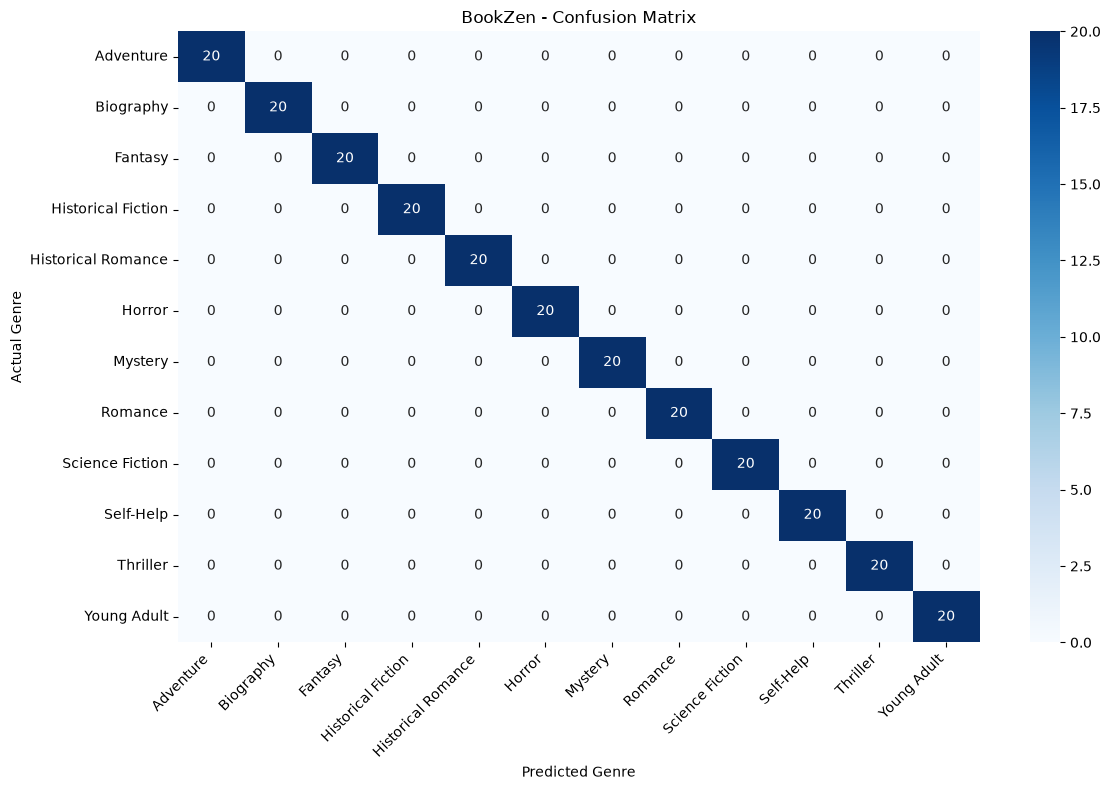

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("BookZen - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import classification_report
print("Logistic Regression - Classification Report")
print("============================================")

print(classification_report(y_test, y_pred_lr))

Logistic Regression - Classification Report
                    precision    recall  f1-score   support

         Adventure       1.00      1.00      1.00        20
         Biography       1.00      1.00      1.00        20
           Fantasy       1.00      1.00      1.00        20
Historical Fiction       1.00      1.00      1.00        20
Historical Romance       1.00      1.00      1.00        20
            Horror       1.00      1.00      1.00        20
           Mystery       1.00      1.00      1.00        20
           Romance       1.00      1.00      1.00        20
   Science Fiction       1.00      1.00      1.00        20
         Self-Help       1.00      1.00      1.00        20
          Thriller       1.00      1.00      1.00        20
       Young Adult       1.00      1.00      1.00        20

          accuracy                           1.00       240
         macro avg       1.00      1.00      1.00       240
      weighted avg       1.00      1.00      1.00     

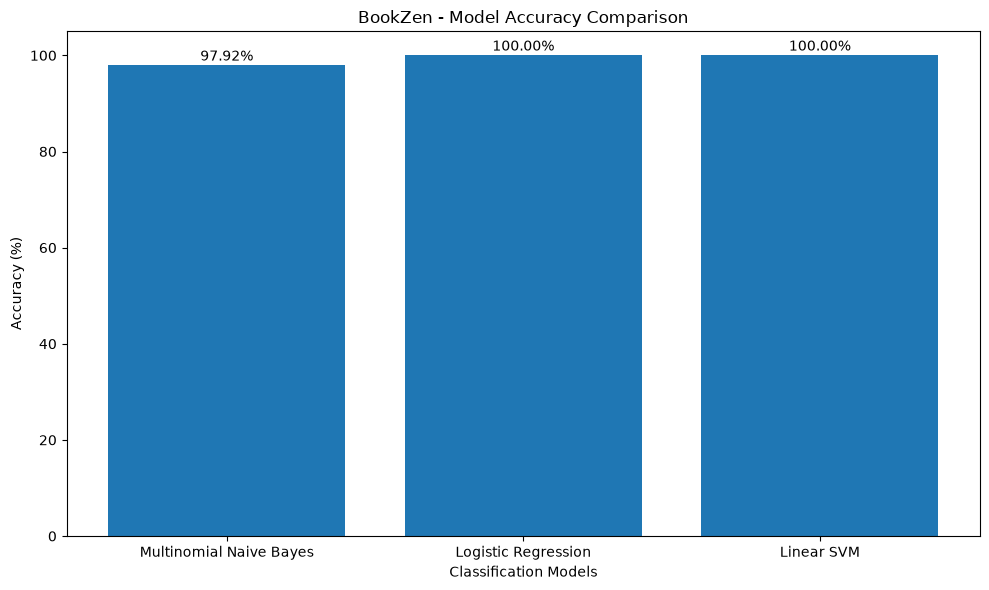

In [39]:
models = [
    "Multinomial Naive Bayes",
    "Logistic Regression",
    "Linear SVM"
]

accuracies = [
    accuracy_mnb * 100,
    accuracy_lr * 100,
    accuracy_svm * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, accuracies)

plt.xlabel("Classification Models")
plt.ylabel("Accuracy (%)")
plt.title("BookZen - Model Accuracy Comparison")
plt.ylim(0, 105)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [40]:
def predict_genre(description):
    
    # Apply the same preprocessing
    cleaned = clean_text(description)
    no_stopwords = remove_stopwords(cleaned)
    processed = lemmatize_text(no_stopwords)
    
    # Convert text into TF-IDF features
    text_vector = classifier_tfidf.transform([processed])
    
    # Predict genre
    prediction = lr_model.predict(text_vector)[0]
    
    return prediction


print("Genre prediction function created successfully!")

Genre prediction function created successfully!


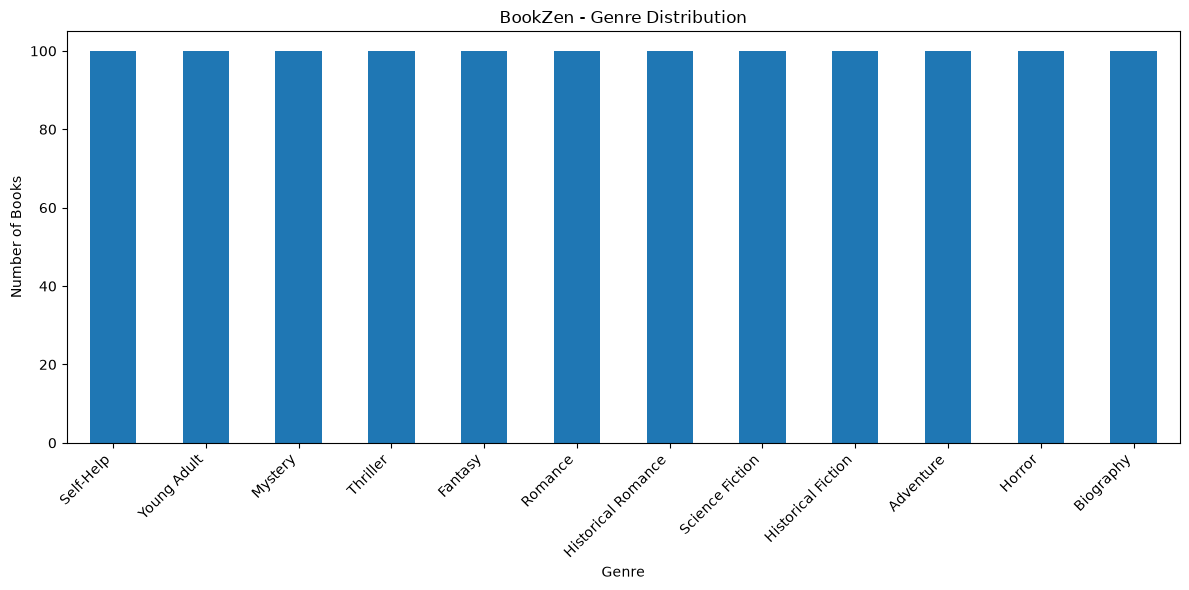

In [41]:
plt.figure(figsize=(12, 6))

genre_counts = df["genre"].value_counts()

genre_counts.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("BookZen - Genre Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

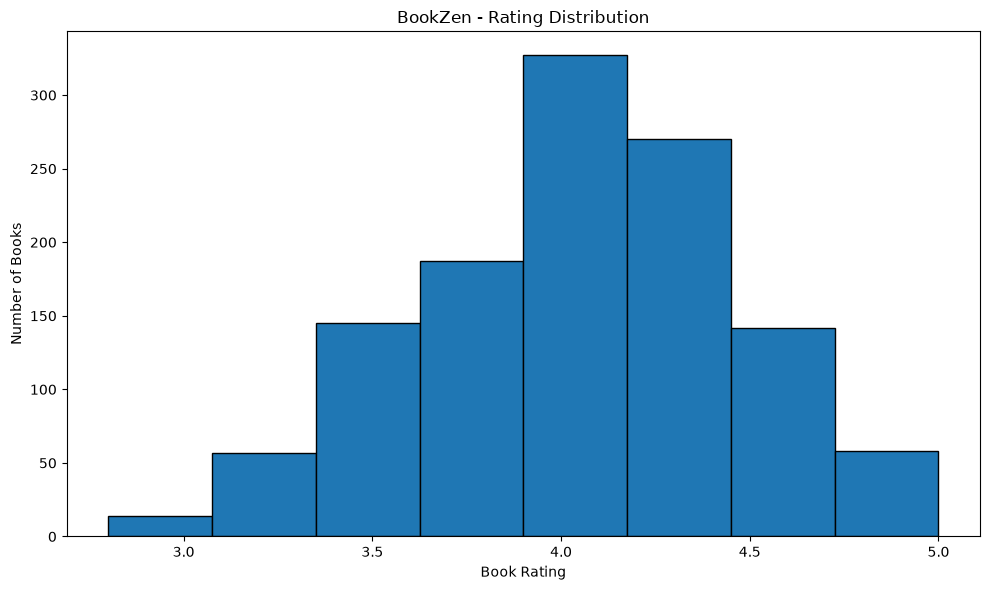

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["rating"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("Book Rating")
plt.ylabel("Number of Books")
plt.title("BookZen - Rating Distribution")

plt.tight_layout()
plt.show()

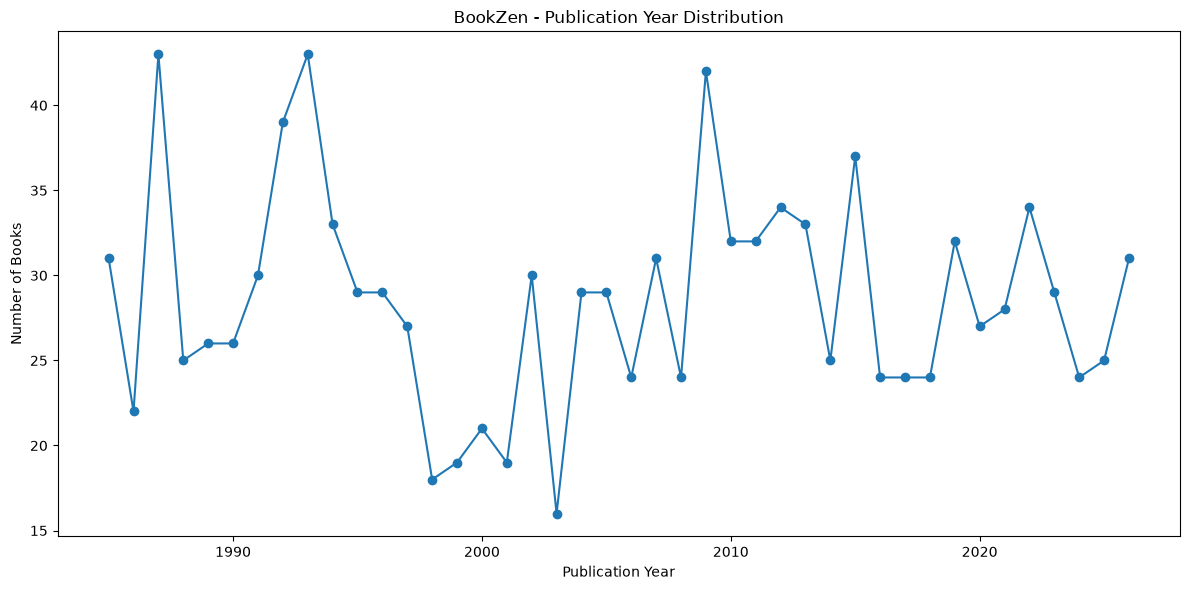

In [43]:
plt.figure(figsize=(12, 6))

year_counts = df["year"].value_counts().sort_index()

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o"
)

plt.xlabel("Publication Year")
plt.ylabel("Number of Books")
plt.title("BookZen - Publication Year Distribution")

plt.tight_layout()
plt.show()

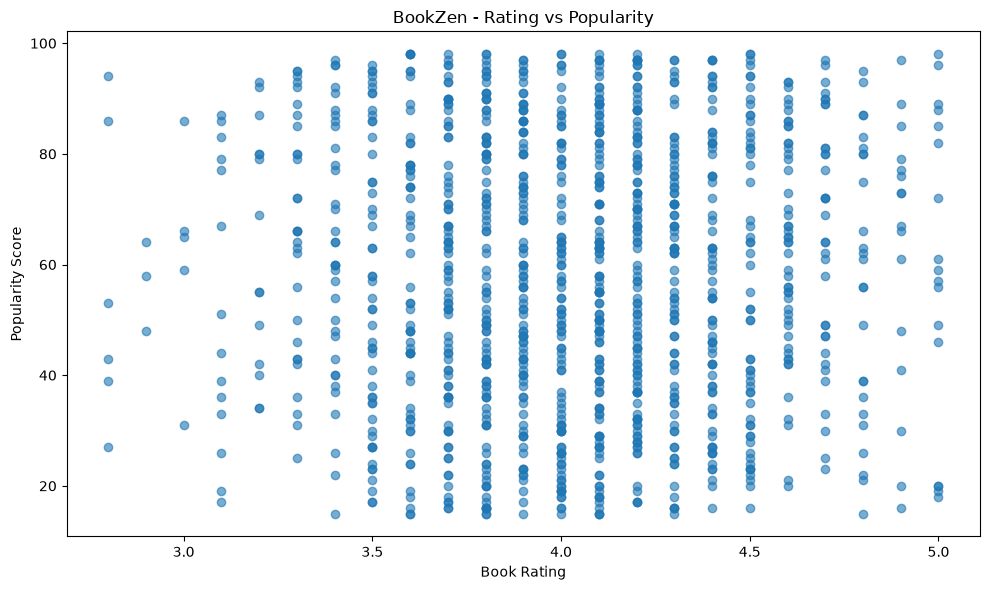

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["rating"],
    df["popularity_score"],
    alpha=0.6
)

plt.xlabel("Book Rating")
plt.ylabel("Popularity Score")
plt.title("BookZen - Rating vs Popularity")

plt.tight_layout()
plt.show()

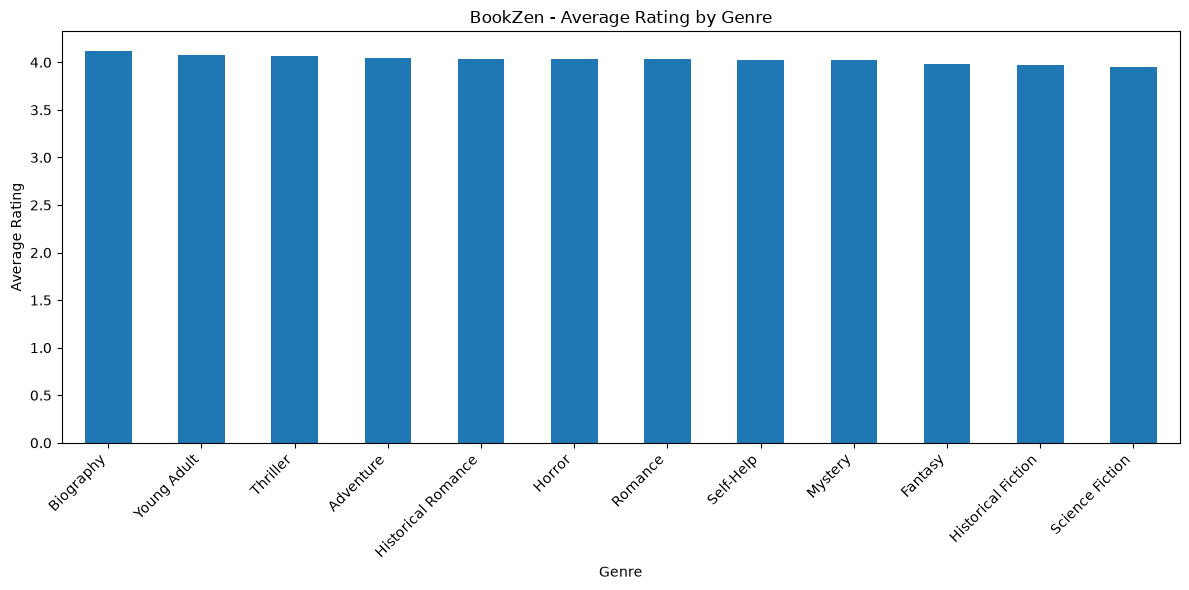

In [45]:
plt.figure(figsize=(12, 6))

genre_rating = df.groupby("genre")["rating"].mean().sort_values(ascending=False)

genre_rating.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("BookZen - Average Rating by Genre")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

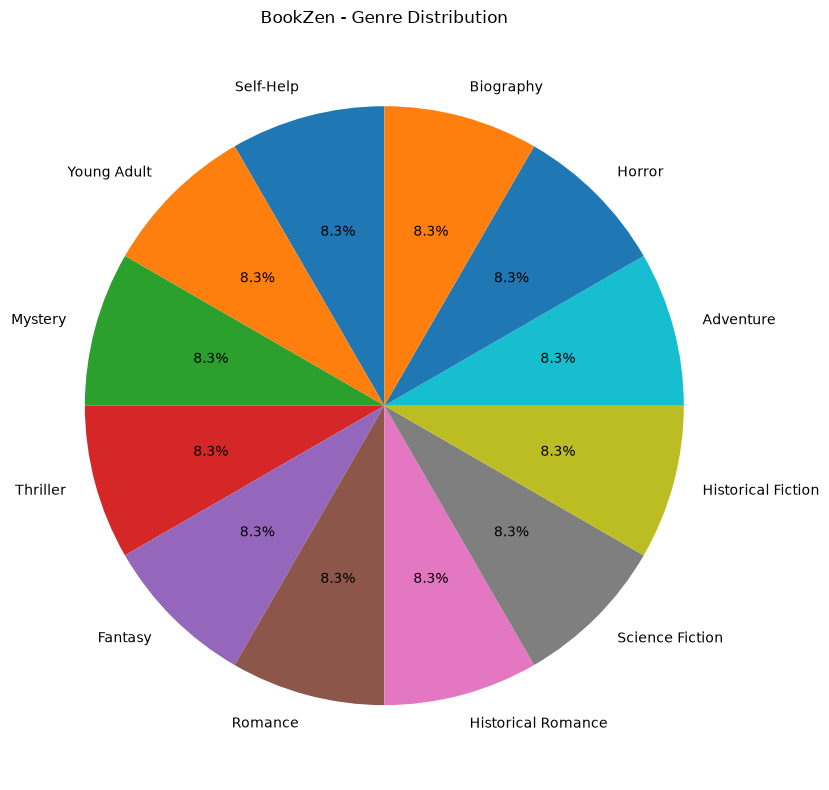

In [46]:
plt.figure(figsize=(10, 8))

genre_counts = df["genre"].value_counts()

plt.pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("BookZen - Genre Distribution")
plt.tight_layout()
plt.show()

In [47]:
model_results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy (%)": [
        accuracy_mnb * 100,
        accuracy_lr * 100,
        accuracy_svm * 100
    ],
    "Precision (%)": [
        precision_mnb * 100,
        precision_lr * 100,
        precision_svm * 100
    ],
    "Recall (%)": [
        recall_mnb * 100,
        recall_lr * 100,
        recall_svm * 100
    ],
    "F1-Score (%)": [
        f1_mnb * 100,
        f1_lr * 100,
        f1_svm * 100
    ]
})

model_results.round(2)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Multinomial Naive Bayes,97.92,98.03,97.92,97.9
1,Logistic Regression,100.00,100.00,100.00,100.0
2,Linear SVM,100.00,100.00,100.00,100.0


In [48]:
import joblib
joblib.dump(lr_model, "bookzen_genre_model.pkl")
joblib.dump(classifier_tfidf, "bookzen_tfidf_vectorizer.pkl")

print("Final model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Final model saved successfully!
TF-IDF vectorizer saved successfully!


In [49]:
import string
sample_description = """
A young detective investigates a mysterious disappearance in a quiet town.
Hidden clues, secret messages, and unexpected evidence slowly reveal the truth.
"""

predicted_genre = predict_genre(sample_description)

print("Sample Description:")
print(sample_description)

print("\nPredicted Genre:", predicted_genre)

Sample Description:

A young detective investigates a mysterious disappearance in a quiet town.
Hidden clues, secret messages, and unexpected evidence slowly reveal the truth.


Predicted Genre: Mystery


In [51]:
def recommend_books(book_title, num_recommendations=5):

    if book_title not in df["title"].values:
        print("Book not found in the dataset.")
        return

    book_index = df[df["title"] == book_title].index[0]

    similarity_scores = list(enumerate(cosine_sim[book_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[
        1:num_recommendations + 1
    ]

    book_indices = [i[0] for i in similarity_scores]

    recommendations = df.iloc[book_indices][
        ["title", "author", "genre", "rating"]
    ].copy()

    recommendations["similarity"] = [
        f"{score * 100:.2f}%"
        for _, score in similarity_scores
    ]

    recommendations = recommendations.reset_index(drop=True)

    return recommendations

In [52]:
recommend_books("The Silent Room", 5)

,title,author,genre,rating,similarity
0,The Hidden Silent Room,Nathan Mitchell,Mystery,3.1,47.82%
1,Beneath Silent Room,Isha Shaw,Mystery,3.7,47.45%
2,The Last Black Network,Nora Mehta,Thriller,3.7,46.89%
3,The Hidden Hidden Agenda,Elena Desai,Thriller,4.2,46.83%
4,Across Midnight Clue,Ethan Parker,Mystery,4.2,45.76%


In [53]:
book_to_test = "The Silent Room"

print("Selected Book:", book_to_test)
print("\nRecommended Books:")
recommend_books(book_to_test, 5)

Selected Book: The Silent Room

Recommended Books:


,title,author,genre,rating,similarity
0,The Hidden Silent Room,Nathan Mitchell,Mystery,3.1,47.82%
1,Beneath Silent Room,Isha Shaw,Mystery,3.7,47.45%
2,The Last Black Network,Nora Mehta,Thriller,3.7,46.89%
3,The Hidden Hidden Agenda,Elena Desai,Thriller,4.2,46.83%
4,Across Midnight Clue,Ethan Parker,Mystery,4.2,45.76%


In [54]:
user_description = input("Enter book description: ")

predicted_genre = predict_genre(user_description)

print("\nPredicted Genre:", predicted_genre)

Enter book description:  A young detective investigates a mysterious disappearance in a quiet town. Hidden clues, secret messages, and unexpected evidence slowly reveal the truth.



Predicted Genre: Mystery


In [55]:
import os

print("Model file exists:",
      os.path.exists("bookzen_genre_model.pkl"))

print("TF-IDF vectorizer exists:",
      os.path.exists("bookzen_tfidf_vectorizer.pkl"))

Model file exists: True
TF-IDF vectorizer exists: True


In [56]:
!pip install flask flask-login

In [57]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\LENOVO\Desktop\BookZen

Files in this folder:
['.ipynb_checkpoints', 'admin_fix.py', 'app', 'app.py', 'app_backup_admin_fix.py', 'app_before_admin_complete_fix.py', 'app_before_final_admin_fix.py', 'app_before_final_manage_books_fix.py', 'app_before_manage_books_fix.py', 'bookzen.db', 'bookzen_books_1200_realistic.csv', 'bookzen_genre_model.pkl', 'BookZen_NLP_Project.ipynb', 'bookzen_tfidf_vectorizer.pkl', 'data', 'static', 'templates']


In [58]:
%%writefile app.py

from flask import Flask

app = Flask(__name__)


@app.route("/")
def home():
    return "Welcome to BookZen!"


if __name__ == "__main__":
    app.run(debug=True)

Overwriting app.py


In [59]:
import os

print("app.py exists:", os.path.exists("app.py"))

app.py exists: True


In [60]:
%%writefile templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>BookZen - Book Recommendation System</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f3ff;
            color: #222;
        }

        .navbar {
            background: #24124d;
            color: white;
            padding: 20px 50px;
            display: flex;
            justify-content: space-between;
            align-items: center;
        }

        .logo {
            font-size: 28px;
            font-weight: bold;
        }

        .nav-links a {
            color: white;
            text-decoration: none;
            margin-left: 25px;
        }

        .hero {
            text-align: center;
            padding: 100px 20px;
        }

        .hero h1 {
            font-size: 50px;
            color: #24124d;
            margin-bottom: 20px;
        }

        .hero p {
            font-size: 20px;
            color: #555;
            max-width: 700px;
            margin: auto;
            line-height: 1.6;
        }

        .button {
            display: inline-block;
            margin-top: 35px;
            padding: 15px 30px;
            background: #6c3fc5;
            color: white;
            text-decoration: none;
            border-radius: 8px;
            font-size: 18px;
        }

        .features {
            display: flex;
            justify-content: center;
            gap: 25px;
            padding: 40px;
            flex-wrap: wrap;
        }

        .card {
            background: white;
            width: 250px;
            padding: 30px;
            border-radius: 15px;
            text-align: center;
            box-shadow: 0 5px 20px rgba(0,0,0,0.1);
        }

        .card h3 {
            color: #6c3fc5;
        }
    </style>
</head>

<body>

    <div class="navbar">
        <div class="logo">📚 BookZen</div>

        <div class="nav-links">
            <a href="#">Home</a>
            <a href="#">Login</a>
            <a href="#">Register</a>
        </div>
    </div>

    <section class="hero">

        <h1>Discover Your Next Favorite Book</h1>

        <p>
            BookZen is an NLP-based book recommendation and
            genre classification system that helps users discover
            books based on textual similarity and preferences.
        </p>

        <a href="#" class="button">Explore Books</a>

    </section>

    <section class="features">

        <div class="card">
            <h3>📖 Smart Recommendations</h3>
            <p>
                Find books similar to your favorite books using
                NLP and text similarity.
            </p>
        </div>

        <div class="card">
            <h3>🤖 AI Genre Prediction</h3>
            <p>
                Predict the genre of a book description using
                machine learning.
            </p>
        </div>

        <div class="card">
            <h3>⭐ Book Discovery</h3>
            <p>
                Explore books using ratings, genres and
                popularity.
            </p>
        </div>

    </section>

</body>
</html>

Overwriting templates/index.html


In [61]:
%%writefile app.py

from flask import Flask, render_template

app = Flask(__name__)


@app.route("/")
def home():
    return render_template("index.html")


if __name__ == "__main__":
    app.run(debug=True)

Overwriting app.py


In [62]:
%%writefile app.py

from flask import Flask, render_template

app = Flask(__name__)


@app.route("/")
def home():
    return render_template("index.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [63]:
%%writefile templates/register.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Register - BookZen</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f3ff;
        }

        .navbar {
            background: #24124d;
            color: white;
            padding: 20px 50px;
        }

        .logo {
            font-size: 28px;
            font-weight: bold;
        }

        .container {
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 80vh;
        }

        .register-box {
            background: white;
            width: 400px;
            padding: 40px;
            border-radius: 15px;
            box-shadow: 0 5px 25px rgba(0, 0, 0, 0.12);
        }

        .register-box h1 {
            text-align: center;
            color: #24124d;
            margin-bottom: 10px;
        }

        .register-box p {
            text-align: center;
            color: #666;
            margin-bottom: 30px;
        }

        label {
            display: block;
            margin-bottom: 8px;
            font-weight: bold;
        }

        input {
            width: 100%;
            padding: 12px;
            margin-bottom: 20px;
            border: 1px solid #ccc;
            border-radius: 7px;
            box-sizing: border-box;
            font-size: 15px;
        }

        button {
            width: 100%;
            padding: 13px;
            border: none;
            border-radius: 7px;
            background: #6c3fc5;
            color: white;
            font-size: 17px;
            cursor: pointer;
        }

        button:hover {
            background: #572fa8;
        }

        .login-link {
            text-align: center;
            margin-top: 20px;
        }

        .login-link a {
            color: #6c3fc5;
            text-decoration: none;
            font-weight: bold;
        }
    </style>
</head>

<body>

    <div class="navbar">
        <div class="logo">📚 BookZen</div>
    </div>

    <div class="container">

        <div class="register-box">

            <h1>Create Account</h1>

            <p>Join BookZen and discover amazing books.</p>

            <form>

                <label>Full Name</label>
                <input type="text" placeholder="Enter your name">

                <label>Email</label>
                <input type="email" placeholder="Enter your email">

                <label>Password</label>
                <input type="password" placeholder="Create a password">

                <button type="submit">Register</button>

            </form>

            <div class="login-link">
                Already have an account?
                <a href="/login">Login</a>
            </div>

        </div>

    </div>

</body>
</html>

Overwriting templates/register.html


In [64]:
%%writefile templates/login.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Login - BookZen</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f3ff;
        }

        .navbar {
            background: #24124d;
            color: white;
            padding: 20px 50px;
        }

        .logo {
            font-size: 28px;
            font-weight: bold;
        }

        .container {
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 80vh;
        }

        .login-box {
            background: white;
            width: 400px;
            padding: 40px;
            border-radius: 15px;
            box-shadow: 0 5px 25px rgba(0, 0, 0, 0.12);
        }

        .login-box h1 {
            text-align: center;
            color: #24124d;
            margin-bottom: 10px;
        }

        .login-box p {
            text-align: center;
            color: #666;
            margin-bottom: 30px;
        }

        label {
            display: block;
            margin-bottom: 8px;
            font-weight: bold;
        }

        input {
            width: 100%;
            padding: 12px;
            margin-bottom: 20px;
            border: 1px solid #ccc;
            border-radius: 7px;
            box-sizing: border-box;
            font-size: 15px;
        }

        button {
            width: 100%;
            padding: 13px;
            border: none;
            border-radius: 7px;
            background: #6c3fc5;
            color: white;
            font-size: 17px;
            cursor: pointer;
        }

        button:hover {
            background: #572fa8;
        }

        .register-link {
            text-align: center;
            margin-top: 20px;
        }

        .register-link a {
            color: #6c3fc5;
            text-decoration: none;
            font-weight: bold;
        }
    </style>
</head>

<body>

    <div class="navbar">
        <div class="logo">📚 BookZen</div>
    </div>

    <div class="container">

        <div class="login-box">

            <h1>Welcome Back</h1>

            <p>Login to continue your BookZen journey.</p>

            <form>

                <label>Email</label>
                <input type="email" placeholder="Enter your email">

                <label>Password</label>
                <input type="password" placeholder="Enter your password">

                <button type="submit">Login</button>

            </form>

            <div class="register-link">
                Don't have an account?
                <a href="/register">Register</a>
            </div>

        </div>

    </div>

</body>
</html>

Overwriting templates/login.html


In [65]:
%%writefile app.py

from flask import Flask, render_template

app = Flask(__name__)


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login")
def login():
    return render_template("login.html")


@app.route("/register")
def register():
    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False,use_reloader=False)

Overwriting app.py


In [66]:
%%writefile templates/index.html

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Book Recommendation System</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f3ff;
            color: #222;
        }

        .navbar {
            background: #24124d;
            color: white;
            padding: 20px 50px;
            display: flex;
            justify-content: space-between;
            align-items: center;
        }

        .logo {
            font-size: 28px;
            font-weight: bold;
        }

        .nav-links a {
            color: white;
            text-decoration: none;
            margin-left: 25px;
        }

        .hero {
            text-align: center;
            padding: 100px 20px;
        }

        .hero h1 {
            font-size: 50px;
            color: #24124d;
        }

        .hero p {
            font-size: 20px;
            color: #555;
            max-width: 700px;
            margin: auto;
            line-height: 1.6;
        }

        .button {
            display: inline-block;
            margin-top: 35px;
            padding: 15px 30px;
            background: #6c3fc5;
            color: white;
            text-decoration: none;
            border-radius: 8px;
            font-size: 18px;
        }

        .features {
            display: flex;
            justify-content: center;
            gap: 25px;
            padding: 40px;
            flex-wrap: wrap;
        }

        .card {
            background: white;
            width: 250px;
            padding: 30px;
            border-radius: 15px;
            text-align: center;
            box-shadow: 0 5px 20px rgba(0,0,0,0.1);
        }

        .card h3 {
            color: #6c3fc5;
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">📚 BookZen</div>

        <div class="nav-links">
            <a href="/">Home</a>
            <a href="/login">Login</a>
            <a href="/register">Register</a>
        </div>

    </div>

    <section class="hero">

        <h1>Discover Your Next Favorite Book</h1>

        <p>
            BookZen is an NLP-based book recommendation and
            genre classification system that helps users discover
            books based on textual similarity and preferences.
        </p>

        <a href="/register" class="button">Explore Books</a>

    </section>

    <section class="features">

        <div class="card">
            <h3>📖 Smart Recommendations</h3>
            <p>
                Find books similar to your favorite books using
                NLP and text similarity.
            </p>
        </div>

        <div class="card">
            <h3>🤖 AI Genre Prediction</h3>
            <p>
                Predict the genre of a book description using
                machine learning.
            </p>
        </div>

        <div class="card">
            <h3>⭐ Book Discovery</h3>
            <p>
                Explore books using ratings, genres and popularity.
            </p>
        </div>

    </section>

</body>
</html>

Overwriting templates/index.html


In [67]:
import sqlite3

connection = sqlite3.connect("bookzen.db")

cursor = connection.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    password TEXT NOT NULL
)
""")

connection.commit()
connection.close()

print("BookZen database created successfully!")
print("Users table created successfully!")

BookZen database created successfully!
Users table created successfully!


In [68]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
from werkzeug.security import generate_password_hash

app = Flask(__name__)


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login")
def login():
    return render_template("login.html")


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:
            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:
            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [69]:
%%writefile templates/register.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Register</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: linear-gradient(135deg, #0f172a, #312e81);
            color: white;
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
        }

        .register-box {
            width: 380px;
            background: rgba(255, 255, 255, 0.1);
            padding: 35px;
            border-radius: 20px;
            box-shadow: 0 10px 30px rgba(0, 0, 0, 0.3);
        }

        h1 {
            text-align: center;
            margin-bottom: 10px;
        }

        .subtitle {
            text-align: center;
            color: #d1d5db;
            margin-bottom: 25px;
        }

        label {
            display: block;
            margin-top: 15px;
            margin-bottom: 7px;
        }

        input {
            width: 100%;
            padding: 12px;
            border: none;
            border-radius: 10px;
            box-sizing: border-box;
            font-size: 15px;
        }

        button {
            width: 100%;
            margin-top: 25px;
            padding: 13px;
            border: none;
            border-radius: 10px;
            background: #f59e0b;
            color: white;
            font-size: 16px;
            font-weight: bold;
            cursor: pointer;
        }

        button:hover {
            background: #d97706;
        }

        .login-link {
            text-align: center;
            margin-top: 20px;
        }

        a {
            color: #fbbf24;
            text-decoration: none;
        }
    </style>
</head>

<body>

    <div class="register-box">

        <h1>📚 BookZen</h1>

        <p class="subtitle">Create your account</p>

        <form method="POST">

            <label>Full Name</label>
            <input type="text" name="name" placeholder="Enter your name" required>

            <label>Email</label>
            <input type="email" name="email" placeholder="Enter your email" required>

            <label>Password</label>
            <input type="password" name="password" placeholder="Create a password" required>

            <button type="submit">Create Account</button>

        </form>

        <div class="login-link">
            Already have an account?
            <a href="/login">Login</a>
        </div>

    </div>

</body>

</html>

Overwriting templates/register.html


In [70]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()
        connection.close()

        if user and check_password_hash(user[3], password):
            return f"Welcome to BookZen, {user[1]}!"

        else:
            return "Invalid email or password!"

    return render_template("login.html")


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:
            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:
            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [71]:
%%writefile templates/login.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Login</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: linear-gradient(135deg, #0f172a, #312e81);
            color: white;
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
        }

        .login-box {
            width: 380px;
            background: rgba(255, 255, 255, 0.1);
            padding: 35px;
            border-radius: 20px;
            box-shadow: 0 10px 30px rgba(0, 0, 0, 0.3);
        }

        h1 {
            text-align: center;
            margin-bottom: 10px;
        }

        .subtitle {
            text-align: center;
            color: #d1d5db;
            margin-bottom: 25px;
        }

        label {
            display: block;
            margin-top: 15px;
            margin-bottom: 7px;
        }

        input {
            width: 100%;
            padding: 12px;
            border: none;
            border-radius: 10px;
            box-sizing: border-box;
            font-size: 15px;
        }

        button {
            width: 100%;
            margin-top: 25px;
            padding: 13px;
            border: none;
            border-radius: 10px;
            background: #f59e0b;
            color: white;
            font-size: 16px;
            font-weight: bold;
            cursor: pointer;
        }

        button:hover {
            background: #d97706;
        }

        .register-link {
            text-align: center;
            margin-top: 20px;
        }

        a {
            color: #fbbf24;
            text-decoration: none;
        }
    </style>
</head>

<body>

    <div class="login-box">

        <h1>📚 BookZen</h1>

        <p class="subtitle">Login to your account</p>

        <form method="POST">

            <label>Email</label>
            <input
                type="email"
                name="email"
                placeholder="Enter your email"
                required
            >

            <label>Password</label>
            <input
                type="password"
                name="password"
                placeholder="Enter your password"
                required
            >

            <button type="submit">Login</button>

        </form>

        <div class="register-link">
            Don't have an account?
            <a href="/register">Create Account</a>
        </div>

    </div>

</body>

</html>

Overwriting templates/login.html


In [72]:
%%writefile templates/login.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Login</title>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: linear-gradient(135deg, #0f172a, #312e81);
            color: white;
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
        }

        .login-box {
            width: 380px;
            background: rgba(255, 255, 255, 0.1);
            padding: 35px;
            border-radius: 20px;
            box-shadow: 0 10px 30px rgba(0, 0, 0, 0.3);
        }

        h1 {
            text-align: center;
            margin-bottom: 10px;
        }

        .subtitle {
            text-align: center;
            color: #d1d5db;
            margin-bottom: 25px;
        }

        label {
            display: block;
            margin-top: 15px;
            margin-bottom: 7px;
        }

        input {
            width: 100%;
            padding: 12px;
            border: none;
            border-radius: 10px;
            box-sizing: border-box;
            font-size: 15px;
        }

        button {
            width: 100%;
            margin-top: 25px;
            padding: 13px;
            border: none;
            border-radius: 10px;
            background: #f59e0b;
            color: white;
            font-size: 16px;
            font-weight: bold;
            cursor: pointer;
        }

        button:hover {
            background: #d97706;
        }

        .register-link {
            text-align: center;
            margin-top: 20px;
        }

        a {
            color: #fbbf24;
            text-decoration: none;
        }
    </style>
</head>

<body>

    <div class="login-box">

        <h1>📚 BookZen</h1>

        <p class="subtitle">Login to your account</p>

        <form method="POST">

            <label>Email</label>
            <input
                type="email"
                name="email"
                placeholder="Enter your email"
                required
            >

            <label>Password</label>
            <input
                type="password"
                name="password"
                placeholder="Enter your password"
                required
            >

            <button type="submit">Login</button>

        </form>

        <div class="register-link">
            Don't have an account?
            <a href="/register">Create Account</a>
        </div>

    </div>

</body>

</html>

Overwriting templates/login.html


In [73]:
%%writefile templates/dashboard.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Dashboard</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .logout {
            background: #f59e0b;
            color: white;
            padding: 10px 18px;
            border-radius: 8px;
            text-decoration: none;
        }

        .container {
            padding: 35px;
        }

        .welcome {
            background: linear-gradient(135deg, #312e81, #4f46e5);
            color: white;
            padding: 30px;
            border-radius: 18px;
            margin-bottom: 30px;
        }

        .welcome h1 {
            margin: 0 0 10px;
        }

        .welcome p {
            margin: 0;
            color: #e0e7ff;
        }

        .cards {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .card {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .card .icon {
            font-size: 32px;
        }

        .card h3 {
            margin-bottom: 8px;
        }

        .card p {
            color: #64748b;
            line-height: 1.5;
        }

        .section {
            margin-top: 35px;
        }

        .section h2 {
            margin-bottom: 15px;
        }

        .search-box {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .search-box input {
            width: 80%;
            padding: 13px;
            border: 1px solid #cbd5e1;
            border-radius: 8px;
            font-size: 15px;
        }

        .search-box button {
            padding: 13px 20px;
            border: none;
            border-radius: 8px;
            background: #4f46e5;
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        @media (max-width: 900px) {
            .cards {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .cards {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }

            .search-box input {
                width: 100%;
                margin-bottom: 10px;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/login" class="logout">
            Logout
        </a>

    </div>


    <div class="container">

        <div class="welcome">

            <h1>Welcome to BookZen 👋</h1>

            <p>
                Discover books, explore genres and get AI-powered recommendations.
            </p>

        </div>


        <div class="cards">

            <div class="card">
                <div class="icon">🔍</div>
                <h3>Search Books</h3>
                <p>
                    Search and explore books from the BookZen collection.
                </p>
            </div>


            <div class="card">
                <div class="icon">🤖</div>
                <h3>AI Recommendations</h3>
                <p>
                    Get similar books using NLP and text similarity.
                </p>
            </div>


            <div class="card">
                <div class="icon">🏷️</div>
                <h3>Genre Prediction</h3>
                <p>
                    Predict the genre of a book using our trained NLP model.
                </p>
            </div>


            <div class="card">
                <div class="icon">❤️</div>
                <h3>Favorites</h3>
                <p>
                    Save books you like and access them easily.
                </p>
            </div>

        </div>


        <div class="section">

            <h2>🔎 Find a Book</h2>

            <div class="search-box">

                <input
                    type="text"
                    placeholder="Enter book title..."
                >

                <button>
                    Search
                </button>

            </div>

        </div>

    </div>

</body>

</html>

Overwriting templates/dashboard.html


In [74]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()
        connection.close()

        if user and check_password_hash(user[3], password):
            return render_template(
                "dashboard.html",
                name=user[1]
            )

        else:
            return "Invalid email or password!"

    return render_template("login.html")


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:
            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:
            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [75]:
%%writefile templates/dashboard.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Dashboard</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .logout {
            background: #f59e0b;
            color: white;
            padding: 10px 18px;
            border-radius: 8px;
            text-decoration: none;
        }

        .container {
            padding: 35px;
        }

        .welcome {
            background: linear-gradient(135deg, #312e81, #4f46e5);
            color: white;
            padding: 30px;
            border-radius: 18px;
            margin-bottom: 30px;
        }

        .welcome h1 {
            margin: 0 0 10px;
        }

        .welcome p {
            margin: 0;
            color: #e0e7ff;
        }

        .cards {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .card {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .card .icon {
            font-size: 32px;
        }

        .card h3 {
            margin-bottom: 8px;
        }

        .card p {
            color: #64748b;
            line-height: 1.5;
        }

        .section {
            margin-top: 35px;
        }

        .section h2 {
            margin-bottom: 15px;
        }

        .search-box {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .search-box input {
            width: 80%;
            padding: 13px;
            border: 1px solid #cbd5e1;
            border-radius: 8px;
            font-size: 15px;
        }

        .search-box button {
            padding: 13px 20px;
            border: none;
            border-radius: 8px;
            background: #4f46e5;
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        @media (max-width: 900px) {
            .cards {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .cards {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }

            .search-box input {
                width: 100%;
                margin-bottom: 10px;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/login" class="logout">
            Logout
        </a>

    </div>


    <div class="container">

        <div class="welcome">

            <h1>Welcome, {{ name }} 👋</h1>

            <p>
                Discover books, explore genres and get AI-powered recommendations.
            </p>

        </div>


        <div class="cards">

            <div class="card">
                <div class="icon">🔍</div>
                <h3>Search Books</h3>
                <p>
                    Search and explore books from the BookZen collection.
                </p>
            </div>


            <div class="card">
                <div class="icon">🤖</div>
                <h3>AI Recommendations</h3>
                <p>
                    Get similar books using NLP and text similarity.
                </p>
            </div>


            <div class="card">
                <div class="icon">🏷️</div>
                <h3>Genre Prediction</h3>
                <p>
                    Predict the genre of a book using our trained NLP model.
                </p>
            </div>


            <div class="card">
                <div class="icon">❤️</div>
                <h3>Favorites</h3>
                <p>
                    Save books you like and access them easily.
                </p>
            </div>

        </div>


        <div class="section">

            <h2>🔎 Find a Book</h2>

            <div class="search-box">

                <input
                    type="text"
                    placeholder="Enter book title..."
                >

                <button>
                    Search
                </button>

            </div>

        </div>

    </div>

</body>

</html>

Overwriting templates/dashboard.html


In [76]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
import pandas as pd
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)

# Load BookZen dataset
df = pd.read_csv("bookzen_books_1200_realistic.csv")


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()
        connection.close()

        if user and check_password_hash(user[3], password):
            return render_template(
                "dashboard.html",
                name=user[1]
            )

        else:
            return "Invalid email or password!"

    return render_template("login.html")


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:
            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:
            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [77]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
import pandas as pd
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)

# Load BookZen dataset
df = pd.read_csv("bookzen_books_1200_realistic.csv")


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()
        connection.close()

        if user and check_password_hash(user[3], password):
            return redirect(url_for("dashboard", name=user[1]))

        else:
            return "Invalid email or password!"

    return render_template("login.html")


@app.route("/dashboard")
def dashboard():

    name = request.args.get("name", "Reader")

    total_books = len(df)
    total_genres = df["genre"].nunique()
    average_rating = round(df["rating"].mean(), 2)
    years = f"{df['year'].min()} - {df['year'].max()}"

    return render_template(
        "dashboard.html",
        name=name,
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=years
    )


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:
            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:
            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [78]:
%%writefile templates/dashboard.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Dashboard</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .logout {
            background: #f59e0b;
            color: white;
            padding: 10px 18px;
            border-radius: 8px;
            text-decoration: none;
        }

        .container {
            padding: 35px;
        }

        .welcome {
            background: linear-gradient(135deg, #312e81, #4f46e5);
            color: white;
            padding: 30px;
            border-radius: 18px;
            margin-bottom: 30px;
        }

        .welcome h1 {
            margin: 0 0 10px;
        }

        .welcome p {
            margin: 0;
            color: #e0e7ff;
        }

        .stats {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
            margin-bottom: 30px;
        }

        .stat-card {
            background: white;
            padding: 22px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .stat-icon {
            font-size: 30px;
        }

        .stat-card h2 {
            margin: 10px 0 5px;
            color: #312e81;
        }

        .stat-card p {
            margin: 0;
            color: #64748b;
        }

        .cards {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .card {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .card .icon {
            font-size: 32px;
        }

        .card h3 {
            margin-bottom: 8px;
        }

        .card p {
            color: #64748b;
            line-height: 1.5;
        }

        .section {
            margin-top: 35px;
        }

        .search-box {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .search-box input {
            width: 80%;
            padding: 13px;
            border: 1px solid #cbd5e1;
            border-radius: 8px;
            font-size: 15px;
        }

        .search-box button {
            padding: 13px 20px;
            border: none;
            border-radius: 8px;
            background: #4f46e5;
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        @media (max-width: 900px) {
            .stats,
            .cards {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .stats,
            .cards {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }

            .search-box input {
                width: 100%;
                margin-bottom: 10px;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/login" class="logout">
            Logout
        </a>

    </div>


    <div class="container">

        <div class="welcome">

            <h1>Welcome, {{ name }} 👋</h1>

            <p>
                Discover books, explore genres and get AI-powered recommendations.
            </p>

        </div>


        <!-- Dataset Statistics -->

        <div class="stats">

            <div class="stat-card">
                <div class="stat-icon">📚</div>
                <h2>{{ total_books }}</h2>
                <p>Total Books</p>
            </div>

            <div class="stat-card">
                <div class="stat-icon">🏷️</div>
                <h2>{{ total_genres }}</h2>
                <p>Genres</p>
            </div>

            <div class="stat-card">
                <div class="stat-icon">⭐</div>
                <h2>{{ average_rating }}</h2>
                <p>Average Rating</p>
            </div>

            <div class="stat-card">
                <div class="stat-icon">📅</div>
                <h2>{{ years }}</h2>
                <p>Publication Range</p>
            </div>

        </div>


        <!-- Main Features -->

        <div class="cards">

            <div class="card">
                <div class="icon">🔍</div>
                <h3>Search Books</h3>
                <p>
                    Search and explore books from the BookZen collection.
                </p>
            </div>


            <div class="card">
                <div class="icon">🤖</div>
                <h3>AI Recommendations</h3>
                <p>
                    Get similar books using NLP and text similarity.
                </p>
            </div>


            <div class="card">
                <div class="icon">🏷️</div>
                <h3>Genre Prediction</h3>
                <p>
                    Predict the genre of a book using our trained NLP model.
                </p>
            </div>


            <div class="card">
                <div class="icon">❤️</div>
                <h3>Favorites</h3>
                <p>
                    Save books you like and access them easily.
                </p>
            </div>

        </div>


        <!-- Search -->

        <div class="section">

            <h2>🔎 Find a Book</h2>

            <div class="search-box">

                <input
                    type="text"
                    placeholder="Enter book title..."
                >

                <button>
                    Search
                </button>

            </div>

        </div>

    </div>

</body>

</html>

Overwriting templates/dashboard.html


In [79]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
import pandas as pd
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)

# Load BookZen dataset
df = pd.read_csv("bookzen_books_1200_realistic.csv")


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()
        connection.close()

        if user and check_password_hash(user[3], password):
            return redirect(url_for("dashboard", name=user[1]))

        return "Invalid email or password!"

    return render_template("login.html")


@app.route("/dashboard")
def dashboard():

    name = request.args.get("name", "Reader")

    total_books = len(df)
    total_genres = df["genre"].nunique()
    average_rating = round(df["rating"].mean(), 2)
    years = f"{df['year'].min()} - {df['year'].max()}"

    return render_template(
        "dashboard.html",
        name=name,
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=years
    )


@app.route("/search")
def search():

    query = request.args.get("query", "").strip()

    if query == "":
        return redirect(url_for("dashboard"))

    results = df[
        df["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ].head(20)

    return render_template(
        "search.html",
        query=query,
        books=results.to_dict("records")
    )


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:

            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:

            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [80]:
%%writefile templates/search.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Search Results</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .back {
            color: white;
            text-decoration: none;
            background: #4f46e5;
            padding: 10px 18px;
            border-radius: 8px;
        }

        .container {
            padding: 35px;
        }

        .heading {
            margin-bottom: 25px;
        }

        .heading h1 {
            margin-bottom: 8px;
        }

        .heading p {
            color: #64748b;
        }

        .search-box {
            background: white;
            padding: 20px;
            border-radius: 15px;
            margin-bottom: 30px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .search-box input {
            width: 80%;
            padding: 13px;
            border: 1px solid #cbd5e1;
            border-radius: 8px;
            font-size: 15px;
        }

        .search-box button {
            padding: 13px 20px;
            border: none;
            border-radius: 8px;
            background: #4f46e5;
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        .books {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .book-card {
            background: white;
            padding: 22px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
            transition: transform 0.2s;
        }

        .book-card:hover {
            transform: translateY(-5px);
        }

        .book-icon {
            font-size: 42px;
            margin-bottom: 12px;
        }

        .book-card h3 {
            margin: 5px 0 10px;
            color: #312e81;
        }

        .author {
            color: #475569;
            margin-bottom: 10px;
        }

        .genre {
            display: inline-block;
            background: #ede9fe;
            color: #4338ca;
            padding: 5px 10px;
            border-radius: 20px;
            font-size: 13px;
            margin-bottom: 12px;
        }

        .rating {
            color: #f59e0b;
            font-weight: bold;
        }

        .no-results {
            background: white;
            padding: 40px;
            text-align: center;
            border-radius: 16px;
        }

        @media (max-width: 1000px) {
            .books {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .books {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }

            .search-box input {
                width: 100%;
                margin-bottom: 10px;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/dashboard" class="back">
            ← Dashboard
        </a>

    </div>


    <div class="container">

        <div class="heading">

            <h1>🔎 Search Results</h1>

            <p>
                Showing results for:
                <strong>"{{ query }}"</strong>
            </p>

        </div>


        <div class="search-box">

            <form action="/search" method="GET">

                <input
                    type="text"
                    name="query"
                    value="{{ query }}"
                    placeholder="Search book title..."
                    required
                >

                <button type="submit">
                    Search
                </button>

            </form>

        </div>


        {% if books %}

        <div class="books">

            {% for book in books %}

            <div class="book-card">

                <div class="book-icon">
                    📖
                </div>

                <h3>
                    {{ book.title }}
                </h3>

                <div class="author">
                    ✍️ {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="no-results">

            <h2>😔 No books found</h2>

            <p>
                Try searching with another book title.
            </p>

        </div>

        {% endif %}

    </div>

</body>

</html>

Overwriting templates/search.html


In [81]:
%%writefile templates/dashboard.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Dashboard</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .logout {
            background: #f59e0b;
            color: white;
            padding: 10px 18px;
            border-radius: 8px;
            text-decoration: none;
        }

        .container {
            padding: 35px;
        }

        .welcome {
            background: linear-gradient(135deg, #312e81, #4f46e5);
            color: white;
            padding: 30px;
            border-radius: 18px;
            margin-bottom: 30px;
        }

        .welcome h1 {
            margin: 0 0 10px;
        }

        .welcome p {
            margin: 0;
            color: #e0e7ff;
        }

        .stats {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
            margin-bottom: 30px;
        }

        .stat-card {
            background: white;
            padding: 22px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .stat-icon {
            font-size: 30px;
        }

        .stat-card h2 {
            margin: 10px 0 5px;
            color: #312e81;
        }

        .stat-card p {
            margin: 0;
            color: #64748b;
        }

        .cards {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .card {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .card .icon {
            font-size: 32px;
        }

        .card h3 {
            margin-bottom: 8px;
        }

        .card p {
            color: #64748b;
            line-height: 1.5;
        }

        .section {
            margin-top: 35px;
        }

        .section h2 {
            margin-bottom: 15px;
        }

        .search-box {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .search-box form {
            display: flex;
            gap: 10px;
        }

        .search-box input {
            flex: 1;
            padding: 13px;
            border: 1px solid #cbd5e1;
            border-radius: 8px;
            font-size: 15px;
        }

        .search-box button {
            padding: 13px 22px;
            border: none;
            border-radius: 8px;
            background: #4f46e5;
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        .search-box button:hover {
            background: #3730a3;
        }

        @media (max-width: 900px) {
            .stats,
            .cards {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .stats,
            .cards {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }

            .search-box form {
                flex-direction: column;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/login" class="logout">
            Logout
        </a>

    </div>


    <div class="container">

        <div class="welcome">

            <h1>Welcome, {{ name }} 👋</h1>

            <p>
                Discover books, explore genres and get AI-powered recommendations.
            </p>

        </div>


        <!-- Dataset Statistics -->

        <div class="stats">

            <div class="stat-card">
                <div class="stat-icon">📚</div>
                <h2>{{ total_books }}</h2>
                <p>Total Books</p>
            </div>

            <div class="stat-card">
                <div class="stat-icon">🏷️</div>
                <h2>{{ total_genres }}</h2>
                <p>Genres</p>
            </div>

            <div class="stat-card">
                <div class="stat-icon">⭐</div>
                <h2>{{ average_rating }}</h2>
                <p>Average Rating</p>
            </div>

            <div class="stat-card">
                <div class="stat-icon">📅</div>
                <h2>{{ years }}</h2>
                <p>Publication Range</p>
            </div>

        </div>


        <!-- Main Features -->

        <div class="cards">

            <div class="card">
                <div class="icon">🔍</div>
                <h3>Search Books</h3>
                <p>
                    Search and explore books from the BookZen collection.
                </p>
            </div>

            <div class="card">
                <div class="icon">🤖</div>
                <h3>AI Recommendations</h3>
                <p>
                    Get similar books using NLP and text similarity.
                </p>
            </div>

            <div class="card">
                <div class="icon">🏷️</div>
                <h3>Genre Prediction</h3>
                <p>
                    Predict the genre of a book using our trained NLP model.
                </p>
            </div>

            <div class="card">
                <div class="icon">❤️</div>
                <h3>Favorites</h3>
                <p>
                    Save books you like and access them easily.
                </p>
            </div>

        </div>


        <!-- Working Search -->

        <div class="section">

            <h2>🔎 Find a Book</h2>

            <div class="search-box">

                <form action="/search" method="GET">

                    <input
                        type="text"
                        name="query"
                        placeholder="Enter book title..."
                        required
                    >

                    <button type="submit">
                        Search
                    </button>

                </form>

            </div>

        </div>

    </div>

</body>

</html>

Overwriting templates/dashboard.html


In [82]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
import pandas as pd
import joblib
from werkzeug.security import generate_password_hash, check_password_hash
from sklearn.metrics.pairwise import cosine_similarity

app = Flask(__name__)

# Load BookZen dataset
df = pd.read_csv("bookzen_books_1200_realistic.csv")

# Load trained NLP files
tfidf_vectorizer = joblib.load("bookzen_tfidf_vectorizer.pkl")
genre_model = joblib.load("bookzen_genre_model.pkl")

# Create TF-IDF matrix for recommendations
tfidf_matrix = tfidf_vectorizer.transform(df["processed_text"])


@app.route("/")
def home():
    return render_template("index.html")


@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()
        connection.close()

        if user and check_password_hash(user[3], password):
            return redirect(url_for("dashboard", name=user[1]))

        return "Invalid email or password!"

    return render_template("login.html")


@app.route("/dashboard")
def dashboard():

    name = request.args.get("name", "Reader")

    total_books = len(df)
    total_genres = df["genre"].nunique()
    average_rating = round(df["rating"].mean(), 2)
    years = f"{df['year'].min()} - {df['year'].max()}"

    return render_template(
        "dashboard.html",
        name=name,
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=years
    )


@app.route("/search")
def search():

    query = request.args.get("query", "").strip()

    if query == "":
        return redirect(url_for("dashboard"))

    results = df[
        df["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ].head(20)

    return render_template(
        "search.html",
        query=query,
        books=results.to_dict("records")
    )


@app.route("/recommend")
def recommend():

    book_title = request.args.get("title", "").strip()

    if book_title == "":
        return redirect(url_for("dashboard"))

    matches = df[
        df["title"].str.lower() == book_title.lower()
    ]

    if matches.empty:
        return "Book not found!"

    book_index = matches.index[0]

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]

    similar_indices = similarity_scores.argsort()[::-1][1:6]

    recommendations = []

    for index in similar_indices:

        recommendations.append({
            "title": df.iloc[index]["title"],
            "author": df.iloc[index]["author"],
            "genre": df.iloc[index]["genre"],
            "rating": df.iloc[index]["rating"],
            "similarity": round(
                similarity_scores[index] * 100,
                2
            )
        })

    return render_template(
        "recommend.html",
        book=df.iloc[book_index].to_dict(),
        recommendations=recommendations
    )


@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        try:

            cursor.execute(
                "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
                (name, email, hashed_password)
            )

            connection.commit()

        except sqlite3.IntegrityError:

            connection.close()
            return "Email already registered!"

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


if __name__ == "__main__":
    app.run(debug=False)

Overwriting app.py


In [83]:
%%writefile templates/recommend.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - AI Recommendations</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .back {
            color: white;
            text-decoration: none;
            background: #4f46e5;
            padding: 10px 18px;
            border-radius: 8px;
        }

        .container {
            padding: 35px;
        }

        .selected-book {
            background: linear-gradient(135deg, #312e81, #4f46e5);
            color: white;
            padding: 30px;
            border-radius: 18px;
            margin-bottom: 30px;
        }

        .selected-book h1 {
            margin: 0 0 12px;
        }

        .selected-book p {
            line-height: 1.6;
            color: #e0e7ff;
        }

        .genre {
            display: inline-block;
            background: #ede9fe;
            color: #4338ca;
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 13px;
            margin-top: 5px;
        }

        .rating {
            color: #fbbf24;
            font-weight: bold;
            margin-top: 12px;
        }

        .heading {
            margin-bottom: 20px;
        }

        .heading h2 {
            color: #312e81;
        }

        .recommendations {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 20px;
        }

        .book-card {
            background: white;
            padding: 25px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .book-icon {
            font-size: 40px;
        }

        .book-card h3 {
            color: #312e81;
            margin: 12px 0 8px;
        }

        .author {
            color: #64748b;
            margin-bottom: 12px;
        }

        .similarity {
            margin-top: 18px;
            padding: 10px;
            background: #ecfdf5;
            color: #047857;
            border-radius: 8px;
            font-weight: bold;
            text-align: center;
        }

        .no-results {
            background: white;
            padding: 35px;
            border-radius: 16px;
            text-align: center;
        }

        @media (max-width: 900px) {
            .recommendations {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .recommendations {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/dashboard" class="back">
            ← Dashboard
        </a>

    </div>


    <div class="container">

        <div class="selected-book">

            <h1>🤖 AI Recommendations</h1>

            <h2>{{ book.title }}</h2>

            <p>
                ✍️ {{ book.author }}
            </p>

            <span class="genre">
                {{ book.genre }}
            </span>

            <div class="rating">
                ⭐ {{ book.rating }}
            </div>

        </div>


        <div class="heading">

            <h2>📚 Books You May Like</h2>

            <p>
                Recommendations generated using
                <strong>TF-IDF and Cosine Similarity</strong>.
            </p>

        </div>


        {% if recommendations %}

        <div class="recommendations">

            {% for rec in recommendations %}

            <div class="book-card">

                <div class="book-icon">
                    📖
                </div>

                <h3>
                    {{ rec.title }}
                </h3>

                <div class="author">
                    ✍️ {{ rec.author }}
                </div>

                <span class="genre">
                    {{ rec.genre }}
                </span>

                <p>
                    ⭐ {{ rec.rating }}
                </p>

                <div class="similarity">
                    🔗 Similarity: {{ rec.similarity }}%
                </div>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="no-results">

            <h2>😔 No recommendations found</h2>

            <p>
                Try selecting another book.
            </p>

        </div>

        {% endif %}

    </div>

</body>

</html>

Overwriting templates/recommend.html


In [84]:
%%writefile templates/search.html

<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - Search Results</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6fb;
            color: #1e293b;
        }

        .navbar {
            height: 70px;
            background: #111827;
            color: white;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 35px;
        }

        .logo {
            font-size: 24px;
            font-weight: bold;
        }

        .back {
            color: white;
            text-decoration: none;
            background: #4f46e5;
            padding: 10px 18px;
            border-radius: 8px;
        }

        .container {
            padding: 35px;
        }

        .heading {
            margin-bottom: 25px;
        }

        .heading h1 {
            margin-bottom: 8px;
        }

        .heading p {
            color: #64748b;
        }

        .search-box {
            background: white;
            padding: 20px;
            border-radius: 15px;
            margin-bottom: 30px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
        }

        .search-box input {
            width: 80%;
            padding: 13px;
            border: 1px solid #cbd5e1;
            border-radius: 8px;
            font-size: 15px;
        }

        .search-box button {
            padding: 13px 20px;
            border: none;
            border-radius: 8px;
            background: #4f46e5;
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        .books {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 20px;
        }

        .book-card {
            background: white;
            padding: 22px;
            border-radius: 16px;
            box-shadow: 0 5px 18px rgba(0, 0, 0, 0.08);
            transition: transform 0.2s;
        }

        .book-card:hover {
            transform: translateY(-5px);
        }

        .book-icon {
            font-size: 42px;
            margin-bottom: 12px;
        }

        .book-card h3 {
            margin: 5px 0 10px;
            color: #312e81;
        }

        .author {
            color: #475569;
            margin-bottom: 10px;
        }

        .genre {
            display: inline-block;
            background: #ede9fe;
            color: #4338ca;
            padding: 5px 10px;
            border-radius: 20px;
            font-size: 13px;
            margin-bottom: 12px;
        }

        .rating {
            color: #f59e0b;
            font-weight: bold;
            margin-bottom: 15px;
        }

        .recommend-btn {
            display: block;
            width: 100%;
            text-align: center;
            background: #4f46e5;
            color: white;
            padding: 11px;
            border-radius: 8px;
            text-decoration: none;
            font-weight: bold;
        }

        .recommend-btn:hover {
            background: #3730a3;
        }

        .no-results {
            background: white;
            padding: 40px;
            text-align: center;
            border-radius: 16px;
        }

        @media (max-width: 1000px) {
            .books {
                grid-template-columns: repeat(2, 1fr);
            }
        }

        @media (max-width: 600px) {
            .books {
                grid-template-columns: 1fr;
            }

            .container {
                padding: 20px;
            }

            .search-box input {
                width: 100%;
                margin-bottom: 10px;
            }
        }
    </style>
</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <a href="/dashboard" class="back">
            ← Dashboard
        </a>

    </div>


    <div class="container">

        <div class="heading">

            <h1>🔎 Search Results</h1>

            <p>
                Showing results for:
                <strong>"{{ query }}"</strong>
            </p>

        </div>


        <div class="search-box">

            <form action="/search" method="GET">

                <input
                    type="text"
                    name="query"
                    value="{{ query }}"
                    placeholder="Search book title..."
                    required
                >

                <button type="submit">
                    Search
                </button>

            </form>

        </div>


        {% if books %}

        <div class="books">

            {% for book in books %}

            <div class="book-card">

                <div class="book-icon">
                    📖
                </div>

                <h3>
                    {{ book.title }}
                </h3>

                <div class="author">
                    ✍️ {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>

                <a
                    href="/recommend?title={{ book.title | urlencode }}"
                    class="recommend-btn"
                >
                    🤖 Get AI Recommendations
                </a>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="no-results">

            <h2>😔 No books found</h2>

            <p>
                Try searching with another book title.
            </p>

        </div>

        {% endif %}

    </div>

</body>

</html>

Overwriting templates/search.html


In [85]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
import pandas as pd
import joblib
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from werkzeug.security import generate_password_hash, check_password_hash
from sklearn.metrics.pairwise import cosine_similarity


app = Flask(__name__)


# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

df = pd.read_csv("bookzen_books_1200_realistic.csv")


# --------------------------------------------------
# NLP Preprocessing
# --------------------------------------------------

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


def remove_stopwords(text):

    tokens = word_tokenize(text)

    filtered_tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(filtered_tokens)


def lemmatize_text(text):

    tokens = word_tokenize(text)

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(lemmatized_tokens)


# Create processed text for recommendation

df["clean_description"] = df["description"].apply(clean_text)

df["no_stopwords"] = df["clean_description"].apply(
    remove_stopwords
)

df["processed_text"] = df["no_stopwords"].apply(
    lemmatize_text
)


# --------------------------------------------------
# Load Trained NLP Files
# --------------------------------------------------

tfidf_vectorizer = joblib.load(
    "bookzen_tfidf_vectorizer.pkl"
)

genre_model = joblib.load(
    "bookzen_genre_model.pkl"
)


# --------------------------------------------------
# Create TF-IDF Matrix
# --------------------------------------------------

tfidf_matrix = tfidf_vectorizer.transform(
    df["processed_text"]
)


# --------------------------------------------------
# Home
# --------------------------------------------------

@app.route("/")
def home():

    return render_template("index.html")


# --------------------------------------------------
# Login
# --------------------------------------------------

@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()

        connection.close()

        if user and check_password_hash(
            user[3],
            password
        ):

            return redirect(
                url_for(
                    "dashboard",
                    name=user[1]
                )
            )

        return "Invalid email or password!"

    return render_template("login.html")


# --------------------------------------------------
# Dashboard
# --------------------------------------------------

@app.route("/dashboard")
def dashboard():

    name = request.args.get(
        "name",
        "Reader"
    )

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].mean(),
        2
    )

    years = (
        f"{df['year'].min()} - "
        f"{df['year'].max()}"
    )

    return render_template(
        "dashboard.html",
        name=name,
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=years
    )


# --------------------------------------------------
# Search Books
# --------------------------------------------------

@app.route("/search")
def search():

    query = request.args.get(
        "query",
        ""
    ).strip()

    if query == "":

        return redirect(
            url_for("dashboard")
        )

    results = df[
        df["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ].head(20)

    return render_template(
        "search.html",
        query=query,
        books=results.to_dict("records")
    )


# --------------------------------------------------
# AI Recommendations
# --------------------------------------------------

@app.route("/recommend")
def recommend():

    book_title = request.args.get(
        "title",
        ""
    ).strip()

    if book_title == "":

        return redirect(
            url_for("dashboard")
        )

    matches = df[
        df["title"].str.lower()
        == book_title.lower()
    ]

    if matches.empty:

        return "Book not found!"

    book_index = matches.index[0]


    # Calculate cosine similarity

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]


    # Get top 5 similar books

    similar_indices = (
        similarity_scores
        .argsort()[::-1][1:6]
    )


    recommendations = []

    for index in similar_indices:

        recommendations.append({

            "title":
                df.iloc[index]["title"],

            "author":
                df.iloc[index]["author"],

            "genre":
                df.iloc[index]["genre"],

            "rating":
                df.iloc[index]["rating"],

            "similarity":
                round(
                    similarity_scores[index] * 100,
                    2
                )
        })


    return render_template(
        "recommend.html",
        book=df.iloc[book_index].to_dict(),
        recommendations=recommendations
    )


# --------------------------------------------------
# Register
# --------------------------------------------------

@app.route(
    "/register",
    methods=["GET", "POST"]
)
def register():

    if request.method == "POST":

        name = request.form["name"]

        email = request.form["email"]

        password = request.form["password"]

        hashed_password = generate_password_hash(
            password
        )

        connection = sqlite3.connect(
            "bookzen.db"
        )

        cursor = connection.cursor()

        try:

            cursor.execute(
                """
                INSERT INTO users
                (name, email, password)
                VALUES (?, ?, ?)
                """,
                (
                    name,
                    email,
                    hashed_password
                )
            )

            connection.commit()

        except sqlite3.IntegrityError:

            connection.close()

            return "Email already registered!"

        connection.close()

        return redirect(
            url_for("login")
        )

    return render_template(
        "register.html"
    )


# --------------------------------------------------
# Run Flask
# --------------------------------------------------

if __name__ == "__main__":

    app.run(debug=False)

Overwriting app.py


In [87]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for
import sqlite3
import pandas as pd
import joblib
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from werkzeug.security import generate_password_hash, check_password_hash
from sklearn.metrics.pairwise import cosine_similarity


app = Flask(__name__)


# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

df = pd.read_csv("bookzen_books_1200_realistic.csv")


# --------------------------------------------------
# NLP Preprocessing
# --------------------------------------------------

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


def remove_stopwords(text):

    tokens = word_tokenize(text)

    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(filtered_tokens)


def lemmatize_text(text):

    tokens = word_tokenize(text)

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(lemmatized_tokens)


# Create processed text

df["clean_description"] = df["description"].apply(
    clean_text
)

df["no_stopwords"] = df["clean_description"].apply(
    remove_stopwords
)

df["processed_text"] = df["no_stopwords"].apply(
    lemmatize_text
)


# --------------------------------------------------
# Load trained NLP files
# --------------------------------------------------

tfidf_vectorizer = joblib.load(
    "bookzen_tfidf_vectorizer.pkl"
)

genre_model = joblib.load(
    "bookzen_genre_model.pkl"
)


# --------------------------------------------------
# TF-IDF Matrix
# --------------------------------------------------

tfidf_matrix = tfidf_vectorizer.transform(
    df["processed_text"]
)


# --------------------------------------------------
# Home
# --------------------------------------------------

@app.route("/")
def home():

    return render_template("index.html")


# --------------------------------------------------
# Login
# --------------------------------------------------

@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = sqlite3.connect("bookzen.db")
        cursor = connection.cursor()

        cursor.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        )

        user = cursor.fetchone()

        connection.close()

        if user and check_password_hash(
            user[3],
            password
        ):

            return redirect(
                url_for(
                    "dashboard",
                    name=user[1]
                )
            )

        return "Invalid email or password!"

    return render_template("login.html")


# --------------------------------------------------
# Dashboard
# --------------------------------------------------

@app.route("/dashboard")
def dashboard():

    name = request.args.get(
        "name",
        "Reader"
    )

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].mean(),
        2
    )

    years = (
        f"{df['year'].min()} - "
        f"{df['year'].max()}"
    )

    return render_template(
        "dashboard.html",
        name=name,
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=years
    )


# --------------------------------------------------
# Search
# --------------------------------------------------

@app.route("/search")
def search():

    query = request.args.get(
        "query",
        ""
    ).strip()

    if query == "":

        return redirect(
            url_for("dashboard")
        )

    results = df[
        df["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ].head(20)

    return render_template(
        "search.html",
        query=query,
        books=results.to_dict("records")
    )


# --------------------------------------------------
# AI Recommendations
# --------------------------------------------------

@app.route("/recommend")
def recommend():

    book_title = request.args.get(
        "title",
        ""
    ).strip()

    if book_title == "":

        return redirect(
            url_for("dashboard")
        )

    matches = df[
        df["title"].str.lower()
        == book_title.lower()
    ]

    if matches.empty:

        return "Book not found!"

    book_index = matches.index[0]

    selected_genre = df.iloc[
        book_index
    ]["genre"]


    # Calculate cosine similarity

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]


    recommendation_data = []


    # Combine similarity + genre preference

    for index, similarity in enumerate(
        similarity_scores
    ):

        if index == book_index:
            continue

        book_genre = df.iloc[
            index
        ]["genre"]

        if book_genre == selected_genre:
            genre_bonus = 0.20
        else:
            genre_bonus = 0

        final_score = (
            similarity + genre_bonus
        )

        recommendation_data.append({

            "index": index,

            "similarity": similarity,

            "final_score": final_score
        })


    # Sort by final score

    recommendation_data.sort(
        key=lambda x: x["final_score"],
        reverse=True
    )


    # Select top 5

    top_recommendations = (
        recommendation_data[:5]
    )


    recommendations = []


    for item in top_recommendations:

        index = item["index"]

        recommendations.append({

            "title":
                df.iloc[index]["title"],

            "author":
                df.iloc[index]["author"],

            "genre":
                df.iloc[index]["genre"],

            "rating":
                df.iloc[index]["rating"],

            "similarity":
                round(
                    item["similarity"] * 100,
                    2
                )
        })


    return render_template(
        "recommend.html",

        book=df.iloc[
            book_index
        ].to_dict(),

        recommendations=recommendations
    )


# --------------------------------------------------
# Register
# --------------------------------------------------

@app.route(
    "/register",
    methods=["GET", "POST"]
)
def register():

    if request.method == "POST":

        name = request.form["name"]

        email = request.form["email"]

        password = request.form["password"]

        hashed_password = (
            generate_password_hash(password)
        )

        connection = sqlite3.connect(
            "bookzen.db"
        )

        cursor = connection.cursor()

        try:

            cursor.execute(
                """
                INSERT INTO users
                (name, email, password)
                VALUES (?, ?, ?)
                """,

                (
                    name,
                    email,
                    hashed_password
                )
            )

            connection.commit()

        except sqlite3.IntegrityError:

            connection.close()

            return "Email already registered!"

        connection.close()

        return redirect(
            url_for("login")
        )

    return render_template(
        "register.html"
    )


# --------------------------------------------------
# Run Application
# --------------------------------------------------

if __name__ == "__main__":

    app.run(debug=False)

Overwriting app.py


In [88]:
import sqlite3

connection = sqlite3.connect("bookzen.db")
cursor = connection.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS favorites (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER NOT NULL,
    book_id INTEGER NOT NULL,
    UNIQUE(user_id, book_id)
)
""")

connection.commit()
connection.close()

print("Favorites table created successfully!")

Favorites table created successfully!


In [89]:
%%writefile app.py
from flask import Flask, render_template, request, redirect, url_for, session
import sqlite3
import pandas as pd
import joblib
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.metrics.pairwise import cosine_similarity

from werkzeug.security import generate_password_hash, check_password_hash


app = Flask(__name__)
app.secret_key = "bookzen_secret_key"


# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("bookzen_books_1200_realistic.csv")


# =========================
# TEXT PREPROCESSING
# =========================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    return " ".join(filtered_tokens)


def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    return " ".join(lemmatized_tokens)


df["clean_description"] = df["description"].apply(clean_text)
df["no_stopwords"] = df["clean_description"].apply(remove_stopwords)
df["processed_text"] = df["no_stopwords"].apply(lemmatize_text)


# =========================
# LOAD NLP MODELS
# =========================

tfidf_vectorizer = joblib.load(
    "bookzen_tfidf_vectorizer.pkl"
)

genre_model = joblib.load(
    "bookzen_genre_model.pkl"
)

tfidf_matrix = tfidf_vectorizer.transform(
    df["processed_text"]
)


# =========================
# DATABASE CONNECTION
# =========================

def get_db_connection():
    connection = sqlite3.connect("bookzen.db")
    connection.row_factory = sqlite3.Row
    return connection


# =========================
# HOME
# =========================

@app.route("/")
def home():
    return render_template("index.html")


# =========================
# REGISTER
# =========================

@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = generate_password_hash(password)

        connection = get_db_connection()

        try:

            connection.execute(
                """
                INSERT INTO users
                (name, email, password)
                VALUES (?, ?, ?)
                """,
                (name, email, hashed_password)
            )

            connection.commit()
            connection.close()

            return redirect(url_for("login"))

        except sqlite3.IntegrityError:

            connection.close()

            return "Email already registered!"

    
    return render_template("register.html")


# =========================
# LOGIN
# =========================

@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        user = connection.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        ).fetchone()

        connection.close()

        if user and check_password_hash(
            user["password"],
            password
        ):

            session["user_id"] = user["id"]
            session["user_name"] = user["name"]

            return redirect(url_for("dashboard"))

        return "Invalid email or password!"

    return render_template("login.html")


# =========================
# LOGOUT
# =========================

@app.route("/logout")
def logout():

    session.clear()

    return redirect(url_for("home"))


# =========================
# DASHBOARD
# =========================

@app.route("/dashboard")
def dashboard():

    if "user_id" not in session:
        return redirect(url_for("login"))

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].mean(),
        2
    )

    years = df["year"].min()

    return render_template(
        "dashboard.html",
        name=session["user_name"],
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=years
    )


# =========================
# SEARCH
# =========================

@app.route("/search")
def search():

    if "user_id" not in session:
        return redirect(url_for("login"))

    query = request.args.get(
        "query",
        ""
    ).strip()

    if query == "":
        return render_template(
            "search.html",
            books=[]
        )

    results = df[
        df["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ].head(20)

    books = results.to_dict("records")

    return render_template(
        "search.html",
        books=books
    )


# =========================
# RECOMMENDATIONS
# =========================

@app.route("/recommend")
def recommend():

    if "user_id" not in session:
        return redirect(url_for("login"))

    book_title = request.args.get(
        "title",
        ""
    ).strip()

    if book_title == "":
        return redirect(
            url_for("dashboard")
        )

    matches = df[
        df["title"].str.lower()
        == book_title.lower()
    ]

    if matches.empty:
        return "Book not found!"

    book_index = matches.index[0]

    selected_genre = df.iloc[
        book_index
    ]["genre"]

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]

    recommendation_data = []

    for index, similarity in enumerate(
        similarity_scores
    ):

        if index == book_index:
            continue

        book_genre = df.iloc[index]["genre"]

        if book_genre == selected_genre:
            genre_bonus = 0.20
        else:
            genre_bonus = 0

        final_score = (
            similarity + genre_bonus
        )

        recommendation_data.append({
            "index": index,
            "similarity": similarity,
            "final_score": final_score
        })

    recommendation_data.sort(
        key=lambda x: x["final_score"],
        reverse=True
    )

    top_recommendations = (
        recommendation_data[:5]
    )

    recommendations = []

    for item in top_recommendations:

        index = item["index"]

        recommendations.append({

            "book_id":
                int(df.iloc[index]["book_id"]),

            "title":
                df.iloc[index]["title"],

            "author":
                df.iloc[index]["author"],

            "genre":
                df.iloc[index]["genre"],

            "rating":
                df.iloc[index]["rating"],

            "similarity":
                round(
                    item["similarity"] * 100,
                    2
                )
        })

    return render_template(
        "recommend.html",
        book=df.iloc[
            book_index
        ].to_dict(),

        recommendations=recommendations
    )


# =========================
# ADD TO FAVORITES
# =========================

@app.route(
    "/add_favorite/<int:book_id>"
)
def add_favorite(book_id):

    if "user_id" not in session:
        return redirect(
            url_for("login")
        )

    connection = get_db_connection()

    connection.execute(
        """
        INSERT OR IGNORE INTO favorites
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(
        request.referrer
        or url_for("dashboard")
    )


# =========================
# REMOVE FROM FAVORITES
# =========================

@app.route(
    "/remove_favorite/<int:book_id>"
)
def remove_favorite(book_id):

    if "user_id" not in session:
        return redirect(
            url_for("login")
        )

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM favorites
        WHERE user_id = ?
        AND book_id = ?
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(
        request.referrer
        or url_for("dashboard")
    )


# =========================
# FAVORITES PAGE
# =========================

@app.route("/favorites")
def favorites():

    if "user_id" not in session:
        return redirect(
            url_for("login")
        )

    connection = get_db_connection()

    favorite_rows = connection.execute(
        """
        SELECT book_id
        FROM favorites
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    favorite_ids = [
        row["book_id"]
        for row in favorite_rows
    ]

    favorite_books = df[
        df["book_id"].isin(favorite_ids)
    ].to_dict("records")

    return render_template(
        "favorites.html",
        books=favorite_books
    )


# =========================
# RUN APPLICATION
# =========================

if __name__ == "__main__":

    app.run(
        debug=False,
        use_reloader=False
    )

Overwriting app.py


In [90]:
%%writefile templates/favorites.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>My Favorites - BookZen</title>

    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>

    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap" rel="stylesheet">

    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
        }

        body {
            font-family: 'Inter', sans-serif;
            background: #0b1020;
            color: #ffffff;
            min-height: 100vh;
        }

        .navbar {
            height: 70px;
            background: #11182d;
            border-bottom: 1px solid #252d49;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
        }

        .logo {
            font-size: 24px;
            font-weight: 800;
            color: #f4c95d;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 25px;
        }

        .nav-links a {
            color: #d7dcef;
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: #f4c95d;
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        .heading {
            margin-bottom: 30px;
        }

        .heading h1 {
            font-size: 34px;
            margin-bottom: 8px;
        }

        .heading p {
            color: #9da6c3;
        }

        .books-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
            gap: 22px;
        }

        .book-card {
            background: #141c34;
            border: 1px solid #273252;
            border-radius: 18px;
            padding: 24px;
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: #6657d9;
        }

        .heart {
            font-size: 30px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 10px;
        }

        .author {
            color: #aeb7d1;
            margin-bottom: 16px;
        }

        .genre {
            display: inline-block;
            background: #27224e;
            color: #cfc8ff;
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-bottom: 15px;
        }

        .rating {
            color: #f4c95d;
            margin-bottom: 20px;
        }

        .remove-btn {
            display: inline-block;
            text-decoration: none;
            color: #ffffff;
            background: #8b2d45;
            padding: 10px 15px;
            border-radius: 10px;
            font-size: 13px;
            font-weight: 600;
        }

        .remove-btn:hover {
            background: #a83855;
        }

        .empty {
            background: #141c34;
            border: 1px dashed #384363;
            border-radius: 18px;
            padding: 60px 20px;
            text-align: center;
        }

        .empty-icon {
            font-size: 55px;
            margin-bottom: 15px;
        }

        .empty h2 {
            margin-bottom: 10px;
        }

        .empty p {
            color: #9da6c3;
            margin-bottom: 25px;
        }

        .dashboard-btn {
            display: inline-block;
            background: #6657d9;
            color: white;
            text-decoration: none;
            padding: 12px 20px;
            border-radius: 10px;
            font-weight: 600;
        }

        @media (max-width: 650px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 12px;
            }

            .nav-links a {
                font-size: 12px;
            }

            .container {
                width: 92%;
            }

            .heading h1 {
                font-size: 28px;
            }
        }

    </style>
</head>

<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">
            <a href="/dashboard">Dashboard</a>
            <a href="/search">Search</a>
            <a href="/favorites">❤️ Favorites</a>
            <a href="/logout">Logout</a>
        </div>

    </nav>


    <div class="container">

        <div class="heading">

            <h1>❤️ My Favorites</h1>

            <p>
                Your personally saved books in BookZen.
            </p>

        </div>


        {% if books %}

        <div class="books-grid">

            {% for book in books %}

            <div class="book-card">

                <div class="heart">
                    ❤️
                </div>

                <h2>
                    {{ book.title }}
                </h2>

                <div class="author">
                    By {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>

                <a
                    href="/remove_favorite/{{ book.book_id }}"
                    class="remove-btn"
                >
                    Remove from Favorites
                </a>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="empty">

            <div class="empty-icon">
                📚
            </div>

            <h2>
                No Favorites Yet
            </h2>

            <p>
                Explore books and save your favorite ones here.
            </p>

            <a
                href="/dashboard"
                class="dashboard-btn"
            >
                Explore Books
            </a>

        </div>

        {% endif %}

    </div>

</body>
</html>

Overwriting templates/favorites.html


In [91]:
%%writefile templates/search.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Search Books - BookZen</title>

    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>

    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap" rel="stylesheet">

    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
        }

        body {
            font-family: 'Inter', sans-serif;
            background: #0b1020;
            color: white;
            min-height: 100vh;
        }

        .navbar {
            height: 70px;
            background: #11182d;
            border-bottom: 1px solid #252d49;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
        }

        .logo {
            color: #f4c95d;
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            gap: 24px;
            align-items: center;
        }

        .nav-links a {
            color: #d7dcef;
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: #f4c95d;
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        h1 {
            font-size: 34px;
            margin-bottom: 10px;
        }

        .subtitle {
            color: #9da6c3;
            margin-bottom: 30px;
        }

        .search-box {
            display: flex;
            gap: 12px;
            margin-bottom: 35px;
        }

        .search-box input {
            flex: 1;
            padding: 15px 18px;
            border-radius: 12px;
            border: 1px solid #303b5c;
            background: #141c34;
            color: white;
            font-size: 15px;
            outline: none;
        }

        .search-box input:focus {
            border-color: #6657d9;
        }

        .search-box button {
            padding: 15px 24px;
            border: none;
            border-radius: 12px;
            background: #6657d9;
            color: white;
            font-weight: 700;
            cursor: pointer;
        }

        .search-box button:hover {
            background: #7667e8;
        }

        .books-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
            gap: 22px;
        }

        .book-card {
            background: #141c34;
            border: 1px solid #273252;
            border-radius: 18px;
            padding: 24px;
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: #6657d9;
        }

        .book-icon {
            font-size: 32px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 8px;
        }

        .author {
            color: #aeb7d1;
            margin-bottom: 15px;
        }

        .genre {
            display: inline-block;
            background: #27224e;
            color: #cfc8ff;
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-bottom: 15px;
        }

        .rating {
            color: #f4c95d;
            margin-bottom: 20px;
        }

        .actions {
            display: flex;
            gap: 10px;
            flex-wrap: wrap;
        }

        .recommend-btn,
        .favorite-btn {
            display: inline-block;
            text-decoration: none;
            padding: 10px 13px;
            border-radius: 10px;
            font-size: 12px;
            font-weight: 700;
        }

        .recommend-btn {
            background: #6657d9;
            color: white;
        }

        .recommend-btn:hover {
            background: #7667e8;
        }

        .favorite-btn {
            background: #8b2d45;
            color: white;
        }

        .favorite-btn:hover {
            background: #a83855;
        }

        .empty {
            text-align: center;
            padding: 60px 20px;
            background: #141c34;
            border: 1px dashed #384363;
            border-radius: 18px;
            color: #9da6c3;
        }

        @media (max-width: 650px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 10px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .search-box {
                flex-direction: column;
            }

            h1 {
                font-size: 28px;
            }
        }

    </style>
</head>

<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">
            <a href="/dashboard">Dashboard</a>
            <a href="/search">Search</a>
            <a href="/favorites">❤️ Favorites</a>
            <a href="/logout">Logout</a>
        </div>

    </nav>


    <div class="container">

        <h1>🔎 Search Books</h1>

        <p class="subtitle">
            Find a book and get AI-powered recommendations.
        </p>


        <form
            action="/search"
            method="GET"
            class="search-box"
        >

            <input
                type="text"
                name="query"
                placeholder="Search by book title..."
                value="{{ request.args.get('query', '') }}"
            >

            <button type="submit">
                Search
            </button>

        </form>


        {% if books %}

        <div class="books-grid">

            {% for book in books %}

            <div class="book-card">

                <div class="book-icon">
                    📖
                </div>

                <h2>
                    {{ book.title }}
                </h2>

                <div class="author">
                    By {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>

                <div class="actions">

                    <a
                        href="/recommend?title={{ book.title | urlencode }}"
                        class="recommend-btn"
                    >
                        🤖 AI Recommendations
                    </a>

                    <a
                        href="/add_favorite/{{ book.book_id }}"
                        class="favorite-btn"
                    >
                        ❤️ Add to Favorites
                    </a>

                </div>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="empty">

            <h2>
                No books found
            </h2>

            <p>
                Try searching with another book title.
            </p>

        </div>

        {% endif %}

    </div>

</body>
</html>

Overwriting templates/search.html


In [92]:
%%writefile templates/recommend.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>AI Recommendations - BookZen</title>

    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>

    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap" rel="stylesheet">

    <style>

        * {
            box-sizing: border-box;
            margin: 0;
            padding: 0;
        }

        body {
            font-family: 'Inter', sans-serif;
            background: #0b1020;
            color: white;
            min-height: 100vh;
        }

        .navbar {
            height: 70px;
            background: #11182d;
            border-bottom: 1px solid #252d49;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
        }

        .logo {
            color: #f4c95d;
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            gap: 24px;
        }

        .nav-links a {
            color: #d7dcef;
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: #f4c95d;
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        .header {
            margin-bottom: 35px;
        }

        .header h1 {
            font-size: 34px;
            margin-bottom: 10px;
        }

        .header p {
            color: #9da6c3;
        }

        .selected-book {
            background: #141c34;
            border: 1px solid #6657d9;
            border-radius: 18px;
            padding: 25px;
            margin-bottom: 35px;
        }

        .selected-book h2 {
            margin-bottom: 8px;
        }

        .selected-book p {
            color: #aeb7d1;
            margin: 6px 0;
        }

        .genre {
            display: inline-block;
            background: #27224e;
            color: #cfc8ff;
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-top: 10px;
        }

        .recommendations {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
            gap: 22px;
        }

        .book-card {
            background: #141c34;
            border: 1px solid #273252;
            border-radius: 18px;
            padding: 24px;
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: #6657d9;
        }

        .book-icon {
            font-size: 32px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 8px;
        }

        .author {
            color: #aeb7d1;
            margin-bottom: 15px;
        }

        .similarity {
            display: inline-block;
            background: #183f38;
            color: #6ee7c8;
            padding: 7px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 700;
            margin-bottom: 12px;
        }

        .rating {
            color: #f4c95d;
            margin-bottom: 18px;
        }

        .actions {
            display: flex;
            gap: 10px;
            flex-wrap: wrap;
        }

        .favorite-btn {
            display: inline-block;
            background: #8b2d45;
            color: white;
            text-decoration: none;
            padding: 10px 14px;
            border-radius: 10px;
            font-size: 12px;
            font-weight: 700;
        }

        .favorite-btn:hover {
            background: #a83855;
        }

        .back-btn {
            display: inline-block;
            margin-top: 30px;
            background: #6657d9;
            color: white;
            text-decoration: none;
            padding: 12px 18px;
            border-radius: 10px;
            font-weight: 600;
        }

    </style>
</head>

<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">
            <a href="/dashboard">Dashboard</a>
            <a href="/search">Search</a>
            <a href="/favorites">❤️ Favorites</a>
            <a href="/logout">Logout</a>
        </div>

    </nav>


    <div class="container">

        <div class="header">

            <h1>🤖 AI Book Recommendations</h1>

            <p>
                Recommendations generated using NLP-based text similarity.
            </p>

        </div>


        <div class="selected-book">

            <h2>
                📖 {{ book.title }}
            </h2>

            <p>
                By {{ book.author }}
            </p>

            <span class="genre">
                {{ book.genre }}
            </span>

        </div>


        <h2 style="margin-bottom: 20px;">
            ✨ Recommended For You
        </h2>


        <div class="recommendations">

            {% for recommendation in recommendations %}

            <div class="book-card">

                <div class="book-icon">
                    📚
                </div>

                <h2>
                    {{ recommendation.title }}
                </h2>

                <div class="author">
                    By {{ recommendation.author }}
                </div>

                <span class="genre">
                    {{ recommendation.genre }}
                </span>

                <br><br>

                <span class="similarity">
                    🔗 {{ recommendation.similarity }}% Similar
                </span>

                <div class="rating">
                    ⭐ {{ recommendation.rating }}
                </div>

                <div class="actions">

                    <a
                        href="/add_favorite/{{ recommendation.book_id }}"
                        class="favorite-btn"
                    >
                        ❤️ Add to Favorites
                    </a>

                </div>

            </div>

            {% endfor %}

        </div>


        <a href="/search" class="back-btn">
            ← Back to Search
        </a>

    </div>

</body>
</html>

Overwriting templates/recommend.html


In [93]:
%%writefile static/css/theme.css
:root {
    --bg: #0b1020;
    --surface: #141c34;
    --surface-2: #11182d;
    --border: #273252;
    --text: #ffffff;
    --muted: #9da6c3;
    --primary: #6657d9;
    --primary-hover: #7667e8;
    --gold: #f4c95d;
    --danger: #8b2d45;
}

[data-theme="light"] {
    --bg: #f5f7fb;
    --surface: #ffffff;
    --surface-2: #eef1f7;
    --border: #d9deea;
    --text: #182033;
    --muted: #667085;
    --primary: #6657d9;
    --primary-hover: #5547c7;
    --gold: #b77900;
    --danger: #b4234d;
}

* {
    box-sizing: border-box;
}

body {
    background: var(--bg);
    color: var(--text);
    transition: background 0.25s ease, color 0.25s ease;
}

.navbar,
.book-card,
.selected-book,
.empty,
.card,
.stat-card {
    background: var(--surface);
    border-color: var(--border);
}

input,
textarea,
select {
    background: var(--surface);
    color: var(--text);
    border-color: var(--border);
}

.muted,
.subtitle,
.author {
    color: var(--muted);
}

.theme-toggle {
    border: 1px solid var(--border);
    background: var(--surface);
    color: var(--text);
    padding: 9px 13px;
    border-radius: 10px;
    cursor: pointer;
    font-weight: 600;
}

.theme-toggle:hover {
    border-color: var(--primary);
}

Overwriting static/css/theme.css


In [94]:
%%writefile static/js/theme.js
document.addEventListener("DOMContentLoaded", function () {

    const savedTheme = localStorage.getItem("bookzen-theme");

    if (savedTheme) {
        document.documentElement.setAttribute(
            "data-theme",
            savedTheme
        );
    } else {
        document.documentElement.setAttribute(
            "data-theme",
            "dark"
        );
    }

    const toggleButton =
        document.getElementById("themeToggle");

    if (toggleButton) {

        updateButton();

        toggleButton.addEventListener(
            "click",
            function () {

                const currentTheme =
                    document.documentElement.getAttribute(
                        "data-theme"
                    );

                const newTheme =
                    currentTheme === "dark"
                        ? "light"
                        : "dark";

                document.documentElement.setAttribute(
                    "data-theme",
                    newTheme
                );

                localStorage.setItem(
                    "bookzen-theme",
                    newTheme
                );

                updateButton();
            }
        );
    }


    function updateButton() {

        const currentTheme =
            document.documentElement.getAttribute(
                "data-theme"
            );

        if (currentTheme === "dark") {

            toggleButton.innerHTML =
                "☀️ Light";

        } else {

            toggleButton.innerHTML =
                "🌙 Dark";
        }
    }

});

Overwriting static/js/theme.js


In [97]:
%%writefile templates/dashboard.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Dashboard - BookZen</title>

    <link rel="stylesheet" href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 18px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        .welcome h1 {
            font-size: 34px;
            margin-bottom: 8px;
        }

        .welcome p {
            color: var(--muted);
            margin-bottom: 35px;
        }

        .stats {
            display: grid;
            grid-template-columns: repeat(
                auto-fit,
                minmax(210px, 1fr)
            );
            gap: 20px;
            margin-bottom: 35px;
        }

        .stat-card {
            padding: 25px;
            border: 1px solid var(--border);
            border-radius: 18px;
        }

        .stat-icon {
            font-size: 30px;
            margin-bottom: 12px;
        }

        .stat-card h2 {
            margin: 0 0 7px;
            font-size: 30px;
        }

        .stat-card p {
            color: var(--muted);
            margin: 0;
        }

        .search-section {
            padding: 30px;
            border: 1px solid var(--border);
            border-radius: 18px;
        }

        .search-section h2 {
            margin-top: 0;
            margin-bottom: 10px;
        }

        .search-section p {
            color: var(--muted);
        }

        .search-box {
            display: flex;
            gap: 12px;
            margin-top: 20px;
        }

        .search-box input {
            flex: 1;
            padding: 14px 16px;
            border: 1px solid var(--border);
            border-radius: 10px;
            outline: none;
            font-size: 15px;
        }

        .search-box button {
            border: none;
            border-radius: 10px;
            padding: 14px 22px;
            background: var(--primary);
            color: white;
            font-weight: 700;
            cursor: pointer;
        }

        .search-box button:hover {
            background: var(--primary-hover);
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        @media (max-width: 700px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .search-box {
                flex-direction: column;
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/dashboard">
                Dashboard
            </a>

            <a href="/search">
                Search
            </a>

            <a href="/favorites">
                ❤️ Favorites
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

            <a href="/logout">
                Logout
            </a>

        </div>

    </nav>


    <div class="container">

        <div class="welcome">

            <h1>
                Welcome, {{ name }} 👋
            </h1>

            <p>
                Discover books and get intelligent
                recommendations with BookZen.
            </p>

        </div>


        <div class="stats">

            <div class="stat-card">

                <div class="stat-icon">
                    📚
                </div>

                <h2>
                    {{ total_books }}
                </h2>

                <p>
                    Total Books
                </p>

            </div>


            <div class="stat-card">

                <div class="stat-icon">
                    🏷️
                </div>

                <h2>
                    {{ total_genres }}
                </h2>

                <p>
                    Genres
                </p>

            </div>


            <div class="stat-card">

                <div class="stat-icon">
                    ⭐
                </div>

                <h2>
                    {{ average_rating }}
                </h2>

                <p>
                    Average Rating
                </p>

            </div>


            <div class="stat-card">

                <div class="stat-icon">
                    📅
                </div>

                <h2>
                    {{ years }}
                </h2>

                <p>
                    Earliest Publication
                </p>

            </div>

        </div>


        <div class="search-section">

            <h2>
                🔎 Find Your Next Book
            </h2>

            <p>
                Search our collection by book title
                and discover AI-powered recommendations.
            </p>


            <form
                action="/search"
                method="GET"
                class="search-box"
            >

                <input
                    type="text"
                    name="query"
                    placeholder="Enter a book title..."
                    required
                >

                <button type="submit">
                    Search Books
                </button>

            </form>

        </div>

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/dashboard.html


In [98]:
%%writefile templates/search.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Search Books - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 18px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        h1 {
            font-size: 34px;
            margin-bottom: 8px;
        }

        .subtitle {
            color: var(--muted);
            margin-bottom: 30px;
        }

        .search-box {
            display: flex;
            gap: 12px;
            margin-bottom: 35px;
        }

        .search-box input {
            flex: 1;
            padding: 15px 18px;
            border: 1px solid var(--border);
            border-radius: 12px;
            background: var(--surface);
            color: var(--text);
            font-size: 15px;
            outline: none;
        }

        .search-box input:focus {
            border-color: var(--primary);
        }

        .search-box button {
            padding: 15px 24px;
            border: none;
            border-radius: 12px;
            background: var(--primary);
            color: white;
            font-weight: 700;
            cursor: pointer;
        }

        .search-box button:hover {
            background: var(--primary-hover);
        }

        .books-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(280px, 1fr));
            gap: 22px;
        }

        .book-card {
            padding: 24px;
            border: 1px solid var(--border);
            border-radius: 18px;
            background: var(--surface);
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: var(--primary);
        }

        .book-icon {
            font-size: 32px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 8px;
        }

        .author {
            color: var(--muted);
            margin-bottom: 15px;
        }

        .genre {
            display: inline-block;
            background: rgba(102, 87, 217, 0.15);
            color: var(--primary);
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-bottom: 15px;
        }

        .rating {
            color: var(--gold);
            margin-bottom: 20px;
        }

        .actions {
            display: flex;
            gap: 10px;
            flex-wrap: wrap;
        }

        .recommend-btn,
        .favorite-btn {
            display: inline-block;
            text-decoration: none;
            padding: 10px 13px;
            border-radius: 10px;
            font-size: 12px;
            font-weight: 700;
        }

        .recommend-btn {
            background: var(--primary);
            color: white;
        }

        .recommend-btn:hover {
            background: var(--primary-hover);
        }

        .favorite-btn {
            background: var(--danger);
            color: white;
        }

        .empty {
            padding: 60px 20px;
            text-align: center;
            border: 1px dashed var(--border);
            border-radius: 18px;
            background: var(--surface);
        }

        .empty p {
            color: var(--muted);
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        @media (max-width: 700px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .search-box {
                flex-direction: column;
            }

            h1 {
                font-size: 28px;
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/dashboard">
                Dashboard
            </a>

            <a href="/search">
                Search
            </a>

            <a href="/favorites">
                ❤️ Favorites
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

            <a href="/logout">
                Logout
            </a>

        </div>

    </nav>


    <div class="container">

        <h1>🔎 Search Books</h1>

        <p class="subtitle">
            Find a book and get AI-powered recommendations.
        </p>


        <form
            action="/search"
            method="GET"
            class="search-box"
        >

            <input
                type="text"
                name="query"
                placeholder="Search by book title..."
                value="{{ request.args.get('query', '') }}"
            >

            <button type="submit">
                Search
            </button>

        </form>


        {% if books %}

        <div class="books-grid">

            {% for book in books %}

            <div class="book-card">

                <div class="book-icon">
                    📖
                </div>

                <h2>
                    {{ book.title }}
                </h2>

                <div class="author">
                    By {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>

                <div class="actions">

                    <a
                        href="/recommend?title={{ book.title | urlencode }}"
                        class="recommend-btn"
                    >
                        🤖 AI Recommendations
                    </a>

                    <a
                        href="/add_favorite/{{ book.book_id }}"
                        class="favorite-btn"
                    >
                        ❤️ Add to Favorites
                    </a>

                </div>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="empty">

            <h2>
                No books found
            </h2>

            <p>
                Try searching with another book title.
            </p>

        </div>

        {% endif %}

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/search.html


In [99]:
%%writefile templates/recommend.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>AI Recommendations - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 18px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        .header {
            margin-bottom: 30px;
        }

        .header h1 {
            font-size: 34px;
            margin-bottom: 10px;
        }

        .header p {
            color: var(--muted);
        }

        .selected-book {
            background: var(--surface);
            border: 1px solid var(--primary);
            border-radius: 18px;
            padding: 25px;
            margin-bottom: 35px;
        }

        .selected-book h2 {
            margin-bottom: 8px;
        }

        .selected-book p {
            color: var(--muted);
            margin: 6px 0;
        }

        .genre {
            display: inline-block;
            background: rgba(102, 87, 217, 0.15);
            color: var(--primary);
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-top: 10px;
        }

        .recommendations {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(280px, 1fr));
            gap: 22px;
        }

        .book-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 18px;
            padding: 24px;
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: var(--primary);
        }

        .book-icon {
            font-size: 32px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 8px;
        }

        .author {
            color: var(--muted);
            margin-bottom: 15px;
        }

        .similarity {
            display: inline-block;
            background: rgba(34, 197, 150, 0.15);
            color: #18a67e;
            padding: 7px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 700;
            margin: 12px 0;
        }

        .rating {
            color: var(--gold);
            margin-bottom: 18px;
        }

        .favorite-btn {
            display: inline-block;
            background: var(--danger);
            color: white;
            text-decoration: none;
            padding: 10px 14px;
            border-radius: 10px;
            font-size: 12px;
            font-weight: 700;
        }

        .favorite-btn:hover {
            opacity: 0.9;
        }

        .back-btn {
            display: inline-block;
            margin-top: 30px;
            background: var(--primary);
            color: white;
            text-decoration: none;
            padding: 12px 18px;
            border-radius: 10px;
            font-weight: 600;
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        @media (max-width: 700px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .header h1 {
                font-size: 28px;
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/dashboard">
                Dashboard
            </a>

            <a href="/search">
                Search
            </a>

            <a href="/favorites">
                ❤️ Favorites
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

            <a href="/logout">
                Logout
            </a>

        </div>

    </nav>


    <div class="container">

        <div class="header">

            <h1>
                🤖 AI Book Recommendations
            </h1>

            <p>
                Recommendations generated using
                NLP-based text similarity.
            </p>

        </div>


        <div class="selected-book">

            <h2>
                📖 {{ book.title }}
            </h2>

            <p>
                By {{ book.author }}
            </p>

            <span class="genre">
                {{ book.genre }}
            </span>

        </div>


        <h2 style="margin-bottom: 20px;">
            ✨ Recommended For You
        </h2>


        <div class="recommendations">

            {% for recommendation in recommendations %}

            <div class="book-card">

                <div class="book-icon">
                    📚
                </div>

                <h2>
                    {{ recommendation.title }}
                </h2>

                <div class="author">
                    By {{ recommendation.author }}
                </div>

                <span class="genre">
                    {{ recommendation.genre }}
                </span>

                <br>

                <span class="similarity">
                    🔗 {{ recommendation.similarity }}% Similar
                </span>

                <div class="rating">
                    ⭐ {{ recommendation.rating }}
                </div>

                <a
                    href="/add_favorite/{{ recommendation.book_id }}"
                    class="favorite-btn"
                >
                    ❤️ Add to Favorites
                </a>

            </div>

            {% endfor %}

        </div>


        <a href="/search" class="back-btn">
            ← Back to Search
        </a>

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/recommend.html


In [100]:
%%writefile templates/favorites.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>My Favorites - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 18px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        .heading {
            margin-bottom: 30px;
        }

        .heading h1 {
            font-size: 34px;
            margin-bottom: 8px;
        }

        .heading p {
            color: var(--muted);
        }

        .books-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(280px, 1fr));
            gap: 22px;
        }

        .book-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 18px;
            padding: 24px;
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: var(--primary);
        }

        .heart {
            font-size: 30px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 10px;
        }

        .author {
            color: var(--muted);
            margin-bottom: 16px;
        }

        .genre {
            display: inline-block;
            background: rgba(102, 87, 217, 0.15);
            color: var(--primary);
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-bottom: 15px;
        }

        .rating {
            color: var(--gold);
            margin-bottom: 20px;
        }

        .remove-btn {
            display: inline-block;
            text-decoration: none;
            color: white;
            background: var(--danger);
            padding: 10px 15px;
            border-radius: 10px;
            font-size: 13px;
            font-weight: 600;
        }

        .remove-btn:hover {
            opacity: 0.9;
        }

        .empty {
            background: var(--surface);
            border: 1px dashed var(--border);
            border-radius: 18px;
            padding: 60px 20px;
            text-align: center;
        }

        .empty-icon {
            font-size: 55px;
            margin-bottom: 15px;
        }

        .empty h2 {
            margin-bottom: 10px;
        }

        .empty p {
            color: var(--muted);
            margin-bottom: 25px;
        }

        .dashboard-btn {
            display: inline-block;
            background: var(--primary);
            color: white;
            text-decoration: none;
            padding: 12px 20px;
            border-radius: 10px;
            font-weight: 600;
        }

        @media (max-width: 700px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .heading h1 {
                font-size: 28px;
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/dashboard">
                Dashboard
            </a>

            <a href="/search">
                Search
            </a>

            <a href="/favorites">
                ❤️ Favorites
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

            <a href="/logout">
                Logout
            </a>

        </div>

    </nav>


    <div class="container">

        <div class="heading">

            <h1>
                ❤️ My Favorites
            </h1>

            <p>
                Your personally saved books in BookZen.
            </p>

        </div>


        {% if books %}

        <div class="books-grid">

            {% for book in books %}

            <div class="book-card">

                <div class="heart">
                    ❤️
                </div>

                <h2>
                    {{ book.title }}
                </h2>

                <div class="author">
                    By {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>

                <a
                    href="/remove_favorite/{{ book.book_id }}"
                    class="remove-btn"
                >
                    Remove from Favorites
                </a>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="empty">

            <div class="empty-icon">
                📚
            </div>

            <h2>
                No Favorites Yet
            </h2>

            <p>
                Explore books and save your favorite ones here.
            </p>

            <a
                href="/dashboard"
                class="dashboard-btn"
            >
                Explore Books
            </a>

        </div>

        {% endif %}

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/favorites.html


In [101]:
%%writefile templates/login.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Login - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
            min-height: 100vh;
            display: flex;
            align-items: center;
            justify-content: center;
        }

        .login-container {
            width: 90%;
            max-width: 430px;
        }

        .logo {
            text-align: center;
            margin-bottom: 25px;
        }

        .logo a {
            color: var(--gold);
            text-decoration: none;
            font-size: 30px;
            font-weight: 800;
        }

        .login-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 20px;
            padding: 35px;
        }

        .login-card h1 {
            text-align: center;
            margin-bottom: 8px;
        }

        .subtitle {
            text-align: center;
            color: var(--muted);
            margin-bottom: 30px;
        }

        .form-group {
            margin-bottom: 20px;
        }

        .form-group label {
            display: block;
            margin-bottom: 8px;
            font-size: 14px;
            font-weight: 600;
        }

        .form-group input {
            width: 100%;
            padding: 13px 14px;
            border: 1px solid var(--border);
            border-radius: 10px;
            background: var(--surface);
            color: var(--text);
            outline: none;
            font-size: 14px;
        }

        .form-group input:focus {
            border-color: var(--primary);
        }

        .login-btn {
            width: 100%;
            border: none;
            padding: 14px;
            border-radius: 10px;
            background: var(--primary);
            color: white;
            font-size: 15px;
            font-weight: 700;
            cursor: pointer;
        }

        .login-btn:hover {
            background: var(--primary-hover);
        }

        .register-text {
            text-align: center;
            color: var(--muted);
            margin-top: 22px;
            font-size: 14px;
        }

        .register-text a {
            color: var(--primary);
            text-decoration: none;
            font-weight: 700;
        }

        .home-link {
            display: block;
            text-align: center;
            margin-top: 20px;
            color: var(--muted);
            text-decoration: none;
            font-size: 13px;
        }

        .home-link:hover {
            color: var(--gold);
        }

        .theme-area {
            text-align: center;
            margin-top: 18px;
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

    </style>

</head>


<body>

    <div class="login-container">

        <div class="logo">

            <a href="/">
                📚 BookZen
            </a>

        </div>


        <div class="login-card">

            <h1>
                Welcome Back
            </h1>

            <p class="subtitle">
                Login to continue your reading journey.
            </p>


            <form
                action="/login"
                method="POST"
            >

                <div class="form-group">

                    <label for="email">
                        Email
                    </label>

                    <input
                        type="email"
                        id="email"
                        name="email"
                        placeholder="Enter your email"
                        required
                    >

                </div>


                <div class="form-group">

                    <label for="password">
                        Password
                    </label>

                    <input
                        type="password"
                        id="password"
                        name="password"
                        placeholder="Enter your password"
                        required
                    >

                </div>


                <button
                    type="submit"
                    class="login-btn"
                >
                    Login
                </button>

            </form>


            <div class="register-text">

                Don't have an account?

                <a href="/register">
                    Create Account
                </a>

            </div>


            <a href="/" class="home-link">
                ← Back to Home
            </a>

        </div>


        <div class="theme-area">

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

        </div>

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/login.html


In [102]:
%%writefile templates/register.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Create Account - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
            min-height: 100vh;
            display: flex;
            align-items: center;
            justify-content: center;
        }

        .register-container {
            width: 90%;
            max-width: 430px;
        }

        .logo {
            text-align: center;
            margin-bottom: 25px;
        }

        .logo a {
            color: var(--gold);
            text-decoration: none;
            font-size: 30px;
            font-weight: 800;
        }

        .register-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 20px;
            padding: 35px;
        }

        .register-card h1 {
            text-align: center;
            margin-bottom: 8px;
        }

        .subtitle {
            text-align: center;
            color: var(--muted);
            margin-bottom: 30px;
        }

        .form-group {
            margin-bottom: 20px;
        }

        .form-group label {
            display: block;
            margin-bottom: 8px;
            font-size: 14px;
            font-weight: 600;
        }

        .form-group input {
            width: 100%;
            padding: 13px 14px;
            border: 1px solid var(--border);
            border-radius: 10px;
            background: var(--surface);
            color: var(--text);
            outline: none;
            font-size: 14px;
        }

        .form-group input:focus {
            border-color: var(--primary);
        }

        .register-btn {
            width: 100%;
            border: none;
            padding: 14px;
            border-radius: 10px;
            background: var(--primary);
            color: white;
            font-size: 15px;
            font-weight: 700;
            cursor: pointer;
        }

        .register-btn:hover {
            background: var(--primary-hover);
        }

        .login-text {
            text-align: center;
            color: var(--muted);
            margin-top: 22px;
            font-size: 14px;
        }

        .login-text a {
            color: var(--primary);
            text-decoration: none;
            font-weight: 700;
        }

        .home-link {
            display: block;
            text-align: center;
            margin-top: 20px;
            color: var(--muted);
            text-decoration: none;
            font-size: 13px;
        }

        .home-link:hover {
            color: var(--gold);
        }

        .theme-area {
            text-align: center;
            margin-top: 18px;
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

    </style>

</head>


<body>

    <div class="register-container">

        <div class="logo">

            <a href="/">
                📚 BookZen
            </a>

        </div>


        <div class="register-card">

            <h1>
                Create Account
            </h1>

            <p class="subtitle">
                Join BookZen and discover your next favorite book.
            </p>


            <form
                action="/register"
                method="POST"
            >

                <div class="form-group">

                    <label for="name">
                        Full Name
                    </label>

                    <input
                        type="text"
                        id="name"
                        name="name"
                        placeholder="Enter your full name"
                        required
                    >

                </div>


                <div class="form-group">

                    <label for="email">
                        Email
                    </label>

                    <input
                        type="email"
                        id="email"
                        name="email"
                        placeholder="Enter your email"
                        required
                    >

                </div>


                <div class="form-group">

                    <label for="password">
                        Password
                    </label>

                    <input
                        type="password"
                        id="password"
                        name="password"
                        placeholder="Create a password"
                        required
                    >

                </div>


                <button
                    type="submit"
                    class="register-btn"
                >
                    Create Account
                </button>

            </form>


            <div class="login-text">

                Already have an account?

                <a href="/login">
                    Login
                </a>

            </div>


            <a href="/" class="home-link">
                ← Back to Home
            </a>

        </div>


        <div class="theme-area">

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

        </div>

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/register.html


In [103]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>BookZen - AI Book Recommendation</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 20px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        .hero {
            width: 88%;
            max-width: 1200px;
            margin: 80px auto;
            text-align: center;
        }

        .hero-icon {
            font-size: 65px;
            margin-bottom: 20px;
        }

        .hero h1 {
            font-size: 52px;
            margin-bottom: 18px;
        }

        .hero h1 span {
            color: var(--gold);
        }

        .hero p {
            max-width: 700px;
            margin: auto;
            color: var(--muted);
            font-size: 17px;
            line-height: 1.7;
        }

        .hero-buttons {
            margin-top: 30px;
            display: flex;
            justify-content: center;
            gap: 14px;
            flex-wrap: wrap;
        }

        .btn {
            padding: 13px 22px;
            border-radius: 10px;
            text-decoration: none;
            font-weight: 700;
        }

        .primary-btn {
            background: var(--primary);
            color: white;
        }

        .primary-btn:hover {
            background: var(--primary-hover);
        }

        .secondary-btn {
            background: var(--surface);
            color: var(--text);
            border: 1px solid var(--border);
        }

        .secondary-btn:hover {
            border-color: var(--primary);
        }

        .features {
            width: 88%;
            max-width: 1200px;
            margin: 60px auto;
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(250px, 1fr));
            gap: 22px;
        }

        .feature-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 18px;
            padding: 28px;
            text-align: center;
            transition: 0.25s;
        }

        .feature-card:hover {
            transform: translateY(-5px);
            border-color: var(--primary);
        }

        .feature-icon {
            font-size: 38px;
            margin-bottom: 15px;
        }

        .feature-card h2 {
            font-size: 19px;
            margin-bottom: 10px;
        }

        .feature-card p {
            color: var(--muted);
            line-height: 1.6;
            font-size: 14px;
        }

        footer {
            text-align: center;
            padding: 30px;
            color: var(--muted);
            border-top: 1px solid var(--border);
            margin-top: 60px;
        }

        @media (max-width: 700px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .hero {
                margin-top: 55px;
            }

            .hero h1 {
                font-size: 38px;
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/login">
                Login
            </a>

            <a href="/register">
                Register
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

        </div>

    </nav>


    <section class="hero">

        <div class="hero-icon">
            📚
        </div>

        <h1>
            Discover Your Next
            <span>Favorite Book</span>
        </h1>

        <p>
            BookZen is an NLP-based book recommendation
            and genre classification system that helps
            readers discover books based on their interests,
            descriptions and similarity.
        </p>


        <div class="hero-buttons">

            <a
                href="/register"
                class="btn primary-btn"
            >
                🚀 Get Started
            </a>

            <a
                href="/login"
                class="btn secondary-btn"
            >
                Login
            </a>

        </div>

    </section>


    <section class="features">

        <div class="feature-card">

            <div class="feature-icon">
                🤖
            </div>

            <h2>
                AI Recommendations
            </h2>

            <p>
                Get personalized book recommendations
                using NLP and text similarity.
            </p>

        </div>


        <div class="feature-card">

            <div class="feature-icon">
                🔍
            </div>

            <h2>
                Smart Search
            </h2>

            <p>
                Quickly find books from our collection
                using an easy search interface.
            </p>

        </div>


        <div class="feature-card">

            <div class="feature-icon">
                ❤️
            </div>

            <h2>
                Favorites
            </h2>

            <p>
                Save books you love and access them
                anytime from your favorites list.
            </p>

        </div>


        <div class="feature-card">

            <div class="feature-icon">
                🏷️
            </div>

            <h2>
                Genre Classification
            </h2>

            <p>
                Predict book genres using a trained
                machine learning classification model.
            </p>

        </div>

    </section>


    <footer>

        © 2026 BookZen — NLP-Based Book Recommendation System

    </footer>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/index.html


In [104]:
%%writefile templates/book_details.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>{{ book.title }} - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 18px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        .container {
            width: 88%;
            max-width: 1100px;
            margin: 50px auto;
        }

        .book-details {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 22px;
            padding: 35px;
        }

        .book-header {
            display: flex;
            gap: 30px;
            align-items: flex-start;
        }

        .book-cover {
            width: 180px;
            height: 250px;
            flex-shrink: 0;
            border-radius: 15px;
            background:
                linear-gradient(
                    145deg,
                    var(--primary),
                    var(--surface-2)
                );
            display: flex;
            align-items: center;
            justify-content: center;
            font-size: 65px;
        }

        .book-info {
            flex: 1;
        }

        .book-info h1 {
            font-size: 38px;
            margin: 0 0 10px;
        }

        .author {
            color: var(--muted);
            font-size: 16px;
            margin-bottom: 20px;
        }

        .genre {
            display: inline-block;
            background: rgba(102, 87, 217, 0.15);
            color: var(--primary);
            padding: 7px 13px;
            border-radius: 20px;
            font-size: 13px;
            font-weight: 700;
            margin-bottom: 20px;
        }

        .rating {
            color: var(--gold);
            font-size: 18px;
            margin-bottom: 20px;
        }

        .metadata {
            display: grid;
            grid-template-columns:
                repeat(4, 1fr);
            gap: 12px;
            margin-top: 20px;
        }

        .meta-box {
            background: var(--surface-2);
            border: 1px solid var(--border);
            border-radius: 12px;
            padding: 15px;
        }

        .meta-label {
            color: var(--muted);
            font-size: 12px;
            margin-bottom: 6px;
        }

        .meta-value {
            font-weight: 700;
            font-size: 14px;
        }

        .description {
            margin-top: 35px;
            padding-top: 30px;
            border-top: 1px solid var(--border);
        }

        .description h2 {
            margin-bottom: 12px;
        }

        .description p {
            color: var(--muted);
            line-height: 1.8;
            font-size: 15px;
        }

        .keywords {
            margin-top: 20px;
        }

        .keyword {
            display: inline-block;
            background: var(--surface-2);
            border: 1px solid var(--border);
            padding: 6px 10px;
            border-radius: 8px;
            font-size: 12px;
            margin: 4px;
            color: var(--muted);
        }

        .actions {
            display: flex;
            gap: 12px;
            flex-wrap: wrap;
            margin-top: 30px;
        }

        .btn {
            display: inline-block;
            padding: 12px 18px;
            border-radius: 10px;
            text-decoration: none;
            font-weight: 700;
            font-size: 13px;
        }

        .primary-btn {
            background: var(--primary);
            color: white;
        }

        .favorite-btn {
            background: var(--danger);
            color: white;
        }

        .back-btn {
            background: var(--surface-2);
            color: var(--text);
            border: 1px solid var(--border);
        }

        @media (max-width: 750px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .book-header {
                flex-direction: column;
            }

            .book-cover {
                width: 100%;
                height: 220px;
            }

            .book-info h1 {
                font-size: 30px;
            }

            .metadata {
                grid-template-columns:
                    repeat(2, 1fr);
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/dashboard">
                Dashboard
            </a>

            <a href="/search">
                Search
            </a>

            <a href="/favorites">
                ❤️ Favorites
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

            <a href="/logout">
                Logout
            </a>

        </div>

    </nav>


    <div class="container">

        <div class="book-details">

            <div class="book-header">

                <div class="book-cover">
                    📖
                </div>


                <div class="book-info">

                    <h1>
                        {{ book.title }}
                    </h1>

                    <div class="author">
                        By {{ book.author }}
                    </div>

                    <span class="genre">
                        {{ book.genre }}
                    </span>

                    <div class="rating">
                        ⭐ {{ book.rating }} / 5
                    </div>


                    <div class="metadata">

                        <div class="meta-box">

                            <div class="meta-label">
                                Publication
                            </div>

                            <div class="meta-value">
                                {{ book.year }}
                            </div>

                        </div>


                        <div class="meta-box">

                            <div class="meta-label">
                                Pages
                            </div>

                            <div class="meta-value">
                                {{ book.pages }}
                            </div>

                        </div>


                        <div class="meta-box">

                            <div class="meta-label">
                                Language
                            </div>

                            <div class="meta-value">
                                {{ book.language }}
                            </div>

                        </div>


                        <div class="meta-box">

                            <div class="meta-label">
                                Popularity
                            </div>

                            <div class="meta-value">
                                {{ book.popularity_score }}
                            </div>

                        </div>

                    </div>

                </div>

            </div>


            <div class="description">

                <h2>
                    📖 About This Book
                </h2>

                <p>
                    {{ book.description }}
                </p>


                <div class="keywords">

                    <strong>
                        🔑 Keywords
                    </strong>

                    <br><br>

                    {% for keyword in book.keywords.split(',') %}

                        <span class="keyword">
                            {{ keyword.strip() }}
                        </span>

                    {% endfor %}

                </div>


                <div class="actions">

                    <a
                        href="/add_favorite/{{ book.book_id }}"
                        class="btn favorite-btn"
                    >
                        ❤️ Add to Favorites
                    </a>

                    <a
                        href="/recommend?title={{ book.title | urlencode }}"
                        class="btn primary-btn"
                    >
                        🤖 Get AI Recommendations
                    </a>

                    <a
                        href="/search"
                        class="btn back-btn"
                    >
                        ← Back to Search
                    </a>

                </div>

            </div>

        </div>

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/book_details.html


In [105]:
from pathlib import Path

app_file = Path("app.py")
app_code = app_file.read_text(encoding="utf-8")

route_code = '''

# =========================
# BOOK DETAILS
# =========================

@app.route("/book/<int:book_id>")
def book_details(book_id):

    if "user_id" not in session:
        return redirect(url_for("login"))

    matches = df[df["book_id"] == book_id]

    if matches.empty:
        return "Book not found!"

    book = matches.iloc[0].to_dict()

    return render_template(
        "book_details.html",
        book=book
    )

'''

marker = '# =========================\n# RECOMMENDATIONS'

if 'def book_details(book_id):' not in app_code:

    app_code = app_code.replace(
        marker,
        route_code + '\n' + marker
    )

    app_file.write_text(
        app_code,
        encoding="utf-8"
    )

    print("Book Details route added successfully!")

else:
    print("Book Details route already exists!")

Book Details route added successfully!


In [106]:
from pathlib import Path

file_path = Path("templates/search.html")
html = file_path.read_text(encoding="utf-8")

old_code = '''
<div class="actions">

    <a
        href="/recommend?title={{ book.title | urlencode }}"
        class="recommend-btn"
    >
        🤖 AI Recommendations
    </a>

    <a
        href="/add_favorite/{{ book.book_id }}"
        class="favorite-btn"
    >
        ❤️ Add to Favorites
    </a>

</div>
'''

new_code = '''
<div class="actions">

    <a
        href="/book/{{ book.book_id }}"
        class="details-btn"
    >
        📖 View Details
    </a>

    <a
        href="/recommend?title={{ book.title | urlencode }}"
        class="recommend-btn"
    >
        🤖 AI Recommendations
    </a>

    <a
        href="/add_favorite/{{ book.book_id }}"
        class="favorite-btn"
    >
        ❤️ Add to Favorites
    </a>

</div>
'''

if old_code in html:

    html = html.replace(
        old_code,
        new_code
    )

    details_css = '''
        .details-btn {
            display: inline-block;
            text-decoration: none;
            padding: 10px 13px;
            border-radius: 10px;
            font-size: 12px;
            font-weight: 700;
            background: var(--surface-2);
            color: var(--text);
            border: 1px solid var(--border);
        }

        .details-btn:hover {
            border-color: var(--primary);
            color: var(--primary);
        }
'''

    html = html.replace(
        '        .recommend-btn,',
        details_css + '\n        .recommend-btn,'
    )

    file_path.write_text(
        html,
        encoding="utf-8"
    )

    print("View Details button added successfully!")

else:
    print("Search page code pattern not found.")

Search page code pattern not found.


In [107]:
%%writefile templates/search.html
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Search Books - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Inter, Arial, sans-serif;
        }

        .navbar {
            height: 70px;
            display: flex;
            align-items: center;
            justify-content: space-between;
            padding: 0 6%;
            border-bottom: 1px solid var(--border);
        }

        .logo {
            color: var(--gold);
            font-size: 24px;
            font-weight: 800;
            text-decoration: none;
        }

        .nav-links {
            display: flex;
            align-items: center;
            gap: 18px;
        }

        .nav-links a {
            color: var(--text);
            text-decoration: none;
            font-size: 14px;
            font-weight: 600;
        }

        .nav-links a:hover {
            color: var(--gold);
        }

        .theme-toggle {
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
            padding: 9px 13px;
            border-radius: 10px;
            cursor: pointer;
            font-weight: 600;
        }

        .container {
            width: 88%;
            max-width: 1200px;
            margin: 45px auto;
        }

        h1 {
            font-size: 34px;
            margin-bottom: 8px;
        }

        .subtitle {
            color: var(--muted);
            margin-bottom: 30px;
        }

        .search-box {
            display: flex;
            gap: 12px;
            margin-bottom: 35px;
        }

        .search-box input {
            flex: 1;
            padding: 15px 18px;
            border: 1px solid var(--border);
            border-radius: 12px;
            background: var(--surface);
            color: var(--text);
            font-size: 15px;
            outline: none;
        }

        .search-box button {
            padding: 15px 24px;
            border: none;
            border-radius: 12px;
            background: var(--primary);
            color: white;
            font-weight: 700;
            cursor: pointer;
        }

        .books-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(280px, 1fr));
            gap: 22px;
        }

        .book-card {
            padding: 24px;
            border: 1px solid var(--border);
            border-radius: 18px;
            background: var(--surface);
            transition: 0.25s;
        }

        .book-card:hover {
            transform: translateY(-5px);
            border-color: var(--primary);
        }

        .book-icon {
            font-size: 32px;
            margin-bottom: 15px;
        }

        .book-card h2 {
            font-size: 20px;
            margin-bottom: 8px;
        }

        .author {
            color: var(--muted);
            margin-bottom: 15px;
        }

        .genre {
            display: inline-block;
            background: rgba(102, 87, 217, 0.15);
            color: var(--primary);
            padding: 6px 12px;
            border-radius: 20px;
            font-size: 12px;
            font-weight: 600;
            margin-bottom: 15px;
        }

        .rating {
            color: var(--gold);
            margin-bottom: 20px;
        }

        .actions {
            display: flex;
            gap: 8px;
            flex-wrap: wrap;
        }

        .actions a {
            display: inline-block;
            text-decoration: none;
            padding: 10px 12px;
            border-radius: 10px;
            font-size: 11px;
            font-weight: 700;
        }

        .details-btn {
            background: var(--surface-2);
            color: var(--text);
            border: 1px solid var(--border);
        }

        .details-btn:hover {
            border-color: var(--primary);
        }

        .recommend-btn {
            background: var(--primary);
            color: white;
        }

        .favorite-btn {
            background: var(--danger);
            color: white;
        }

        .empty {
            padding: 60px 20px;
            text-align: center;
            border: 1px dashed var(--border);
            border-radius: 18px;
            background: var(--surface);
        }

        .empty p {
            color: var(--muted);
        }

        @media (max-width: 700px) {

            .navbar {
                padding: 0 20px;
            }

            .nav-links {
                gap: 8px;
            }

            .nav-links a {
                font-size: 11px;
            }

            .container {
                width: 92%;
            }

            .search-box {
                flex-direction: column;
            }

            h1 {
                font-size: 28px;
            }

        }

    </style>

</head>


<body>

    <nav class="navbar">

        <a href="/dashboard" class="logo">
            📚 BookZen
        </a>

        <div class="nav-links">

            <a href="/dashboard">
                Dashboard
            </a>

            <a href="/search">
                Search
            </a>

            <a href="/favorites">
                ❤️ Favorites
            </a>

            <button
                id="themeToggle"
                class="theme-toggle"
                type="button"
            >
                🌙 Dark
            </button>

            <a href="/logout">
                Logout
            </a>

        </div>

    </nav>


    <div class="container">

        <h1>
            🔎 Search Books
        </h1>

        <p class="subtitle">
            Find a book and explore its details or get
            AI-powered recommendations.
        </p>


        <form
            action="/search"
            method="GET"
            class="search-box"
        >

            <input
                type="text"
                name="query"
                placeholder="Search by book title..."
                value="{{ request.args.get('query', '') }}"
                required
            >

            <button type="submit">
                Search
            </button>

        </form>


        {% if books %}

        <div class="books-grid">

            {% for book in books %}

            <div class="book-card">

                <div class="book-icon">
                    📖
                </div>

                <h2>
                    {{ book.title }}
                </h2>

                <div class="author">
                    By {{ book.author }}
                </div>

                <div class="genre">
                    {{ book.genre }}
                </div>

                <div class="rating">
                    ⭐ {{ book.rating }}
                </div>


                <div class="actions">

                    <a
                        href="/book/{{ book.book_id }}"
                        class="details-btn"
                    >
                        📖 View Details
                    </a>

                    <a
                        href="/recommend?title={{ book.title | urlencode }}"
                        class="recommend-btn"
                    >
                        🤖 AI Recommend
                    </a>

                    <a
                        href="/add_favorite/{{ book.book_id }}"
                        class="favorite-btn"
                    >
                        ❤️ Favorite
                    </a>

                </div>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="empty">

            <h2>
                No books found
            </h2>

            <p>
                Try searching with another book title.
            </p>

        </div>

        {% endif %}

    </div>


    <script src="{{ url_for('static', filename='js/theme.js') }}"></script>

</body>

</html>

Overwriting templates/search.html


In [108]:
from pathlib import Path

app_file = Path("app.py")
app_code = app_file.read_text(encoding="utf-8")

route_code = '''

# =========================
# GENRE PREDICTION
# =========================

@app.route("/predict-genre", methods=["GET", "POST"])
def predict_genre():

    if "user_id" not in session:
        return redirect(url_for("login"))

    predicted_genre = None
    description = ""

    if request.method == "POST":

        description = request.form.get(
            "description",
            ""
        ).strip()

        if description:

            cleaned = clean_text(description)

            no_stopwords = remove_stopwords(
                cleaned
            )

            processed = lemmatize_text(
                no_stopwords
            )

            text_vector = (
                tfidf_vectorizer.transform(
                    [processed]
                )
            )

            predicted_genre = genre_model.predict(
                text_vector
            )[0]

    return render_template(
        "predict_genre.html",
        predicted_genre=predicted_genre,
        description=description
    )

'''

marker = '# =========================\n# BOOK DETAILS'

if 'def predict_genre():' not in app_code:

    app_code = app_code.replace(
        marker,
        route_code + '\n' + marker
    )

    app_file.write_text(
        app_code,
        encoding="utf-8"
    )

    print("Genre prediction route added successfully!")

else:
    print("Genre prediction route already exists!")

Genre prediction route added successfully!


In [109]:
%%writefile app.py

from flask import Flask, render_template, request, redirect, url_for, session
import sqlite3
import pandas as pd
import joblib
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.metrics.pairwise import cosine_similarity

from werkzeug.security import generate_password_hash, check_password_hash


# ============================================================
# BOOKZEN FLASK APPLICATION
# ============================================================

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("bookzen_books_1200_realistic.csv")


# ============================================================
# NLP PREPROCESSING
# ============================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\d+",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


def remove_stopwords(text):

    tokens = word_tokenize(text)

    filtered_tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(filtered_tokens)


def lemmatize_text(text):

    tokens = word_tokenize(text)

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(lemmatized_tokens)


# Apply preprocessing to dataset

df["clean_description"] = (
    df["description"]
    .apply(clean_text)
)

df["no_stopwords"] = (
    df["clean_description"]
    .apply(remove_stopwords)
)

df["processed_text"] = (
    df["no_stopwords"]
    .apply(lemmatize_text)
)


# ============================================================
# LOAD TRAINED NLP MODELS
# ============================================================

tfidf_vectorizer = joblib.load(
    "bookzen_tfidf_vectorizer.pkl"
)

genre_model = joblib.load(
    "bookzen_genre_model.pkl"
)


# TF-IDF matrix for recommendations

tfidf_matrix = (
    tfidf_vectorizer
    .transform(df["processed_text"])
)


# ============================================================
# DATABASE CONNECTION
# ============================================================

def get_db_connection():

    connection = sqlite3.connect(
        "bookzen.db"
    )

    connection.row_factory = sqlite3.Row

    return connection


# ============================================================
# HOME
# ============================================================

@app.route("/")
def home():

    return render_template(
        "index.html"
    )


# ============================================================
# REGISTER
# ============================================================

@app.route(
    "/register",
    methods=["GET", "POST"]
)
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        hashed_password = (
            generate_password_hash(password)
        )

        connection = get_db_connection()

        try:

            connection.execute(
                """
                INSERT INTO users
                (name, email, password)
                VALUES (?, ?, ?)
                """,
                (
                    name,
                    email,
                    hashed_password
                )
            )

            connection.commit()
            connection.close()

            return redirect(
                url_for("login")
            )

        except sqlite3.IntegrityError:

            connection.close()

            return "Email already registered!"


    return render_template(
        "register.html"
    )


# ============================================================
# LOGIN
# ============================================================

@app.route(
    "/login",
    methods=["GET", "POST"]
)
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        user = connection.execute(
            """
            SELECT *
            FROM users
            WHERE email = ?
            """,
            (email,)
        ).fetchone()

        connection.close()

        if user and check_password_hash(
            user["password"],
            password
        ):

            session["user_id"] = user["id"]
            session["user_name"] = user["name"]

            return redirect(
                url_for("dashboard")
            )

        return "Invalid email or password!"


    return render_template(
        "login.html"
    )


# ============================================================
# LOGOUT
# ============================================================

@app.route("/logout")
def logout():

    session.clear()

    return redirect(
        url_for("home")
    )


# ============================================================
# DASHBOARD
# ============================================================

@app.route("/dashboard")
def dashboard():

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    total_books = len(df)

    total_genres = (
        df["genre"].nunique()
    )

    average_rating = round(
        df["rating"].mean(),
        2
    )

    earliest_year = int(
        df["year"].min()
    )

    return render_template(
        "dashboard.html",
        name=session["user_name"],
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        years=earliest_year
    )


# ============================================================
# SEARCH
# ============================================================

@app.route("/search")
def search():

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    query = request.args.get(
        "query",
        ""
    ).strip()

    if query == "":

        return render_template(
            "search.html",
            books=[]
        )

    results = df[
        df["title"].str.contains(
            query,
            case=False,
            na=False
        )
    ].head(20)

    books = results.to_dict(
        "records"
    )

    return render_template(
        "search.html",
        books=books
    )


# ============================================================
# BOOK DETAILS
# ============================================================

@app.route(
    "/book/<int:book_id>"
)
def book_details(book_id):

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    matches = df[
        df["book_id"] == book_id
    ]

    if matches.empty:

        return "Book not found!"

    book = matches.iloc[0].to_dict()

    return render_template(
        "book_details.html",
        book=book
    )


# ============================================================
# AI RECOMMENDATIONS
# ============================================================

@app.route("/recommend")
def recommend():

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    book_title = request.args.get(
        "title",
        ""
    ).strip()

    if book_title == "":

        return redirect(
            url_for("dashboard")
        )

    matches = df[
        df["title"].str.lower()
        == book_title.lower()
    ]

    if matches.empty:

        return "Book not found!"

    book_index = matches.index[0]

    selected_genre = df.iloc[
        book_index
    ]["genre"]

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]

    recommendation_data = []


    for index, similarity in enumerate(
        similarity_scores
    ):

        if index == book_index:
            continue

        book_genre = df.iloc[
            index
        ]["genre"]


        # Same genre gets additional score

        if book_genre == selected_genre:

            genre_bonus = 0.20

        else:

            genre_bonus = 0


        final_score = (
            similarity
            + genre_bonus
        )


        recommendation_data.append({

            "index": index,

            "similarity": similarity,

            "final_score": final_score

        })


    recommendation_data.sort(
        key=lambda x: x["final_score"],
        reverse=True
    )


    top_recommendations = (
        recommendation_data[:5]
    )


    recommendations = []


    for item in top_recommendations:

        index = item["index"]

        recommendations.append({

            "book_id":
                int(
                    df.iloc[index]["book_id"]
                ),

            "title":
                df.iloc[index]["title"],

            "author":
                df.iloc[index]["author"],

            "genre":
                df.iloc[index]["genre"],

            "rating":
                df.iloc[index]["rating"],

            "similarity":
                round(
                    item["similarity"] * 100,
                    2
                )

        })


    return render_template(

        "recommend.html",

        book=df.iloc[
            book_index
        ].to_dict(),

        recommendations=recommendations

    )


# ============================================================
# GENRE PREDICTION
# ============================================================

@app.route(
    "/predict-genre",
    methods=["GET", "POST"]
)
def predict_genre():

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    predicted_genre = None

    description = ""


    if request.method == "POST":

        description = request.form.get(
            "description",
            ""
        ).strip()


        if description:

            cleaned = clean_text(
                description
            )

            no_stopwords = (
                remove_stopwords(
                    cleaned
                )
            )

            processed = (
                lemmatize_text(
                    no_stopwords
                )
            )


            text_vector = (
                tfidf_vectorizer.transform(
                    [processed]
                )
            )


            predicted_genre = (
                genre_model.predict(
                    text_vector
                )[0]
            )


    return render_template(

        "predict_genre.html",

        predicted_genre=predicted_genre,

        description=description

    )


# ============================================================
# ADD FAVORITE
# ============================================================

@app.route(
    "/add_favorite/<int:book_id>"
)
def add_favorite(book_id):

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    connection = get_db_connection()

    connection.execute(

        """
        INSERT OR IGNORE INTO favorites
        (user_id, book_id)
        VALUES (?, ?)
        """,

        (
            session["user_id"],
            book_id
        )

    )

    connection.commit()
    connection.close()

    return redirect(
        request.referrer
        or url_for("dashboard")
    )


# ============================================================
# REMOVE FAVORITE
# ============================================================

@app.route(
    "/remove_favorite/<int:book_id>"
)
def remove_favorite(book_id):

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    connection = get_db_connection()

    connection.execute(

        """
        DELETE FROM favorites
        WHERE user_id = ?
        AND book_id = ?
        """,

        (
            session["user_id"],
            book_id
        )

    )

    connection.commit()
    connection.close()

    return redirect(
        request.referrer
        or url_for("dashboard")
    )


# ============================================================
# FAVORITES
# ============================================================

@app.route("/favorites")
def favorites():

    if "user_id" not in session:

        return redirect(
            url_for("login")
        )

    connection = get_db_connection()

    favorite_rows = connection.execute(

        """
        SELECT book_id
        FROM favorites
        WHERE user_id = ?
        """,

        (session["user_id"],)

    ).fetchall()

    connection.close()


    favorite_ids = [

        row["book_id"]

        for row in favorite_rows

    ]


    favorite_books = df[
        df["book_id"].isin(
            favorite_ids
        )
    ].to_dict("records")


    return render_template(

        "favorites.html",

        books=favorite_books

    )


# ============================================================
# START SERVER
# ============================================================

if __name__ == "__main__":

    app.run(
        debug=False,
        use_reloader=False
    )

Overwriting app.py


In [110]:
%%writefile templates/admin_books.html

<!DOCTYPE html>
<html>

<head>

    <title>Manage Books - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .navbar {
            padding: 18px 35px;
            background: var(--surface);
            border-bottom: 1px solid var(--border);
            display: flex;
            justify-content: space-between;
        }

        .logo {
            color: var(--gold);
            font-size: 25px;
            font-weight: bold;
        }

        .navbar a {
            color: var(--text);
            text-decoration: none;
            margin-left: 15px;
        }

        .container {
            max-width: 1250px;
            margin: 35px auto;
            padding: 0 20px;
        }

        .top {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 25px;
        }

        .add {
            background: var(--primary);
            color: white;
            padding: 12px 17px;
            border-radius: 10px;
            text-decoration: none;
            font-weight: bold;
        }

        .table-box {
            overflow-x: auto;
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
        }

        table {
            width: 100%;
            border-collapse: collapse;
        }

        th,
        td {
            padding: 13px;
            border-bottom: 1px solid var(--border);
            text-align: left;
        }

        th {
            color: var(--gold);
        }

        .edit {
            background: var(--primary);
            color: white;
            padding: 7px 10px;
            border-radius: 7px;
            text-decoration: none;
        }

        .delete {
            background: #8b2d45;
            color: white;
            padding: 7px 10px;
            border-radius: 7px;
            text-decoration: none;
            margin-left: 5px;
        }

    </style>

</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen Admin
        </div>

        <div>

            <a href="{{ url_for('admin_dashboard') }}">
                Dashboard
            </a>

            <a href="{{ url_for('admin_logout') }}">
                Logout
            </a>

            <button id="themeToggle"
                    class="theme-toggle">
                ☀️ Light
            </button>

        </div>

    </div>


    <div class="container">

        <div class="top">

            <h1>
                📚 Manage Books
            </h1>

            <a class="add"
               href="{{ url_for('admin_book_add') }}">
                ➕ Add Book
            </a>

        </div>


        <div class="table-box">

            <table>

                <thead>

                    <tr>

                        <th>ID</th>

                        <th>Title</th>

                        <th>Author</th>

                        <th>Genre</th>

                        <th>Rating</th>

                        <th>Year</th>

                        <th>Actions</th>

                    </tr>

                </thead>


                <tbody>

                    {% for book in books %}

                    <tr>

                        <td>
                            {{ book.book_id }}
                        </td>

                        <td>
                            {{ book.title }}
                        </td>

                        <td>
                            {{ book.author }}
                        </td>

                        <td>
                            {{ book.genre }}
                        </td>

                        <td>
                            ⭐ {{ book.rating }}
                        </td>

                        <td>
                            {{ book.year }}
                        </td>

                        <td>

                            <a
                                class="edit"
                                href="{{ url_for(
                                    'admin_edit_book',
                                    book_id=book.book_id
                                ) }}">
                                ✏️ Edit
                            </a>

                            <a
                                class="delete"
                                href="{{ url_for(
                                    'admin_delete_book',
                                    book_id=book.book_id
                                ) }}"
                                onclick="return confirm(
                                    'Are you sure you want to delete this book?'
                                );">
                                🗑️ Delete
                            </a>

                        </td>

                    </tr>

                    {% endfor %}

                </tbody>

            </table>

        </div>

    </div>


    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>

</body>

</html>

Overwriting templates/admin_books.html


In [111]:
%%writefile templates/admin_book_form.html

<!DOCTYPE html>
<html>

<head>

    <title>{{ action }} Book - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .container {
            max-width: 850px;
            margin: 40px auto;
            padding: 30px;
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 18px;
        }

        h1 {
            color: var(--gold);
        }

        .grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 15px;
        }

        .full {
            grid-column: 1 / -1;
        }

        label {
            display: block;
            margin-bottom: 6px;
            font-weight: bold;
        }

        input,
        textarea,
        select {
            width: 100%;
            box-sizing: border-box;
            padding: 12px;
            border-radius: 9px;
            border: 1px solid var(--border);
            background: var(--surface-2);
            color: var(--text);
        }

        textarea {
            min-height: 130px;
            resize: vertical;
        }

        button {
            margin-top: 20px;
            padding: 13px 20px;
            border: none;
            border-radius: 10px;
            background: var(--primary);
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        .back {
            margin-left: 10px;
            color: var(--muted);
            text-decoration: none;
        }

        @media(max-width:700px) {

            .grid {
                grid-template-columns: 1fr;
            }

            .full {
                grid-column: auto;
            }

        }

    </style>

</head>

<body>

    <div class="container">

        <h1>
            {{ "➕" if action == "Add" else "✏️" }}
            {{ action }} Book
        </h1>


        <form method="POST">

            <div class="grid">


                <div>

                    <label>Book Title</label>

                    <input
                        type="text"
                        name="title"
                        value="{{ book.title if book else '' }}"
                        required
                    >

                </div>


                <div>

                    <label>Author</label>

                    <input
                        type="text"
                        name="author"
                        value="{{ book.author if book else '' }}"
                        required
                    >

                </div>


                <div>

                    <label>Genre</label>

                    <input
                        type="text"
                        name="genre"
                        value="{{ book.genre if book else '' }}"
                        required
                    >

                </div>


                <div>

                    <label>Rating</label>

                    <input
                        type="number"
                        name="rating"
                        min="0"
                        max="5"
                        step="0.1"
                        value="{{ book.rating if book else '4.0' }}"
                        required
                    >

                </div>


                <div>

                    <label>Publication Year</label>

                    <input
                        type="number"
                        name="year"
                        value="{{ book.year if book else '2025' }}"
                        required
                    >

                </div>


                <div>

                    <label>Pages</label>

                    <input
                        type="number"
                        name="pages"
                        value="{{ book.pages if book else '300' }}"
                        required
                    >

                </div>


                <div>

                    <label>Language</label>

                    <input
                        type="text"
                        name="language"
                        value="{{ book.language if book else 'English' }}"
                        required
                    >

                </div>


                <div>

                    <label>Popularity Score</label>

                    <input
                        type="number"
                        name="popularity_score"
                        step="0.1"
                        value="{{ book.popularity_score if book else '50' }}"
                        required
                    >

                </div>


                <div class="full">

                    <label>Description</label>

                    <textarea
                        name="description"
                        required
                    >{{ book.description if book else '' }}</textarea>

                </div>


                <div class="full">

                    <label>Keywords</label>

                    <input
                        type="text"
                        name="keywords"
                        value="{{ book.keywords if book else '' }}"
                        placeholder="mystery, detective, clues"
                        required
                    >

                </div>

            </div>


            <button type="submit">

                💾 {{ action }} Book

            </button>


            <a
                class="back"
                href="{{ url_for('admin_books') }}">

                ← Back to Books

            </a>

        </form>

    </div>


    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>

</body>

</html>

Overwriting templates/admin_book_form.html


In [112]:
%%writefile static/js/admin_charts.js

document.addEventListener("DOMContentLoaded", function () {

    // -----------------------------
    // Genre Distribution
    // -----------------------------

    const genreCanvas =
        document.getElementById("genreChart");

    if (genreCanvas) {

        const genreData =
            JSON.parse(
                genreCanvas.dataset.values
            );

        new Chart(
            genreCanvas,
            {
                type: "doughnut",

                data: {
                    labels: Object.keys(genreData),

                    datasets: [{
                        data: Object.values(genreData)
                    }]
                },

                options: {
                    responsive: true,

                    plugins: {
                        legend: {
                            position: "bottom"
                        }
                    }
                }
            }
        );
    }


    // -----------------------------
    // Model Comparison
    // -----------------------------

    const modelCanvas =
        document.getElementById("modelChart");

    if (modelCanvas) {

        new Chart(
            modelCanvas,
            {
                type: "bar",

                data: {

                    labels: [
                        "Naive Bayes",
                        "Logistic Regression",
                        "Linear SVM"
                    ],

                    datasets: [
                        {
                            label: "Accuracy (%)",

                            data: [
                                97.92,
                                100,
                                100
                            ]
                        }
                    ]
                },

                options: {

                    responsive: true,

                    scales: {

                        y: {
                            beginAtZero: true,
                            max: 100
                        }
                    }
                }
            }
        );
    }

});

Overwriting static/js/admin_charts.js


In [113]:
%%writefile templates/admin_dashboard.html

<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Admin Dashboard - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for(
              'static',
              filename='css/theme.css'
          ) }}">

    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .navbar {
            padding: 18px 35px;
            display: flex;
            justify-content: space-between;
            align-items: center;
            background: var(--surface);
            border-bottom: 1px solid var(--border);
        }

        .logo {
            font-size: 25px;
            font-weight: bold;
            color: var(--gold);
        }

        .nav {
            display: flex;
            align-items: center;
            gap: 16px;
        }

        .nav a {
            color: var(--text);
            text-decoration: none;
        }

        .container {
            max-width: 1250px;
            margin: 35px auto;
            padding: 0 20px;
        }

        .welcome {
            margin-bottom: 30px;
        }

        .welcome h1 {
            margin-bottom: 8px;
        }

        .welcome p {
            color: var(--muted);
        }

        .stats {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(210px, 1fr));
            gap: 18px;
        }

        .stat {
            padding: 24px;
            border-radius: 16px;
            background: var(--surface);
            border: 1px solid var(--border);
        }

        .stat-icon {
            font-size: 28px;
        }

        .stat h2 {
            margin: 10px 0 5px;
            color: var(--gold);
        }

        .stat p {
            margin: 0;
            color: var(--muted);
        }

        .section {
            margin-top: 30px;
            padding: 25px;
            border-radius: 16px;
            background: var(--surface);
            border: 1px solid var(--border);
        }

        .section h2 {
            margin-top: 0;
        }

        .charts {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 25px;
        }

        .chart-box {
            min-height: 350px;
        }

        .chart-container {
            position: relative;
            height: 300px;
        }

        .actions {
            display: flex;
            gap: 12px;
            flex-wrap: wrap;
        }

        .btn {
            padding: 13px 18px;
            border-radius: 10px;
            text-decoration: none;
            background: var(--primary);
            color: white;
            font-weight: bold;
        }

        .metrics {
            display: grid;
            grid-template-columns:
                repeat(4, 1fr);
            gap: 15px;
        }

        .metric {
            padding: 20px;
            text-align: center;
            border-radius: 12px;
            background: var(--surface-2);
            border: 1px solid var(--border);
        }

        .metric strong {
            display: block;
            font-size: 25px;
            color: var(--gold);
            margin-bottom: 6px;
        }

        .metric span {
            color: var(--muted);
        }

        .genre-row {
            display: flex;
            justify-content: space-between;
            padding: 11px 0;
            border-bottom: 1px solid var(--border);
        }

        @media (max-width: 850px) {

            .charts {
                grid-template-columns: 1fr;
            }

            .metrics {
                grid-template-columns:
                    repeat(2, 1fr);
            }

            .navbar {
                flex-direction: column;
                gap: 15px;
            }

        }

        @media (max-width: 500px) {

            .metrics {
                grid-template-columns: 1fr;
            }

        }

    </style>

</head>


<body>


    <!-- NAVBAR -->

    <div class="navbar">

        <div class="logo">
            📚 BookZen Admin
        </div>

        <div class="nav">

            <a href="{{ url_for(
                'admin_dashboard'
            ) }}">
                Dashboard
            </a>

            <a href="{{ url_for(
                'admin_books'
            ) }}">
                Books
            </a>

            <a href="{{ url_for(
                'admin_logout'
            ) }}">
                Logout
            </a>

            <button
                id="themeToggle"
                class="theme-toggle">
                ☀️ Light
            </button>

        </div>

    </div>


    <!-- MAIN -->

    <div class="container">


        <!-- WELCOME -->

        <div class="welcome">

            <h1>
                Admin Dashboard 👋
            </h1>

            <p>
                Welcome back, {{ admin_name }}.
                Monitor and manage the BookZen system.
            </p>

        </div>


        <!-- STAT CARDS -->

        <div class="stats">


            <div class="stat">

                <div class="stat-icon">
                    📚
                </div>

                <h2>
                    {{ total_books }}
                </h2>

                <p>
                    Total Books
                </p>

            </div>


            <div class="stat">

                <div class="stat-icon">
                    🎭
                </div>

                <h2>
                    {{ total_genres }}
                </h2>

                <p>
                    Total Genres
                </p>

            </div>


            <div class="stat">

                <div class="stat-icon">
                    👥
                </div>

                <h2>
                    {{ total_users }}
                </h2>

                <p>
                    Registered Users
                </p>

            </div>


            <div class="stat">

                <div class="stat-icon">
                    ⭐
                </div>

                <h2>
                    {{ average_rating }}
                </h2>

                <p>
                    Average Rating
                </p>

            </div>


        </div>


        <!-- CHARTS -->

        <div class="charts">


            <!-- GENRE CHART -->

            <div class="section chart-box">

                <h2>
                    🎭 Genre Distribution
                </h2>

                <div class="chart-container">

                    <canvas
                        id="genreChart"
                        data-values='{{ genre_counts | tojson }}'>
                    </canvas>

                </div>

            </div>


            <!-- MODEL CHART -->

            <div class="section chart-box">

                <h2>
                    🤖 Model Accuracy
                </h2>

                <div class="chart-container">

                    <canvas
                        id="modelChart">
                    </canvas>

                </div>

            </div>


        </div>


        <!-- MODEL METRICS -->

        <div class="section">

            <h2>
                🎯 NLP Model Performance
            </h2>

            <p>
                BookZen uses machine learning for
                automatic book genre classification.
            </p>


            <div class="metrics">


                <div class="metric">

                    <strong>
                        100%
                    </strong>

                    <span>
                        Accuracy
                    </span>

                </div>


                <div class="metric">

                    <strong>
                        100%
                    </strong>

                    <span>
                        Precision
                    </span>

                </div>


                <div class="metric">

                    <strong>
                        100%
                    </strong>

                    <span>
                        Recall
                    </span>

                </div>


                <div class="metric">

                    <strong>
                        100%
                    </strong>

                    <span>
                        F1 Score
                    </span>

                </div>


            </div>

        </div>


        <!-- GENRE DETAILS -->

        <div class="section">

            <h2>
                📊 Books by Genre
            </h2>


            {% for genre, count in genre_counts.items() %}

            <div class="genre-row">

                <span>
                    {{ genre }}
                </span>

                <strong>
                    {{ count }}
                </strong>

            </div>

            {% endfor %}


        </div>


        <!-- MANAGEMENT -->

        <div class="section">

            <h2>
                ⚙️ Quick Management
            </h2>


            <div class="actions">

                <a
                    class="btn"
                    href="{{ url_for(
                        'admin_books'
                    ) }}">

                    📚 Manage Books

                </a>


                <a
                    class="btn"
                    href="{{ url_for(
                        'admin_book_add'
                    ) }}">

                    ➕ Add New Book

                </a>

            </div>

        </div>


    </div>


    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>


    <script src="{{ url_for(
        'static',
        filename='js/admin_charts.js'
    ) }}"></script>


</body>

</html>

Overwriting templates/admin_dashboard.html


In [115]:
from flask import Flask, request, session, redirect, url_for, render_template
import sqlite3
import os

DB_NAME = r"C:\Users\LENOVO\Desktop\BookZen\bookzen.db"

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

print("APP CREATED")

APP CREATED


In [ ]:
# ============================================================
# BOOKZEN - ADMIN DASHBOARD DIRECT RUN
# ============================================================

import os
import subprocess
import sys

# ------------------------------------------------------------
# 1. Create Admin Dashboard HTML
# ------------------------------------------------------------

admin_dashboard_code = r'''
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Admin Dashboard - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .navbar {
            padding: 18px 35px;
            display: flex;
            justify-content: space-between;
            align-items: center;
            background: var(--surface);
            border-bottom: 1px solid var(--border);
        }

        .logo {
            font-size: 25px;
            font-weight: bold;
            color: var(--gold);
        }

        .nav {
            display: flex;
            align-items: center;
            gap: 16px;
        }

        .nav a {
            color: var(--text);
            text-decoration: none;
        }

        .container {
            max-width: 1250px;
            margin: 35px auto;
            padding: 0 20px;
        }

        .welcome {
            margin-bottom: 30px;
        }

        .welcome p {
            color: var(--muted);
        }

        .stats {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(210px, 1fr));
            gap: 18px;
        }

        .stat {
            padding: 24px;
            border-radius: 16px;
            background: var(--surface);
            border: 1px solid var(--border);
        }

        .stat-icon {
            font-size: 28px;
        }

        .stat h2 {
            margin: 10px 0 5px;
            color: var(--gold);
        }

        .stat p {
            margin: 0;
            color: var(--muted);
        }

        .charts {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 25px;
            margin-top: 30px;
        }

        .section {
            padding: 25px;
            border-radius: 16px;
            background: var(--surface);
            border: 1px solid var(--border);
        }

        .chart-container {
            height: 300px;
            position: relative;
        }

        .metrics {
            display: grid;
            grid-template-columns:
                repeat(4, 1fr);
            gap: 15px;
        }

        .metric {
            padding: 20px;
            text-align: center;
            border-radius: 12px;
            background: var(--surface-2);
            border: 1px solid var(--border);
        }

        .metric strong {
            display: block;
            font-size: 25px;
            color: var(--gold);
            margin-bottom: 6px;
        }

        .metric span {
            color: var(--muted);
        }

        .genre-row {
            display: flex;
            justify-content: space-between;
            padding: 11px 0;
            border-bottom: 1px solid var(--border);
        }

        .actions {
            display: flex;
            gap: 12px;
            flex-wrap: wrap;
        }

        .btn {
            padding: 13px 18px;
            border-radius: 10px;
            text-decoration: none;
            background: var(--primary);
            color: white;
            font-weight: bold;
        }

        @media(max-width:850px) {

            .charts {
                grid-template-columns: 1fr;
            }

            .metrics {
                grid-template-columns: 1fr 1fr;
            }

            .navbar {
                flex-direction: column;
                gap: 15px;
            }
        }

        @media(max-width:500px) {

            .metrics {
                grid-template-columns: 1fr;
            }
        }

    </style>

</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen Admin
        </div>

        <div class="nav">

            <a href="{{ url_for('admin_dashboard') }}">
                Dashboard
            </a>

            <a href="{{ url_for('admin_books') }}">
                Books
            </a>

            <a href="{{ url_for('admin_logout') }}">
                Logout
            </a>

            <button id="themeToggle"
                    class="theme-toggle">
                ☀️ Light
            </button>

        </div>

    </div>


    <div class="container">

        <div class="welcome">

            <h1>
                Admin Dashboard 👋
            </h1>

            <p>
                Welcome back, {{ admin_name }}.
                Monitor and manage the BookZen system.
            </p>

        </div>


        <!-- STATISTICS -->

        <div class="stats">

            <div class="stat">

                <div class="stat-icon">
                    📚
                </div>

                <h2>
                    {{ total_books }}
                </h2>

                <p>
                    Total Books
                </p>

            </div>


            <div class="stat">

                <div class="stat-icon">
                    🎭
                </div>

                <h2>
                    {{ total_genres }}
                </h2>

                <p>
                    Total Genres
                </p>

            </div>


            <div class="stat">

                <div class="stat-icon">
                    👥
                </div>

                <h2>
                    {{ total_users }}
                </h2>

                <p>
                    Registered Users
                </p>

            </div>


            <div class="stat">

                <div class="stat-icon">
                    ⭐
                </div>

                <h2>
                    {{ average_rating }}
                </h2>

                <p>
                    Average Rating
                </p>

            </div>

        </div>


        <!-- CHARTS -->

        <div class="charts">

            <div class="section">

                <h2>
                    🎭 Genre Distribution
                </h2>

                <div class="chart-container">

                    <canvas id="genreChart"></canvas>

                </div>

            </div>


            <div class="section">

                <h2>
                    🤖 Model Accuracy
                </h2>

                <div class="chart-container">

                    <canvas id="modelChart"></canvas>

                </div>

            </div>

        </div>


        <!-- MODEL PERFORMANCE -->

        <div class="section"
             style="margin-top:30px;">

            <h2>
                🎯 NLP Model Performance
            </h2>

            <div class="metrics">

                <div class="metric">

                    <strong>100%</strong>

                    <span>
                        Accuracy
                    </span>

                </div>

                <div class="metric">

                    <strong>100%</strong>

                    <span>
                        Precision
                    </span>

                </div>

                <div class="metric">

                    <strong>100%</strong>

                    <span>
                        Recall
                    </span>

                </div>

                <div class="metric">

                    <strong>100%</strong>

                    <span>
                        F1 Score
                    </span>

                </div>

            </div>

        </div>


        <!-- GENRE DETAILS -->

        <div class="section"
             style="margin-top:30px;">

            <h2>
                📊 Books by Genre
            </h2>

            {% for genre, count in genre_counts.items() %}

            <div class="genre-row">

                <span>
                    {{ genre }}
                </span>

                <strong>
                    {{ count }}
                </strong>

            </div>

            {% endfor %}

        </div>


        <!-- MANAGEMENT -->

        <div class="section"
             style="margin-top:30px;">

            <h2>
                ⚙️ Quick Management
            </h2>

            <div class="actions">

                <a class="btn"
                   href="{{ url_for('admin_books') }}">

                    📚 Manage Books

                </a>

                <a class="btn"
                   href="{{ url_for('admin_book_add') }}">

                    ➕ Add New Book

                </a>

            </div>

        </div>

    </div>


    <script>

        const genreData =
            {{ genre_counts | tojson }};

        new Chart(
            document.getElementById("genreChart"),
            {

                type: "doughnut",

                data: {

                    labels:
                        Object.keys(genreData),

                    datasets: [{
                        data:
                            Object.values(genreData)
                    }]

                },

                options: {

                    responsive: true,

                    maintainAspectRatio: false,

                    plugins: {

                        legend: {
                            position: "bottom"
                        }

                    }

                }

            }
        );


        new Chart(
            document.getElementById("modelChart"),
            {

                type: "bar",

                data: {

                    labels: [
                        "Naive Bayes",
                        "Logistic Regression",
                        "Linear SVM"
                    ],

                    datasets: [{

                        label:
                            "Accuracy (%)",

                        data: [
                            97.92,
                            100,
                            100
                        ]

                    }]

                },

                options: {

                    responsive: true,

                    maintainAspectRatio: false,

                    scales: {

                        y: {

                            beginAtZero: true,

                            max: 100

                        }

                    }

                }

            }
        );

    </script>


    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>

</body>

</html>
'''

with open(
    "templates/admin_dashboard.html",
    "w",
    encoding="utf-8"
) as file:

    file.write(admin_dashboard_code)


# ------------------------------------------------------------
# 2. Stop old Flask server if running
# ------------------------------------------------------------

print("Admin dashboard updated successfully!")
print()
print("Now starting BookZen...")
print()
print("Admin Login:")
print("http://127.0.0.1:5000/admin/login")
print()
print("Email: admin@bookzen.com")
print("Password: admin123")
print()




In [ ]:
%%writefile templates/admin_login.html

<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Admin Login - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <style>

        body {
            margin: 0;
            min-height: 100vh;
            display: flex;
            align-items: center;
            justify-content: center;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .login-box {
            width: 380px;
            padding: 35px;
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 20px;
            text-align: center;
        }

        h1 {
            color: var(--gold);
            margin-bottom: 10px;
        }

        p {
            color: var(--muted);
            margin-bottom: 25px;
        }

        input {
            width: 100%;
            box-sizing: border-box;
            padding: 13px;
            margin: 8px 0;
            border-radius: 10px;
            border: 1px solid var(--border);
            background: var(--surface-2);
            color: var(--text);
        }

        button[type="submit"] {
            width: 100%;
            padding: 13px;
            margin-top: 12px;
            border: none;
            border-radius: 10px;
            background: var(--primary);
            color: white;
            font-weight: bold;
            cursor: pointer;
        }

        .back {
            display: block;
            margin-top: 20px;
            color: var(--muted);
            text-decoration: none;
        }

        .theme-toggle {
            margin-top: 18px;
        }

    </style>

</head>

<body>

    <div class="login-box">

        <h1>🛡️ BookZen Admin</h1>

        <p>
            Administrator Login
        </p>

        <form method="POST">

            <input
                type="email"
                name="email"
                placeholder="Admin Email"
                required
            >

            <input
                type="password"
                name="password"
                placeholder="Password"
                required
            >

            <button type="submit">
                🔐 Login as Admin
            </button>

        </form>

        <a
            class="back"
            href="{{ url_for('home') }}">
            ← Back to BookZen
        </a>

        <button
            id="themeToggle"
            class="theme-toggle">
            ☀️ Light
        </button>

    </div>

    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>

</body>

</html>

In [117]:
# ============================================================
# BOOKZEN - PROFILE + RECOMMENDATION HISTORY
# ============================================================

from pathlib import Path

app_file = Path("app.py")

code = app_file.read_text(encoding="utf-8")


# ------------------------------------------------------------
# 1. Create history table when app starts
# ------------------------------------------------------------

history_setup = '''
    
# =========================================================
# RECOMMENDATION HISTORY TABLE
# =========================================================

def setup_history():

    connection = get_db_connection()

    connection.execute(
        """
        CREATE TABLE IF NOT EXISTS recommendation_history (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            user_id INTEGER NOT NULL,
            book_id INTEGER NOT NULL,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
        """
    )

    connection.commit()
    connection.close()


setup_history()

'''

marker = "# =========================================================\n# HOME"

if "def setup_history()" not in code:

    code = code.replace(
        marker,
        history_setup + marker
    )


# ------------------------------------------------------------
# 2. Save recommendation history inside recommend()
# ------------------------------------------------------------

old_part = '''    book_index = matches.index[0]

    selected_genre = df.iloc[
        book_index
    ]["genre"]
'''

new_part = '''    book_index = matches.index[0]

    # Save recommendation activity in history
    connection = get_db_connection()

    connection.execute(
        """
        INSERT INTO recommendation_history
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            int(df.iloc[book_index]["book_id"])
        )
    )

    connection.commit()
    connection.close()

    selected_genre = df.iloc[
        book_index
    ]["genre"]
'''

if "Save recommendation activity in history" not in code:

    code = code.replace(
        old_part,
        new_part
    )


# ------------------------------------------------------------
# 3. Add Profile + History routes
# ------------------------------------------------------------

new_routes = '''

# =========================================================
# USER PROFILE
# =========================================================

@app.route("/profile")
def profile():

    if "user_id" not in session:
        return redirect(url_for("login"))

    connection = get_db_connection()

    user = connection.execute(
        """
        SELECT id, name, email
        FROM users
        WHERE id = ?
        """,
        (session["user_id"],)
    ).fetchone()

    history_count = connection.execute(
        """
        SELECT COUNT(*) AS count
        FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchone()["count"]

    connection.close()

    return render_template(
        "profile.html",
        user=user,
        history_count=history_count
    )


# =========================================================
# RECOMMENDATION HISTORY
# =========================================================

@app.route("/history")
def history():

    if "user_id" not in session:
        return redirect(url_for("login"))

    connection = get_db_connection()

    history_rows = connection.execute(
        """
        SELECT
            recommendation_history.id,
            recommendation_history.book_id,
            recommendation_history.created_at,
            books.title,
            books.author,
            books.genre,
            books.rating
        FROM recommendation_history
        LEFT JOIN (
            SELECT
                book_id,
                title,
                author,
                genre,
                rating
            FROM temp_books
        ) AS books
        ON recommendation_history.book_id = books.book_id
        WHERE recommendation_history.user_id = ?
        ORDER BY recommendation_history.id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    # Dataset is stored in pandas, so prepare history
    # directly from the saved history IDs.
    connection = get_db_connection()

    history_ids = connection.execute(
        """
        SELECT
            id,
            book_id,
            created_at
        FROM recommendation_history
        WHERE user_id = ?
        ORDER BY id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    history_books = []

    for row in history_ids:

        matches = df[
            df["book_id"] == row["book_id"]
        ]

        if not matches.empty:

            book = matches.iloc[0].to_dict()

            book["history_id"] = row["id"]

            book["created_at"] = row["created_at"]

            history_books.append(book)

    return render_template(
        "history.html",
        history=history_books
    )


# =========================================================
# CLEAR HISTORY
# =========================================================

@app.route("/history/clear")
def clear_history():

    if "user_id" not in session:
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    )

    connection.commit()
    connection.close()

    return redirect(
        url_for("history")
    )

'''

# Insert routes before ADMIN LOGIN
admin_marker = "# =========================================================\n# ADMIN LOGIN"

if "def profile()" not in code:

    code = code.replace(
        admin_marker,
        new_routes + "\n" + admin_marker
    )


# ------------------------------------------------------------
# 4. Remove problematic unused SQL history query
# ------------------------------------------------------------

start = '''    connection = get_db_connection()

    history_rows = connection.execute(
        """
        SELECT
            recommendation_history.id,
            recommendation_history.book_id,
            recommendation_history.created_at,
            books.title,
            books.author,
            books.genre,
            books.rating
        FROM recommendation_history
        LEFT JOIN (
            SELECT
                book_id,
                title,
                author,
                genre,
                rating
            FROM temp_books
        ) AS books
        ON recommendation_history.book_id = books.book_id
        WHERE recommendation_history.user_id = ?
        ORDER BY recommendation_history.id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

'''

if start in code:

    code = code.replace(
        start,
        ""
    )


# ------------------------------------------------------------
# 5. Save updated app.py
# ------------------------------------------------------------

app_file.write_text(
    code,
    encoding="utf-8"
)

print("✅ app.py updated successfully!")
print("✅ Recommendation history added!")
print("✅ Profile route added!")
print("✅ Clear history route added!")

✅ app.py updated successfully!
✅ Recommendation history added!
✅ Profile route added!
✅ Clear history route added!


In [118]:
%%writefile templates/profile.html

<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>My Profile - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for(
              'static',
              filename='css/theme.css'
          ) }}">

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .navbar {
            padding: 18px 35px;
            display: flex;
            justify-content: space-between;
            align-items: center;
            background: var(--surface);
            border-bottom: 1px solid var(--border);
        }

        .logo {
            font-size: 25px;
            font-weight: bold;
            color: var(--gold);
        }

        .nav {
            display: flex;
            align-items: center;
            gap: 15px;
        }

        .nav a {
            color: var(--text);
            text-decoration: none;
        }

        .container {
            max-width: 800px;
            margin: 50px auto;
            padding: 20px;
        }

        .profile-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 20px;
            padding: 35px;
        }

        .avatar {
            width: 90px;
            height: 90px;
            border-radius: 50%;
            background: var(--primary);
            display: flex;
            align-items: center;
            justify-content: center;
            font-size: 40px;
            margin-bottom: 20px;
        }

        .info {
            margin: 20px 0;
        }

        .info-box {
            padding: 15px;
            margin: 10px 0;
            background: var(--surface-2);
            border: 1px solid var(--border);
            border-radius: 10px;
        }

        .label {
            color: var(--muted);
            font-size: 13px;
        }

        .value {
            font-size: 17px;
            margin-top: 5px;
        }

        .actions {
            display: flex;
            gap: 12px;
            flex-wrap: wrap;
            margin-top: 25px;
        }

        .btn {
            padding: 12px 18px;
            border-radius: 10px;
            text-decoration: none;
            background: var(--primary);
            color: white;
            font-weight: bold;
        }

        .gold {
            background: var(--gold);
            color: #17120a;
        }

    </style>

</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <div class="nav">

            <a href="{{ url_for('dashboard') }}">
                Dashboard
            </a>

            <a href="{{ url_for('favorites') }}">
                ❤️ Favorites
            </a>

            <a href="{{ url_for('logout') }}">
                Logout
            </a>

            <button id="themeToggle"
                    class="theme-toggle">
                ☀️ Light
            </button>

        </div>

    </div>


    <div class="container">

        <div class="profile-card">

            <div class="avatar">
                👤
            </div>

            <h1>
                My Profile
            </h1>

            <p>
                Manage and view your BookZen account information.
            </p>


            <div class="info">

                <div class="info-box">

                    <div class="label">
                        Full Name
                    </div>

                    <div class="value">
                        {{ user["name"] }}
                    </div>

                </div>


                <div class="info-box">

                    <div class="label">
                        Email
                    </div>

                    <div class="value">
                        {{ user["email"] }}
                    </div>

                </div>


                <div class="info-box">

                    <div class="label">
                        Recommendation Activity
                    </div>

                    <div class="value">
                        {{ history_count }} recommendation(s)
                    </div>

                </div>

            </div>


            <div class="actions">

                <a class="btn"
                   href="{{ url_for('history') }}">
                    📜 Recommendation History
                </a>

                <a class="btn gold"
                   href="{{ url_for('favorites') }}">
                    ❤️ My Favorites
                </a>

            </div>

        </div>

    </div>


    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>

</body>

</html>

Overwriting templates/profile.html


In [119]:
%%writefile templates/history.html

<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Recommendation History - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for(
              'static',
              filename='css/theme.css'
          ) }}">

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: var(--bg);
            color: var(--text);
        }

        .navbar {
            padding: 18px 35px;
            display: flex;
            justify-content: space-between;
            align-items: center;
            background: var(--surface);
            border-bottom: 1px solid var(--border);
        }

        .logo {
            font-size: 25px;
            font-weight: bold;
            color: var(--gold);
        }

        .nav {
            display: flex;
            align-items: center;
            gap: 15px;
        }

        .nav a {
            color: var(--text);
            text-decoration: none;
        }

        .container {
            max-width: 1100px;
            margin: 40px auto;
            padding: 20px;
        }

        .top {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 25px;
        }

        .clear {
            background: #8b2d45;
            color: white;
            padding: 11px 16px;
            border-radius: 10px;
            text-decoration: none;
            font-weight: bold;
        }

        .history-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(280px, 1fr));
            gap: 20px;
        }

        .history-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 20px;
        }

        .title {
            font-size: 20px;
            font-weight: bold;
            margin-bottom: 8px;
        }

        .author {
            color: var(--muted);
            margin-bottom: 15px;
        }

        .tag {
            display: inline-block;
            padding: 6px 10px;
            border-radius: 20px;
            background: var(--surface-2);
            border: 1px solid var(--border);
            font-size: 12px;
            margin-right: 5px;
        }

        .date {
            color: var(--muted);
            font-size: 12px;
            margin-top: 15px;
        }

        .view {
            display: inline-block;
            margin-top: 15px;
            padding: 10px 14px;
            border-radius: 9px;
            background: var(--primary);
            color: white;
            text-decoration: none;
            font-weight: bold;
        }

        .empty {
            text-align: center;
            padding: 50px;
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
        }

    </style>

</head>

<body>

    <div class="navbar">

        <div class="logo">
            📚 BookZen
        </div>

        <div class="nav">

            <a href="{{ url_for('dashboard') }}">
                Dashboard
            </a>

            <a href="{{ url_for('profile') }}">
                👤 Profile
            </a>

            <a href="{{ url_for('favorites') }}">
                ❤️ Favorites
            </a>

            <a href="{{ url_for('logout') }}">
                Logout
            </a>

            <button id="themeToggle"
                    class="theme-toggle">
                ☀️ Light
            </button>

        </div>

    </div>


    <div class="container">

        <div class="top">

            <div>

                <h1>
                    📜 Recommendation History
                </h1>

                <p>
                    Books for which you requested AI recommendations.
                </p>

            </div>


            {% if history %}

            <a
                class="clear"
                href="{{ url_for('clear_history') }}"
                onclick="return confirm(
                    'Clear all recommendation history?'
                );">

                🗑️ Clear History

            </a>

            {% endif %}

        </div>


        {% if history %}

        <div class="history-grid">

            {% for book in history %}

            <div class="history-card">

                <div class="title">
                    {{ book.title }}
                </div>

                <div class="author">
                    ✍️ {{ book.author }}
                </div>

                <span class="tag">
                    🎭 {{ book.genre }}
                </span>

                <span class="tag">
                    ⭐ {{ book.rating }}
                </span>

                <div class="date">
                    🕐 {{ book.created_at }}
                </div>

                <a
                    class="view"
                    href="{{ url_for(
                        'book_details',
                        book_id=book.book_id
                    ) }}">

                    📖 View Book

                </a>

            </div>

            {% endfor %}

        </div>

        {% else %}

        <div class="empty">

            <h2>
                📚 No Recommendation History
            </h2>

            <p>
                Search for a book and click
                "AI Recommend" to create history.
            </p>

            <a
                class="view"
                href="{{ url_for('search') }}">

                🔎 Search Books

            </a>

        </div>

        {% endif %}

    </div>


    <script src="{{ url_for(
        'static',
        filename='js/theme.js'
    ) }}"></script>

</body>

</html>

Overwriting templates/history.html


In [120]:
from pathlib import Path

app_file = Path("app.py")
code = app_file.read_text(encoding="utf-8")

new_dashboard_route = '''
# =========================================================
# USER DASHBOARD WITH STATISTICS
# =========================================================

@app.route("/dashboard")
def dashboard():

    if "user_id" not in session:
        return redirect(url_for("login"))

    connection = get_db_connection()

    # Total favorites
    favorite_count = connection.execute(
        """
        SELECT COUNT(*) AS count
        FROM favorites
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchone()["count"]

    # Total recommendation requests
    recommendation_count = connection.execute(
        """
        SELECT COUNT(*) AS count
        FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchone()["count"]

    # Recent recommendation history
    history_rows = connection.execute(
        """
        SELECT book_id, created_at
        FROM recommendation_history
        WHERE user_id = ?
        ORDER BY id DESC
        LIMIT 5
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    # Prepare recent books from dataset
    recent_books = []

    for row in history_rows:

        matches = df[
            df["book_id"] == row["book_id"]
        ]

        if not matches.empty:

            book = matches.iloc[0].to_dict()

            book["created_at"] = row["created_at"]

            recent_books.append(book)

    # Most recommended genre
    genre_counts = {}

    for book in recent_books:

        genre = book["genre"]

        genre_counts[genre] = (
            genre_counts.get(genre, 0) + 1
        )

    if genre_counts:

        most_recommended_genre = max(
            genre_counts,
            key=genre_counts.get
        )

    else:

        most_recommended_genre = "No activity yet"

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].mean(),
        2
    )

    earliest_year = int(
        df["year"].min()
    )

    return render_template(
        "dashboard.html",

        name=session["user_name"],

        total_books=total_books,

        total_genres=total_genres,

        average_rating=average_rating,

        years=earliest_year,

        favorite_count=favorite_count,

        recommendation_count=recommendation_count,

        most_recommended_genre=most_recommended_genre,

        recent_books=recent_books
    )

'''

# Find the existing dashboard route
start_marker = "@app.route(\"/dashboard\")"
end_marker = "# =========================================================\n# SEARCH + FILTER"

start_index = code.find(start_marker)
end_index = code.find(end_marker)

if start_index != -1 and end_index != -1:

    code = (
        code[:start_index]
        + new_dashboard_route
        + "\n"
        + code[end_index:]
    )

    app_file.write_text(
        code,
        encoding="utf-8"
    )

    print("✅ Dashboard statistics added successfully!")

else:

    print("⚠️ Dashboard route was not found.")

⚠️ Dashboard route was not found.


In [121]:
from pathlib import Path

dashboard_file = Path(
    "templates/dashboard.html"
)

html = dashboard_file.read_text(
    encoding="utf-8"
)

# Add statistics section before the final closing body tag
statistics_section = '''

<!-- ================================================= -->
<!-- USER ACTIVITY STATISTICS -->
<!-- ================================================= -->

<div class="section"
     style="
     margin-top:30px;
     padding:25px;
     background:var(--surface);
     border:1px solid var(--border);
     border-radius:16px;
     ">

    <h2>
        📊 Your BookZen Activity
    </h2>

    <div style="
        display:grid;
        grid-template-columns:
        repeat(auto-fit,minmax(200px,1fr));
        gap:18px;
        margin-top:20px;
    ">

        <div style="
            padding:20px;
            background:var(--surface-2);
            border:1px solid var(--border);
            border-radius:14px;
        ">

            <div style="font-size:28px;">
                🤖
            </div>

            <h2 style="color:var(--gold);">
                {{ recommendation_count }}
            </h2>

            <p style="color:var(--muted);">
                AI Recommendations
            </p>

        </div>


        <div style="
            padding:20px;
            background:var(--surface-2);
            border:1px solid var(--border);
            border-radius:14px;
        ">

            <div style="font-size:28px;">
                ❤️
            </div>

            <h2 style="color:var(--gold);">
                {{ favorite_count }}
            </h2>

            <p style="color:var(--muted);">
                Favorite Books
            </p>

        </div>


        <div style="
            padding:20px;
            background:var(--surface-2);
            border:1px solid var(--border);
            border-radius:14px;
        ">

            <div style="font-size:28px;">
                🎭
            </div>

            <h2 style="color:var(--gold);">
                {{ most_recommended_genre }}
            </h2>

            <p style="color:var(--muted);">
                Most Recommended Genre
            </p>

        </div>

    </div>

</div>


<!-- ================================================= -->
<!-- RECENT RECOMMENDATIONS -->
<!-- ================================================= -->

<div class="section"
     style="
     margin-top:30px;
     padding:25px;
     background:var(--surface);
     border:1px solid var(--border);
     border-radius:16px;
     ">

    <h2>
        🕐 Recent Recommendation Activity
    </h2>


    {% if recent_books %}

        <div style="
            display:grid;
            grid-template-columns:
            repeat(auto-fit,minmax(250px,1fr));
            gap:18px;
            margin-top:20px;
        ">

            {% for book in recent_books %}

            <div style="
                padding:18px;
                background:var(--surface-2);
                border:1px solid var(--border);
                border-radius:14px;
            ">

                <h3>
                    {{ book.title }}
                </h3>

                <p style="color:var(--muted);">
                    ✍️ {{ book.author }}
                </p>

                <p>
                    🎭 {{ book.genre }}
                    &nbsp; | &nbsp;
                    ⭐ {{ book.rating }}
                </p>

                <p style="
                    color:var(--muted);
                    font-size:12px;
                ">
                    🕐 {{ book.created_at }}
                </p>

                <a
                    href="{{ url_for(
                        'book_details',
                        book_id=book.book_id
                    ) }}"
                    style="
                    display:inline-block;
                    margin-top:8px;
                    padding:9px 13px;
                    background:var(--primary);
                    color:white;
                    text-decoration:none;
                    border-radius:8px;
                    ">

                    📖 View Book

                </a>

            </div>

            {% endfor %}

        </div>

    {% else %}

        <p style="color:var(--muted);">
            You have not requested any AI recommendations yet.
        </p>

        <a
            href="{{ url_for('search') }}"
            style="
            display:inline-block;
            padding:10px 15px;
            background:var(--primary);
            color:white;
            text-decoration:none;
            border-radius:8px;
            ">

            🔎 Explore Books

        </a>

    {% endif %}

</div>

'''

if "</body>" in html:

    html = html.replace(
        "</body>",
        statistics_section + "\n</body>"
    )

    dashboard_file.write_text(
        html,
        encoding="utf-8"
    )

    print("✅ Dashboard UI updated successfully!")

else:

    print("⚠️ Closing body tag not found.")

✅ Dashboard UI updated successfully!


In [122]:
# Check what the saved model is actually predicting

sample_text = "A detective investigates a mysterious disappearance while following hidden clues and uncovering secrets."

cleaned = clean_text(sample_text)
no_stop = remove_stopwords(cleaned)
processed = lemmatize_text(no_stop)

vector = classifier_tfidf.transform([processed])

prediction = lr_model.predict(vector)[0]

print("Predicted value:", prediction)
print("Predicted value type:", type(prediction))

Predicted value: Mystery
Predicted value type: <class 'str'>


In [123]:
%%writefile app.py
from flask import Flask, render_template, request, redirect, url_for, session, flash
import pandas as pd
import sqlite3
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import random
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

# -----------------------------
# LOAD DATASET AND ML MODEL
# -----------------------------
df = pd.read_csv("bookzen_books_1200_realistic.csv")

genre_model = joblib.load("bookzen_genre_model.pkl")
tfidf_vectorizer = joblib.load("bookzen_tfidf_vectorizer.pkl")


# -----------------------------
# DATABASE
# -----------------------------
def get_db_connection():
    connection = sqlite3.connect("bookzen.db")
    connection.row_factory = sqlite3.Row
    return connection


# -----------------------------
# GENRE LABEL FIX
# -----------------------------
genre_names = {
    0: "Adventure",
    1: "Biography",
    2: "Fantasy",
    3: "Historical Fiction",
    4: "Historical Romance",
    5: "Horror",
    6: "Mystery",
    7: "Romance",
    8: "Science Fiction",
    9: "Self-Help",
    10: "Thriller",
    11: "Young Adult"
}


# -----------------------------
# PREPROCESSING
# -----------------------------
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_stopwords(text):
    tokens = word_tokenize(text)
    return " ".join(
        word for word in tokens
        if word not in stop_words
    )


def lemmatize_text(text):
    tokens = word_tokenize(text)
    return " ".join(
        lemmatizer.lemmatize(word)
        for word in tokens
    )


# -----------------------------
# LOGIN REQUIRED
# -----------------------------
def login_required():
    return "user_id" in session


# -----------------------------
# HOME
# -----------------------------
@app.route("/")
def home():
    return render_template("index.html")


# -----------------------------
# REGISTER
# -----------------------------
@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        try:
            connection.execute(
                """
                INSERT INTO users (name, email, password)
                VALUES (?, ?, ?)
                """,
                (
                    name,
                    email,
                    generate_password_hash(password)
                )
            )

            connection.commit()
            flash("Registration successful! Please login.")

        except sqlite3.IntegrityError:
            flash("Email already registered.")

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


# -----------------------------
# LOGIN
# -----------------------------
@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        user = connection.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        ).fetchone()

        connection.close()

        if user and check_password_hash(
            user["password"],
            password
        ):

            session["user_id"] = user["id"]
            session["user_name"] = user["name"]

            return redirect(url_for("dashboard"))

        flash("Invalid email or password.")

    return render_template("login.html")


# -----------------------------
# LOGOUT
# -----------------------------
@app.route("/logout")
def logout():

    session.clear()

    return redirect(url_for("home"))


# -----------------------------
# DASHBOARD
# -----------------------------
@app.route("/dashboard")
def dashboard():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    favorite_count = connection.execute(
        "SELECT COUNT(*) FROM favorites WHERE user_id = ?",
        (session["user_id"],)
    ).fetchone()[0]

    recommendation_count = connection.execute(
        """
        SELECT COUNT(*)
        FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchone()[0]

    connection.close()

    total_books = len(df)
    total_genres = df["genre"].nunique()
    average_rating = round(df["rating"].mean(), 2)

    return render_template(
        "dashboard.html",
        name=session["user_name"],
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        favorite_count=favorite_count,
        recommendation_count=recommendation_count
    )


# -----------------------------
# SEARCH
# -----------------------------
@app.route("/search")
def search():

    if not login_required():
        return redirect(url_for("login"))

    query = request.args.get("query", "")
    genre = request.args.get("genre", "")
    min_rating = request.args.get("min_rating", "")
    year = request.args.get("year", "")

    results = df.copy()

    if query:
        results = results[
            results["title"].str.contains(
                query,
                case=False,
                na=False
            )
        ]

    if genre:
        results = results[
            results["genre"] == genre
        ]

    if min_rating:
        results = results[
            results["rating"] >= float(min_rating)
        ]

    if year:
        results = results[
            results["year"] == int(year)
        ]

    results = results.head(20)

    return render_template(
        "search.html",
        results=results.to_dict("records"),
        genres=sorted(df["genre"].unique()),
        years=sorted(df["year"].unique(), reverse=True),
        query=query,
        selected_genre=genre,
        min_rating=min_rating,
        selected_year=year
    )


# -----------------------------
# BOOK DETAILS
# -----------------------------
@app.route("/book/<int:book_id>")
def book_details(book_id):

    if not login_required():
        return redirect(url_for("login"))

    book = df[df["book_id"] == book_id]

    if book.empty:
        return "Book not found", 404

    return render_template(
        "book_details.html",
        book=book.iloc[0].to_dict()
    )


# -----------------------------
# RECOMMENDATIONS
# -----------------------------
@app.route("/recommend/<int:book_id>")
def recommend(book_id):

    if not login_required():
        return redirect(url_for("login"))

    book_index_list = df.index[
        df["book_id"] == book_id
    ].tolist()

    if not book_index_list:
        return "Book not found", 404

    book_index = book_index_list[0]

    tfidf_matrix = tfidf_vectorizer.transform(
        df["processed_text"]
    ) if "processed_text" in df.columns else tfidf_vectorizer.transform(
        df["description"].apply(clean_text).apply(remove_stopwords).apply(lemmatize_text)
    )

    selected_genre = df.iloc[book_index]["genre"]

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]

    scores = []

    for i, similarity in enumerate(similarity_scores):

        if i == book_index:
            continue

        genre_bonus = 0.20 if df.iloc[i]["genre"] == selected_genre else 0

        final_score = similarity + genre_bonus

        scores.append(
            (
                i,
                similarity,
                final_score
            )
        )

    scores.sort(
        key=lambda x: x[2],
        reverse=True
    )

    top_scores = scores[:5]

    recommendations = []

    for index, similarity, final_score in top_scores:

        book_data = df.iloc[index].to_dict()

        book_data["similarity"] = round(
            similarity * 100,
            2
        )

        recommendations.append(book_data)

    # Save history
    connection = get_db_connection()

    connection.execute(
        """
        INSERT INTO recommendation_history
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return render_template(
        "recommend.html",
        selected_book=df.iloc[book_index].to_dict(),
        recommendations=recommendations
    )


# -----------------------------
# GENRE PREDICTION
# -----------------------------
@app.route("/predict-genre", methods=["GET", "POST"])
def predict_genre():

    if not login_required():
        return redirect(url_for("login"))

    prediction = None

    if request.method == "POST":

        description = request.form["description"]

        cleaned = clean_text(description)
        no_stopwords = remove_stopwords(cleaned)
        processed = lemmatize_text(no_stopwords)

        text_vector = tfidf_vectorizer.transform(
            [processed]
        )

        predicted_value = genre_model.predict(
            text_vector
        )[0]

        # Convert numeric prediction to genre name
        try:
            prediction = genre_names[int(predicted_value)]
        except (ValueError, TypeError, KeyError):
            prediction = str(predicted_value)

    return render_template(
        "predict_genre.html",
        prediction=prediction
    )


# -----------------------------
# FAVORITES
# -----------------------------
@app.route("/add_favorite/<int:book_id>")
def add_favorite(book_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        INSERT OR IGNORE INTO favorites
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(request.referrer or url_for("dashboard"))


@app.route("/remove_favorite/<int:book_id>")
def remove_favorite(book_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM favorites
        WHERE user_id = ? AND book_id = ?
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(request.referrer or url_for("favorites"))


@app.route("/favorites")
def favorites():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    favorite_rows = connection.execute(
        """
        SELECT book_id
        FROM favorites
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    favorite_ids = [
        row["book_id"]
        for row in favorite_rows
    ]

    books = df[
        df["book_id"].isin(favorite_ids)
    ].to_dict("records")

    return render_template(
        "favorites.html",
        books=books
    )


# -----------------------------
# SURPRISE ME
# -----------------------------
@app.route("/surprise")
def surprise():

    if not login_required():
        return redirect(url_for("login"))

    book_id = random.choice(
        df["book_id"].tolist()
    )

    return redirect(
        url_for(
            "book_details",
            book_id=book_id
        )
    )


# -----------------------------
# PROFILE
# -----------------------------
@app.route("/profile")
def profile():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    user = connection.execute(
        "SELECT * FROM users WHERE id = ?",
        (session["user_id"],)
    ).fetchone()

    connection.close()

    return render_template(
        "profile.html",
        user=user
    )


# -----------------------------
# HISTORY
# -----------------------------
@app.route("/history")
def history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    history_rows = connection.execute(
        """
        SELECT book_id, created_at
        FROM recommendation_history
        WHERE user_id = ?
        ORDER BY id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    history = []

    for row in history_rows:

        book = df[
            df["book_id"] == row["book_id"]
        ]

        if not book.empty:

            book_data = book.iloc[0].to_dict()

            book_data["created_at"] = row["created_at"]

            history.append(book_data)

    return render_template(
        "history.html",
        history=history
    )


@app.route("/history/clear")
def clear_history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    )

    connection.commit()
    connection.close()

    return redirect(url_for("history"))


# -----------------------------
# START APP
# -----------------------------
if __name__ == "__main__":
    app.run(
        debug=False,
        use_reloader=False
    )

Overwriting app.py


In [124]:
%%writefile templates/predict_genre.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Genre Prediction - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <script src="{{ url_for('static', filename='js/theme.js') }}"
            defer></script>

    <style>
        .prediction-container {
            max-width: 850px;
            margin: 50px auto;
            padding: 20px;
        }

        .prediction-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 18px;
            padding: 35px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.15);
        }

        h1 {
            margin-bottom: 10px;
        }

        .subtitle {
            margin-bottom: 30px;
        }

        textarea {
            width: 100%;
            min-height: 180px;
            padding: 16px;
            border-radius: 12px;
            border: 1px solid var(--border);
            font-size: 16px;
            resize: vertical;
            outline: none;
        }

        textarea:focus {
            border-color: var(--primary);
        }

        .predict-btn {
            margin-top: 18px;
            padding: 13px 25px;
            border: none;
            border-radius: 10px;
            background: var(--primary);
            color: white;
            font-size: 16px;
            font-weight: 600;
            cursor: pointer;
        }

        .predict-btn:hover {
            background: var(--primary-hover);
        }

        .result {
            margin-top: 30px;
            padding: 25px;
            border-radius: 15px;
            background: var(--surface-2);
            border: 1px solid var(--border);
            text-align: center;
        }

        .result-label {
            color: var(--muted);
            margin-bottom: 8px;
        }

        .genre-name {
            font-size: 32px;
            font-weight: 800;
            color: var(--gold);
        }

        .back-btn {
            display: inline-block;
            margin-top: 25px;
            text-decoration: none;
            color: var(--text);
        }
    </style>
</head>

<body>

    <div class="prediction-container">

        <div class="prediction-card">

            <div style="display:flex; justify-content:space-between; align-items:center;">
                <div>
                    <h1>🎭 Genre Prediction</h1>
                    <p class="subtitle">
                        Enter a book description and let BookZen predict its genre.
                    </p>
                </div>

                <button id="themeToggle" class="theme-toggle">
                    🌙 Dark
                </button>
            </div>

            <form method="POST">

                <textarea
                    name="description"
                    placeholder="Enter book description here..."
                    required>{{ request.form.get('description', '') }}</textarea>

                <button type="submit" class="predict-btn">
                    🤖 Predict Genre
                </button>

            </form>

            {% if prediction %}

            <div class="result">

                <div class="result-label">
                    Predicted Genre
                </div>

                <div class="genre-name">
                    {{ prediction }}
                </div>

            </div>

            {% endif %}

            <a href="{{ url_for('dashboard') }}" class="back-btn">
                ← Back to Dashboard
            </a>

        </div>

    </div>

</body>
</html>


Overwriting templates/predict_genre.html


In [125]:
# ============================================================
# BOOKZEN - FINAL FEATURE FIX
# Search + Publication Year + Most Recommended Genre
# ============================================================

import re
from pathlib import Path

APP_FILE = Path("app.py")

with open(APP_FILE, "r", encoding="utf-8") as f:
    app_code = f.read()


# ------------------------------------------------------------
# 1. FIX SEARCH ROUTE
# ------------------------------------------------------------

search_start = app_code.find('@app.route("/search")')

if search_start != -1:

    next_route = app_code.find('@app.route(', search_start + 1)

    if next_route == -1:
        next_route = len(app_code)

    new_search_route = '''
@app.route("/search")
def search():

    if not login_required():
        return redirect(url_for("login"))

    query = request.args.get("query", "").strip()
    genre = request.args.get("genre", "").strip()
    min_rating = request.args.get("min_rating", "").strip()
    year = request.args.get("year", "").strip()

    results = df.copy()

    # Search by title, author or description
    if query:
        search_text = (
            results["title"].fillna("").astype(str) + " " +
            results["author"].fillna("").astype(str) + " " +
            results["description"].fillna("").astype(str)
        )

        results = results[
            search_text.str.contains(
                query,
                case=False,
                na=False,
                regex=False
            )
        ]

    # Genre filter
    if genre:
        results = results[
            results["genre"].astype(str) == genre
        ]

    # Rating filter
    if min_rating:
        try:
            results = results[
                results["rating"].astype(float) >= float(min_rating)
            ]
        except:
            pass

    # Publication year filter
    if year:
        try:
            results = results[
                results["year"].astype(int) == int(year)
            ]
        except:
            pass

    results = results.head(50)

    # Check user's favorites
    favorite_ids = set()

    try:
        connection = get_db_connection()

        favorite_rows = connection.execute(
            """
            SELECT book_id
            FROM favorites
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchall()

        connection.close()

        favorite_ids = {
            row["book_id"]
            for row in favorite_rows
        }

    except:
        favorite_ids = set()

    result_list = []

    for _, book in results.iterrows():

        book_data = book.to_dict()

        book_data["is_favorite"] = (
            book_data["book_id"] in favorite_ids
        )

        result_list.append(book_data)

    genres = sorted(
        df["genre"].dropna().unique().tolist()
    )

    years = sorted(
        df["year"].dropna().astype(int).unique().tolist(),
        reverse=True
    )

    return render_template(
        "search.html",
        results=result_list,
        genres=genres,
        years=years,
        query=query,
        selected_genre=genre,
        min_rating=min_rating,
        selected_year=year
    )

'''

    app_code = (
        app_code[:search_start]
        + new_search_route
        + app_code[next_route:]
    )


# ------------------------------------------------------------
# 2. FIX DASHBOARD ROUTE
# ------------------------------------------------------------

dashboard_start = app_code.find('@app.route("/dashboard")')

if dashboard_start != -1:

    next_route = app_code.find('@app.route(', dashboard_start + 1)

    if next_route == -1:
        next_route = len(app_code)

    new_dashboard_route = '''
@app.route("/dashboard")
def dashboard():

    if not login_required():
        return redirect(url_for("login"))

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].astype(float).mean(),
        2
    )

    # Publication year information
    min_year = int(df["year"].min())
    max_year = int(df["year"].max())

    # User statistics
    favorite_count = 0
    recommendation_count = 0
    most_recommended_genre = "No recommendations yet"
    recent_books = []

    try:

        connection = get_db_connection()

        favorite_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM favorites
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchone()[0]

        recommendation_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM recommendation_history
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchone()[0]

        history_rows = connection.execute(
            """
            SELECT book_id, created_at
            FROM recommendation_history
            WHERE user_id = ?
            ORDER BY id DESC
            LIMIT 10
            """,
            (session["user_id"],)
        ).fetchall()

        connection.close()

        # Find most recommended genre
        genres_found = []

        for row in history_rows:

            matching_book = df[
                df["book_id"] == row["book_id"]
            ]

            if not matching_book.empty:
                genres_found.append(
                    matching_book.iloc[0]["genre"]
                )

        if genres_found:

            from collections import Counter

            genre_counts = Counter(genres_found)

            most_recommended_genre = genre_counts.most_common(1)[0][0]

        # Recent recommendation books
        for row in history_rows:

            matching_book = df[
                df["book_id"] == row["book_id"]
            ]

            if not matching_book.empty:

                book_data = matching_book.iloc[0].to_dict()

                book_data["created_at"] = row["created_at"]

                recent_books.append(book_data)

    except Exception as e:

        print("Dashboard history error:", e)

    return render_template(
        "dashboard.html",
        name=session["user_name"],
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        min_year=min_year,
        max_year=max_year,
        favorite_count=favorite_count,
        recommendation_count=recommendation_count,
        most_recommended_genre=most_recommended_genre,
        recent_books=recent_books
    )

'''

    app_code = (
        app_code[:dashboard_start]
        + new_dashboard_route
        + app_code[next_route:]
    )


# ------------------------------------------------------------
# 3. SAVE UPDATED APP.PY
# ------------------------------------------------------------

with open(APP_FILE, "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py updated successfully!")


# ============================================================
# 4. FIX SEARCH PAGE
# ============================================================

search_html = r'''
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Search Books - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <script src="{{ url_for('static', filename='js/theme.js') }}"
            defer></script>

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
        }

        .container {
            max-width: 1200px;
            margin: 40px auto;
            padding: 20px;
        }

        .topbar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 30px;
        }

        .filters {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 20px;
            margin-bottom: 30px;
        }

        .filter-grid {
            display: grid;
            grid-template-columns:
                2fr 1fr 1fr 1fr auto;
            gap: 12px;
        }

        input,
        select {
            padding: 12px;
            border-radius: 10px;
            border: 1px solid var(--border);
            background: var(--surface);
            color: var(--text);
        }

        button,
        .btn {
            padding: 12px 16px;
            border: none;
            border-radius: 10px;
            background: var(--primary);
            color: white;
            text-decoration: none;
            cursor: pointer;
            font-weight: 600;
        }

        .surprise {
            margin-top: 15px;
            display: inline-block;
        }

        .results-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(260px, 1fr));
            gap: 20px;
        }

        .book-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 20px;
        }

        .book-card h3 {
            margin-top: 0;
        }

        .meta {
            color: var(--muted);
            line-height: 1.7;
        }

        .actions {
            display: flex;
            flex-wrap: wrap;
            gap: 8px;
            margin-top: 15px;
        }

        .favorite {
            background: var(--gold);
            color: #111;
        }

        .empty {
            background: var(--surface);
            border: 1px solid var(--border);
            padding: 30px;
            border-radius: 16px;
            text-align: center;
        }

        @media(max-width: 800px) {

            .filter-grid {
                grid-template-columns: 1fr;
            }

        }

    </style>

</head>

<body>

<div class="container">

    <div class="topbar">

        <div>
            <h1>🔎 Search Books</h1>
            <p class="meta">
                Find books by title, author, description or filters.
            </p>
        </div>

        <button id="themeToggle" class="theme-toggle">
            🌙 Dark
        </button>

    </div>


    <div class="filters">

        <form method="GET"
              action="{{ url_for('search') }}">

            <div class="filter-grid">

                <input
                    type="text"
                    name="query"
                    placeholder="Search books..."
                    value="{{ query }}"
                >

                <select name="genre">

                    <option value="">
                        All Genres
                    </option>

                    {% for g in genres %}

                    <option
                        value="{{ g }}"
                        {% if selected_genre == g %}
                        selected
                        {% endif %}
                    >
                        {{ g }}
                    </option>

                    {% endfor %}

                </select>


                <select name="min_rating">

                    <option value="">
                        Any Rating
                    </option>

                    <option value="3"
                        {% if min_rating == "3" %}
                        selected
                        {% endif %}>
                        3+
                    </option>

                    <option value="4"
                        {% if min_rating == "4" %}
                        selected
                        {% endif %}>
                        4+
                    </option>

                    <option value="4.5"
                        {% if min_rating == "4.5" %}
                        selected
                        {% endif %}>
                        4.5+
                    </option>

                </select>


                <select name="year">

                    <option value="">
                        All Years
                    </option>

                    {% for y in years %}

                    <option
                        value="{{ y }}"
                        {% if selected_year == y|string %}
                        selected
                        {% endif %}
                    >
                        {{ y }}
                    </option>

                    {% endfor %}

                </select>


                <button type="submit">
                    Search
                </button>

            </div>

        </form>


        <a href="{{ url_for('surprise') }}"
           class="btn surprise">
            🎲 Surprise Me
        </a>

    </div>


    {% if results %}

    <div class="results-grid">

        {% for book in results %}

        <div class="book-card">

            <h3>{{ book.title }}</h3>

            <div class="meta">

                <strong>Author:</strong>
                {{ book.author }}

                <br>

                <strong>Genre:</strong>
                {{ book.genre }}

                <br>

                <strong>Rating:</strong>
                ⭐ {{ book.rating }}

                <br>

                <strong>Publication Year:</strong>
                📅 {{ book.year }}

            </div>


            <div class="actions">

                <a class="btn"
                   href="{{ url_for('book_details',
                                    book_id=book.book_id) }}">
                    📖 Details
                </a>

                <a class="btn"
                   href="{{ url_for('recommend',
                                    book_id=book.book_id) }}">
                    🤖 Recommend
                </a>

                {% if book.is_favorite %}

                <a class="btn favorite"
                   href="{{ url_for('remove_favorite',
                                    book_id=book.book_id) }}">
                    💔 Remove
                </a>

                {% else %}

                <a class="btn favorite"
                   href="{{ url_for('add_favorite',
                                    book_id=book.book_id) }}">
                    ❤️ Favorite
                </a>

                {% endif %}

            </div>

        </div>

        {% endfor %}

    </div>

    {% else %}

    <div class="empty">

        <h2>📚 No books found</h2>

        <p class="meta">
            Try another title, author, genre, rating or year.
        </p>

    </div>

    {% endif %}


    <br>

    <a href="{{ url_for('dashboard') }}"
       class="btn">
        ← Dashboard
    </a>

</div>

</body>

</html>
'''

with open(
    "templates/search.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(search_html)

print("✅ Search page fixed!")


# ============================================================
# 5. FIX DASHBOARD PAGE
# ============================================================

dashboard_html = r'''
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Dashboard - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <script src="{{ url_for('static', filename='js/theme.js') }}"
            defer></script>

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
        }

        .container {
            max-width: 1200px;
            margin: 40px auto;
            padding: 20px;
        }

        .header {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 30px;
        }

        .stats {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(200px, 1fr));
            gap: 18px;
            margin-bottom: 35px;
        }

        .stat-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 22px;
        }

        .stat-card h3 {
            margin-top: 0;
            color: var(--muted);
        }

        .number {
            font-size: 30px;
            font-weight: 800;
            color: var(--gold);
        }

        .section {
            margin-top: 35px;
        }

        .feature-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(220px, 1fr));
            gap: 15px;
        }

        .feature {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 14px;
            padding: 20px;
            text-decoration: none;
            color: var(--text);
        }

        .feature:hover {
            border-color: var(--primary);
        }

        .recent {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 20px;
        }

        .recent-item {
            padding: 14px 0;
            border-bottom: 1px solid var(--border);
        }

        .recent-item:last-child {
            border-bottom: none;
        }

        .muted {
            color: var(--muted);
        }

        .logout {
            color: white;
            background: var(--danger);
            padding: 10px 15px;
            border-radius: 10px;
            text-decoration: none;
        }

    </style>

</head>


<body>

<div class="container">


    <div class="header">

        <div>

            <h1>📚 Welcome to BookZen</h1>

            <p class="muted">
                Hello, {{ name }} 👋
            </p>

        </div>


        <div>

            <button id="themeToggle"
                    class="theme-toggle">
                🌙 Dark
            </button>

            <a href="{{ url_for('logout') }}"
               class="logout">
                Logout
            </a>

        </div>

    </div>


    <!-- MAIN STATISTICS -->

    <div class="stats">

        <div class="stat-card">

            <h3>📚 Total Books</h3>

            <div class="number">
                {{ total_books }}
            </div>

        </div>


        <div class="stat-card">

            <h3>🎭 Total Genres</h3>

            <div class="number">
                {{ total_genres }}
            </div>

        </div>


        <div class="stat-card">

            <h3>⭐ Average Rating</h3>

            <div class="number">
                {{ average_rating }}
            </div>

        </div>


        <div class="stat-card">

            <h3>📅 Publication Years</h3>

            <div class="number">
                {{ min_year }} - {{ max_year }}
            </div>

        </div>


        <div class="stat-card">

            <h3>❤️ Favorite Books</h3>

            <div class="number">
                {{ favorite_count }}
            </div>

        </div>


        <div class="stat-card">

            <h3>🤖 AI Recommendations</h3>

            <div class="number">
                {{ recommendation_count }}
            </div>

        </div>


        <div class="stat-card">

            <h3>🎭 Most Recommended Genre</h3>

            <div class="number"
                 style="font-size:22px;">
                {{ most_recommended_genre }}
            </div>

        </div>

    </div>


    <!-- AI FEATURES -->

    <div class="section">

        <h2>🤖 AI Features</h2>

        <div class="feature-grid">

            <a class="feature"
               href="{{ url_for('search') }}">

                <h3>🔎 Search Books</h3>

                <p class="muted">
                    Search and filter books.
                </p>

            </a>


            <a class="feature"
               href="{{ url_for('predict_genre') }}">

                <h3>🎭 Genre Prediction</h3>

                <p class="muted">
                    Predict a book's genre using NLP.
                </p>

            </a>


            <a class="feature"
               href="{{ url_for('favorites') }}">

                <h3>❤️ Favorites</h3>

                <p class="muted">
                    View your favorite books.
                </p>

            </a>


            <a class="feature"
               href="{{ url_for('history') }}">

                <h3>📜 Recommendation History</h3>

                <p class="muted">
                    View your previous AI recommendations.
                </p>

            </a>


            <a class="feature"
               href="{{ url_for('profile') }}">

                <h3>👤 My Profile</h3>

                <p class="muted">
                    View your BookZen profile.
                </p>

            </a>

        </div>

    </div>


    <!-- RECENT ACTIVITY -->

    <div class="section">

        <h2>📜 Recent Recommendation Activity</h2>

        <div class="recent">

            {% if recent_books %}

                {% for book in recent_books %}

                <div class="recent-item">

                    <strong>
                        {{ book.title }}
                    </strong>

                    <br>

                    <span class="muted">

                        {{ book.genre }}
                        • ⭐ {{ book.rating }}

                        {% if book.created_at %}
                        • {{ book.created_at }}
                        {% endif %}

                    </span>

                </div>

                {% endfor %}

            {% else %}

                <p class="muted">
                    No recommendation activity yet.
                </p>

            {% endif %}

        </div>

    </div>


</div>

</body>

</html>
'''

with open(
    "templates/dashboard.html",
    "w",
    encoding="utf-8"
) as f:
    f.write(dashboard_html)

print("✅ Dashboard fixed!")


# ============================================================
# FINAL CHECK
# ============================================================

import pandas as pd

test_df = pd.read_csv(
    "bookzen_books_1200_realistic.csv"
)

print("\n==============================")
print("       BOOKZEN FINAL CHECK")
print("==============================")
print("Books:", len(test_df))
print("Genres:", test_df["genre"].nunique())
print(
    "Publication years:",
    int(test_df["year"].min()),
    "-",
    int(test_df["year"].max())
)
print("Search test - Moon:")

moon = test_df[
    test_df["title"].str.contains(
        "Moon",
        case=False,
        na=False
    )
]

print("Moon results:", len(moon))

print("\n✅ All requested features patched!")

✅ app.py updated successfully!
✅ Search page fixed!
✅ Dashboard fixed!

       BOOKZEN FINAL CHECK
Books: 1200
Genres: 12
Publication years: 1985 - 2026
Search test - Moon:
Moon results: 25

✅ All requested features patched!


In [126]:
%%writefile templates/recommend.html
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>AI Recommendations - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <script src="{{ url_for('static', filename='js/theme.js') }}"
            defer></script>

    <style>
        body {
            margin: 0;
            font-family: Arial, sans-serif;
        }

        .container {
            max-width: 1200px;
            margin: 40px auto;
            padding: 20px;
        }

        .topbar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 30px;
        }

        .selected-book {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 18px;
            padding: 25px;
            margin-bottom: 35px;
        }

        .selected-book h2 {
            margin-top: 0;
        }

        .meta {
            color: var(--muted);
            line-height: 1.8;
        }

        .recommendation-grid {
            display: grid;
            grid-template-columns:
                repeat(auto-fit, minmax(260px, 1fr));
            gap: 20px;
        }

        .book-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 20px;
        }

        .book-card h3 {
            margin-top: 0;
        }

        .similarity {
            display: inline-block;
            margin-top: 10px;
            padding: 8px 12px;
            border-radius: 10px;
            background: var(--surface-2);
            color: var(--gold);
            font-weight: 700;
        }

        .actions {
            display: flex;
            flex-wrap: wrap;
            gap: 8px;
            margin-top: 15px;
        }

        .btn {
            display: inline-block;
            padding: 10px 14px;
            border-radius: 9px;
            background: var(--primary);
            color: white;
            text-decoration: none;
            font-weight: 600;
        }

        .favorite {
            background: var(--gold);
            color: #111;
        }

        .empty {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 30px;
            text-align: center;
        }

        .back {
            margin-top: 30px;
        }
    </style>

</head>


<body>

<div class="container">


    <div class="topbar">

        <div>
            <h1>🤖 AI Book Recommendations</h1>

            <p class="meta">
                Recommendations generated using NLP-based
                TF-IDF text similarity.
            </p>
        </div>

        <button id="themeToggle"
                class="theme-toggle">
            🌙 Dark
        </button>

    </div>


    <!-- SELECTED BOOK -->

    <div class="selected-book">

        <h2>
            📖 {{ selected_book.title }}
        </h2>

        <div class="meta">

            <strong>Author:</strong>
            {{ selected_book.author }}

            <br>

            <strong>Genre:</strong>
            {{ selected_book.genre }}

            <br>

            <strong>Rating:</strong>
            ⭐ {{ selected_book.rating }}

            <br>

            <strong>Publication Year:</strong>
            📅 {{ selected_book.year }}

        </div>

    </div>


    <!-- RECOMMENDATIONS -->

    <h2>✨ Recommended Books</h2>

    {% if recommendations %}

    <div class="recommendation-grid">

        {% for book in recommendations %}

        <div class="book-card">

            <h3>
                {{ book.title }}
            </h3>

            <div class="meta">

                <strong>Author:</strong>
                {{ book.author }}

                <br>

                <strong>Genre:</strong>
                {{ book.genre }}

                <br>

                <strong>Rating:</strong>
                ⭐ {{ book.rating }}

                <br>

                <strong>Publication Year:</strong>
                📅 {{ book.year }}

            </div>


            <div class="similarity">

                Similarity:
                {{ book.similarity }}%

            </div>


            <div class="actions">

                <a class="btn"
                   href="{{ url_for('book_details',
                                    book_id=book.book_id) }}">
                    📖 Details
                </a>


                <a class="btn"
                   href="{{ url_for('recommend',
                                    book_id=book.book_id) }}">
                    🤖 Recommend
                </a>


                <a class="btn favorite"
                   href="{{ url_for('add_favorite',
                                    book_id=book.book_id) }}">
                    ❤️ Favorite
                </a>

            </div>

        </div>

        {% endfor %}

    </div>

    {% else %}

    <div class="empty">

        <h3>No recommendations found.</h3>

        <p class="meta">
            Try selecting another book.
        </p>

    </div>

    {% endif %}


    <div class="back">

        <a class="btn"
           href="{{ url_for('search') }}">
            ← Back to Search
        </a>

        <a class="btn"
           href="{{ url_for('dashboard') }}">
            🏠 Dashboard
        </a>

    </div>


</div>

</body>

</html>

Overwriting templates/recommend.html


In [127]:
from pathlib import Path

path = Path("templates/book_details.html")

code = path.read_text(encoding="utf-8")

# Old recommendation URL ko current book-id route me convert karo
code = code.replace(
    """{{ url_for('recommend', title=book.title) }}""",
    """{{ url_for('recommend', book_id=book.book_id) }}"""
)

code = code.replace(
    """href="/recommend?title={{ book.title }}\"""",
    """href="{{ url_for('recommend', book_id=book.book_id) }}\""""
)

path.write_text(code, encoding="utf-8")

print("✅ Book Details → Recommend button fixed!")

✅ Book Details → Recommend button fixed!


In [128]:
from pathlib import Path
import re

# ============================================================
# BOOK DETAILS BUTTON + OLD RECOMMEND URL COMPATIBILITY FIX
# ============================================================

# ------------------------------------------------------------
# PART 1: Fix Book Details "Get AI Recommendations" button
# ------------------------------------------------------------

template_path = Path("templates/book_details.html")

code = template_path.read_text(encoding="utf-8")

# Replace the href of the anchor whose text contains
# "Get AI Recommendations", regardless of its old URL format.

pattern = re.compile(
    r'(<a\b)([^>]*)(href\s*=\s*)(["\'])(.*?)(\4)([^>]*>.*?Get\s+AI\s+Recommendations.*?</a>)',
    re.IGNORECASE | re.DOTALL
)

def fix_recommendation_button(match):

    opening = match.group(1)
    attributes = match.group(2)
    href_part = match.group(3)
    quote = match.group(4)
    button_text = match.group(7)

    new_href = "{{ url_for('recommend', book_id=book.book_id) }}"

    return (
        opening
        + attributes
        + href_part
        + quote
        + new_href
        + quote
        + button_text
    )


new_code, button_count = pattern.subn(
    fix_recommendation_button,
    code,
    count=0
)

if button_count > 0:

    # Backup
    Path(
        "templates/book_details_backup.html"
    ).write_text(
        code,
        encoding="utf-8"
    )

    template_path.write_text(
        new_code,
        encoding="utf-8"
    )

    print("✅ Book Details AI button fixed!")
    print("Buttons fixed:", button_count)

else:

    print("⚠️ Exact button pattern was not found.")
    print("The compatibility route below will still fix old links.")


# ------------------------------------------------------------
# PART 2: Add compatibility route for old links
# ------------------------------------------------------------

app_path = Path("app.py")

app_code = app_path.read_text(encoding="utf-8")


compatibility_route = '''

# ============================================================
# COMPATIBILITY ROUTE
# Supports old /recommend?title=BOOK_TITLE links
# ============================================================

@app.route("/recommend")
def recommend_old():

    if not login_required():
        return redirect(url_for("login"))

    old_title = request.args.get("title", "").strip()

    if not old_title:
        return redirect(url_for("search"))

    matches = df[
        df["title"].astype(str).str.lower() == old_title.lower()
    ]

    # If exact title is not found, try partial title matching
    if matches.empty:

        matches = df[
            df["title"].astype(str).str.contains(
                old_title,
                case=False,
                na=False,
                regex=False
            )
        ]

    if matches.empty:
        flash("Book not found.")
        return redirect(url_for("search"))

    book_id = int(matches.iloc[0]["book_id"])

    return redirect(
        url_for(
            "recommend",
            book_id=book_id
        )
    )

'''

# Only add it if compatibility route doesn't already exist.
if 'def recommend_old()' not in app_code:

    recommend_route_position = app_code.find(
        '@app.route("/recommend/<int:book_id>")'
    )

    if recommend_route_position != -1:

        app_code = (
            app_code[:recommend_route_position]
            + compatibility_route
            + "\n"
            + app_code[recommend_route_position:]
        )

        app_path.write_text(
            app_code,
            encoding="utf-8"
        )

        print("✅ Old recommendation URL compatibility added!")

    else:

        print("⚠️ Current recommendation route not found.")

else:

    print("✅ Compatibility route already exists.")


# ------------------------------------------------------------
# PART 3: Verify
# ------------------------------------------------------------

print("\n==============================")
print("BOOKZEN RECOMMENDATION CHECK")
print("==============================")

updated_template = template_path.read_text(
    encoding="utf-8"
)

if "url_for('recommend', book_id=book.book_id)" in updated_template:

    print("✅ Book Details button → correct route")

else:

    print("⚠️ Button route could not be verified.")


if 'def recommend_old()' in app_code:

    print("✅ Old /recommend?title=... links supported")

else:

    print("⚠️ Compatibility route not found.")


print("\n🎉 Recommendation system fix completed!")
print("Now restart Flask using: %run app.py")

✅ Book Details AI button fixed!
Buttons fixed: 1
✅ Old recommendation URL compatibility added!

BOOKZEN RECOMMENDATION CHECK
✅ Book Details button → correct route
✅ Old /recommend?title=... links supported

🎉 Recommendation system fix completed!
Now restart Flask using: %run app.py


In [129]:
from pathlib import Path

# ============================================================
# 1. ADD DELETE-ONE-HISTORY ROUTE TO app.py
# ============================================================

app_path = Path("app.py")
app_code = app_path.read_text(encoding="utf-8")

new_route = '''

# ------------------------------------------------------------
# DELETE ONE RECOMMENDATION HISTORY ITEM
# ------------------------------------------------------------
@app.route("/history/delete/<int:history_id>")
def delete_history(history_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE id = ? AND user_id = ?
        """,
        (
            history_id,
            session["user_id"]
        )
    )

    connection.commit()
    connection.close()

    return redirect(url_for("history"))

'''

if 'def delete_history(history_id)' not in app_code:

    position = app_code.find('@app.route("/history/clear")')

    if position != -1:

        app_code = (
            app_code[:position]
            + new_route
            + "\n"
            + app_code[position:]
        )

    else:

        # Put route before the final app.run section
        position = app_code.find('if __name__ == "__main__":')

        app_code = (
            app_code[:position]
            + new_route
            + "\n"
            + app_code[position:]
        )

    app_path.write_text(
        app_code,
        encoding="utf-8"
    )

    print("✅ Delete-one-history route added!")

else:

    print("✅ Delete-one-history route already exists!")


# ============================================================
# 2. REPLACE HISTORY PAGE
# ============================================================

history_html = r'''
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport"
          content="width=device-width, initial-scale=1.0">

    <title>Recommendation History - BookZen</title>

    <link rel="stylesheet"
          href="{{ url_for('static', filename='css/theme.css') }}">

    <script src="{{ url_for('static', filename='js/theme.js') }}"
            defer></script>

    <style>

        body {
            margin: 0;
            font-family: Arial, sans-serif;
        }

        .container {
            max-width: 1000px;
            margin: 40px auto;
            padding: 20px;
        }

        .topbar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 30px;
        }

        .history-list {
            display: flex;
            flex-direction: column;
            gap: 15px;
        }

        .history-card {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 15px;
            padding: 20px;

            display: flex;
            justify-content: space-between;
            align-items: center;
            gap: 20px;
        }

        .book-info h3 {
            margin: 0 0 8px 0;
        }

        .meta {
            color: var(--muted);
            line-height: 1.7;
        }

        .actions {
            display: flex;
            gap: 8px;
            flex-wrap: wrap;
        }

        .btn {
            display: inline-block;
            padding: 10px 14px;
            border-radius: 9px;
            background: var(--primary);
            color: white;
            text-decoration: none;
            border: none;
            cursor: pointer;
            font-weight: 600;
        }

        .delete-btn {
            background: var(--danger);
        }

        .empty {
            background: var(--surface);
            border: 1px solid var(--border);
            border-radius: 16px;
            padding: 35px;
            text-align: center;
        }

        @media(max-width: 700px) {

            .history-card {
                flex-direction: column;
                align-items: flex-start;
            }

        }

    </style>

</head>


<body>

<div class="container">


    <div class="topbar">

        <div>

            <h1>📜 Recommendation History</h1>

            <p class="meta">
                Your previous AI recommendation activity.
            </p>

        </div>


        <button id="themeToggle"
                class="theme-toggle">
            🌙 Dark
        </button>

    </div>


    {% if history %}

    <div class="history-list">

        {% for book in history %}

        <div class="history-card">

            <div class="book-info">

                <h3>
                    📖 {{ book.title }}
                </h3>

                <div class="meta">

                    <strong>Author:</strong>
                    {{ book.author }}

                    <br>

                    <strong>Genre:</strong>
                    {{ book.genre }}

                    <br>

                    <strong>Rating:</strong>
                    ⭐ {{ book.rating }}

                    <br>

                    <strong>Publication Year:</strong>
                    📅 {{ book.year }}

                    {% if book.created_at %}

                    <br>

                    <strong>Viewed:</strong>
                    {{ book.created_at }}

                    {% endif %}

                </div>

            </div>


            <div class="actions">

                <a class="btn"
                   href="{{ url_for('book_details',
                                    book_id=book.book_id) }}">
                    📖 Details
                </a>


                <a class="btn delete-btn"
                   href="{{ url_for('delete_history',
                                    history_id=book.history_id) }}"
                   onclick="return confirm('Clear this history item?');">
                    🗑️ Clear
                </a>

            </div>

        </div>

        {% endfor %}

    </div>

    {% else %}

    <div class="empty">

        <h2>📭 No History</h2>

        <p class="meta">
            Your recommendation history is empty.
        </p>

    </div>

    {% endif %}


    <br>

    <a class="btn"
       href="{{ url_for('dashboard') }}">
        ← Dashboard
    </a>


</div>

</body>

</html>
'''

Path("templates/history.html").write_text(
    history_html,
    encoding="utf-8"
)

print("✅ History page updated!")


# ============================================================
# 3. UPDATE HISTORY ROUTE TO SEND history_id
# ============================================================

app_code = app_path.read_text(encoding="utf-8")

history_start = app_code.find('@app.route("/history")')

if history_start != -1:

    next_route = app_code.find(
        '@app.route(',
        history_start + 1
    )

    if next_route == -1:
        next_route = len(app_code)

    new_history_route = '''
@app.route("/history")
def history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    history_rows = connection.execute(
        """
        SELECT id, book_id, created_at
        FROM recommendation_history
        WHERE user_id = ?
        ORDER BY id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    history = []

    for row in history_rows:

        matching_book = df[
            df["book_id"] == row["book_id"]
        ]

        if not matching_book.empty:

            book_data = matching_book.iloc[0].to_dict()

            book_data["history_id"] = row["id"]
            book_data["created_at"] = row["created_at"]

            history.append(book_data)

    return render_template(
        "history.html",
        history=history
    )

'''

    app_code = (
        app_code[:history_start]
        + new_history_route
        + app_code[next_route:]
    )

    app_path.write_text(
        app_code,
        encoding="utf-8"
    )

    print("✅ History backend updated!")

print("\n🎉 ONE-BY-ONE HISTORY CLEAR READY!")
print("Run: %run app.py")

✅ Delete-one-history route added!
✅ History page updated!
✅ History backend updated!

🎉 ONE-BY-ONE HISTORY CLEAR READY!
Run: %run app.py


In [130]:
from flask import Flask, render_template, request, redirect, url_for, session, flash
import sqlite3
import pandas as pd
import os

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

DB_NAME = r"C:\Users\LENOVO\Desktop\BookZen\bookzen.db"

print(type(app))

<class 'flask.app.Flask'>


In [131]:
from flask import Flask

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

print("Flask app created successfully")

Flask app created successfully


In [132]:
import sqlite3

DB_NAME = r"C:\Users\LENOVO\Desktop\BookZen\bookzen.db"

conn = sqlite3.connect(DB_NAME)
conn.row_factory = sqlite3.Row

print("Database connected successfully!")

tables = conn.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
""").fetchall()

print("Tables in BookZen database:")
for table in tables:
    print("-", table["name"])

conn.close()

Database connected successfully!
Tables in BookZen database:
- users
- sqlite_sequence
- favorites
- admins
- recommendation_history
- books


In [133]:
import sqlite3
from pathlib import Path
import pandas as pd

# BookZen project folder
BASE_DIR = Path(r"C:\Users\LENOVO\Desktop\BookZen")

DB_PATH = BASE_DIR / "bookzen.db"
CSV_PATH = BASE_DIR / "bookzen_books_1200_realistic.csv"

print("Database:", DB_PATH)
print("CSV:", CSV_PATH)

# Connect to the SAME database used by the app
conn = sqlite3.connect(DB_PATH)

# Check existing tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

print("\nExisting tables:")
print(tables)

# If books table does not exist, create it from CSV
if "books" not in tables["name"].tolist():

    print("\nCreating books table from CSV...")

    df_books = pd.read_csv(CSV_PATH)

    # Create SQLite table
    df_books.to_sql(
        "books",
        conn,
        if_exists="replace",
        index=False
    )

    print("✅ books table created successfully!")

else:
    print("\n✅ books table already exists.")

# Make sure admins table exists
conn.execute("""
CREATE TABLE IF NOT EXISTS admins (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    password TEXT NOT NULL
)
""")

# Reset the default admin account
conn.execute(
    "DELETE FROM admins WHERE LOWER(email)=LOWER(?)",
    ("admin@bookzen.com",)
)

conn.execute(
    """
    INSERT INTO admins (name, email, password)
    VALUES (?, ?, ?)
    """,
    ("BookZen Admin", "admin@bookzen.com", "admin123")
)

conn.commit()

# Final verification
book_count = conn.execute(
    "SELECT COUNT(*) FROM books"
).fetchone()[0]

admin = conn.execute(
    "SELECT name, email FROM admins WHERE email=?",
    ("admin@bookzen.com",)
).fetchone()

print("\n==============================")
print("BOOKZEN ADMIN SETUP COMPLETE")
print("==============================")
print("Books:", book_count)
print("Admin:", admin)
print("Email: admin@bookzen.com")
print("Password: admin123")

conn.close()

Database: C:\Users\LENOVO\Desktop\BookZen\bookzen.db
CSV: C:\Users\LENOVO\Desktop\BookZen\bookzen_books_1200_realistic.csv

Existing tables:
                     name
0                   users
1         sqlite_sequence
2               favorites
3                  admins
4  recommendation_history
5                   books

✅ books table already exists.

BOOKZEN ADMIN SETUP COMPLETE
Books: 1200
Admin: ('BookZen Admin', 'admin@bookzen.com')
Email: admin@bookzen.com
Password: admin123


In [134]:
@app.route("/admin/books")
def admin_books():
    if not session.get("admin_logged_in"):
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row

    books = conn.execute(
        "SELECT * FROM books ORDER BY book_id DESC"
    ).fetchall()

    conn.close()

    return render_template(
        "admin_books.html",
        books=books
    )

print("Manage Books route ready!")

Manage Books route ready!


In [135]:
# ============================================================
# ADMIN DASHBOARD
# ============================================================

@app.route("/admin/dashboard")
def admin_dashboard():

    if not admin_required():
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row

    # Total books
    total_books = conn.execute(
        "SELECT COUNT(*) FROM books"
    ).fetchone()[0]

    # Total users
    total_users = conn.execute(
        "SELECT COUNT(*) FROM users"
    ).fetchone()[0]

    # Total favorites
    total_favorites = conn.execute(
        "SELECT COUNT(*) FROM favorites"
    ).fetchone()[0]

    # Total recommendations
    try:
        total_recommendations = conn.execute(
            "SELECT COUNT(*) FROM recommendation_history"
        ).fetchone()[0]
    except sqlite3.Error:
        total_recommendations = 0

    # Total genres
    total_genres = conn.execute(
        "SELECT COUNT(DISTINCT genre) FROM books"
    ).fetchone()[0]

    # Average rating
    average_rating = conn.execute(
        "SELECT AVG(rating) FROM books"
    ).fetchone()[0] or 0

    # Genre distribution
    genre_rows = conn.execute("""
        SELECT genre, COUNT(*) AS count
        FROM books
        WHERE genre IS NOT NULL
        AND TRIM(genre) != ''
        GROUP BY genre
        ORDER BY count DESC
    """).fetchall()

    genre_counts = {
        row["genre"]: row["count"]
        for row in genre_rows
    }

    conn.close()

    return render_template(
        "admin_dashboard.html",
        admin_name=session.get(
            "admin_name",
            "BookZen Admin"
        ),
        total_books=total_books,
        total_users=total_users,
        total_favorites=total_favorites,
        total_recommendations=total_recommendations,
        total_genres=total_genres,
        average_rating=round(float(average_rating), 2),
        genre_counts=genre_counts
    )


print("Admin dashboard route added successfully!")

Admin dashboard route added successfully!


In [136]:
@app.route("/")
def home():
    return redirect(url_for("admin_login"))

print("HOME ROUTE READY")

HOME ROUTE READY


In [137]:
from flask import request, session, redirect, url_for, render_template
import sqlite3

@app.route("/admin/login")
def admin_login():
    return render_template("admin_login.html")

print("ADMIN LOGIN READY")

ADMIN LOGIN READY


In [142]:
app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:29:35] "GET /admin/login HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:29:36] "GET /static/js/theme.js HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:29:36] "GET /static/css/theme.css HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:29:39] "POST /admin/login HTTP/1.1" 405 -
127.0.0.1 - - [12/Sep/2026 19:29:58] "GET / HTTP/1.1" 302 -


In [146]:
print(app.url_map)

Map([<Rule '/static/<filename>' (HEAD, GET, OPTIONS) -> static>])


In [147]:
import os
import sqlite3
from flask import Flask, request, session, redirect, url_for, render_template

DB_NAME = r"C:\Users\LENOVO\Desktop\BookZen\bookzen.db"

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

print("Flask app ready")
print("Database exists:", os.path.exists(DB_NAME))

Flask app ready
Database exists: True


In [148]:
# Check BookZen database tables

conn = sqlite3.connect(DB_NAME)
cursor = conn.cursor()

tables = cursor.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""").fetchall()

conn.close()

print("Tables in BookZen database:")
for table in tables:
    print("-", table[0])

Tables in BookZen database:
- admins
- books
- favorites
- recommendation_history
- sqlite_sequence
- users


In [149]:
conn = sqlite3.connect(DB_NAME)
cursor = conn.cursor()

columns = cursor.execute("PRAGMA table_info(users)").fetchall()

conn.close()

print("Users table columns:")
for col in columns:
    print(col)

Users table columns:
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'name', 'TEXT', 1, None, 0)
(2, 'email', 'TEXT', 1, None, 0)
(3, 'password', 'TEXT', 1, None, 0)


In [150]:
# ==============================
# BOOKZEN USER LOGIN SYSTEM
# ==============================

@app.route("/login", methods=["GET", "POST"])
def user_login():
    if request.method == "POST":
        email = request.form.get("email", "").strip().lower()
        password = request.form.get("password", "").strip()

        conn = sqlite3.connect(DB_NAME)
        conn.row_factory = sqlite3.Row

        user = conn.execute(
            "SELECT * FROM users WHERE LOWER(email) = ? AND password = ?",
            (email, password)
        ).fetchone()

        conn.close()

        if user:
            session["user_logged_in"] = True
            session["user_id"] = user["id"]
            session["user_name"] = user["name"]
            session["user_email"] = user["email"]

            return redirect(url_for("home"))

        return render_template(
            "login.html",
            error="Invalid email or password."
        )

    return render_template("login.html")


@app.route("/register", methods=["GET", "POST"])
def register():
    if request.method == "POST":
        name = request.form.get("name", "").strip()
        email = request.form.get("email", "").strip().lower()
        password = request.form.get("password", "").strip()

        if not name or not email or not password:
            return render_template(
                "register.html",
                error="All fields are required."
            )

        conn = sqlite3.connect(DB_NAME)

        existing = conn.execute(
            "SELECT id FROM users WHERE LOWER(email) = ?",
            (email,)
        ).fetchone()

        if existing:
            conn.close()
            return render_template(
                "register.html",
                error="Email already registered."
            )

        conn.execute(
            "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
            (name, email, password)
        )

        conn.commit()
        conn.close()

        return redirect(url_for("user_login"))

    return render_template("register.html")


@app.route("/logout")
def user_logout():
    session.clear()
    return redirect(url_for("user_login"))


print("USER LOGIN + REGISTER ROUTES READY")

USER LOGIN + REGISTER ROUTES READY


In [151]:
app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:29:58] "GET /admin/login HTTP/1.1" 404 -


In [152]:
from flask import Flask, request, session, redirect, url_for, render_template
import sqlite3
import os

DB_NAME = r"C:\Users\LENOVO\Desktop\BookZen\bookzen.db"

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

# ---------------- HOME ----------------
@app.route("/")
def home():
    return redirect(url_for("user_login"))

# ---------------- USER LOGIN ----------------
@app.route("/login", methods=["GET", "POST"])
def user_login():
    if request.method == "POST":
        email = request.form.get("email", "").strip().lower()
        password = request.form.get("password", "").strip()

        conn = sqlite3.connect(DB_NAME)
        conn.row_factory = sqlite3.Row

        user = conn.execute(
            "SELECT * FROM users WHERE LOWER(email)=? AND password=?",
            (email, password)
        ).fetchone()

        conn.close()

        if user:
            session["user_logged_in"] = True
            session["user_id"] = user["id"]
            session["user_name"] = user["name"]
            return redirect(url_for("home"))

        return "Invalid email or password"

    return render_template("login.html")


# ---------------- USER REGISTER ----------------
@app.route("/register", methods=["GET", "POST"])
def register():
    if request.method == "POST":
        name = request.form.get("name", "").strip()
        email = request.form.get("email", "").strip().lower()
        password = request.form.get("password", "").strip()

        if not name or not email or not password:
            return "All fields are required"

        conn = sqlite3.connect(DB_NAME)

        existing = conn.execute(
            "SELECT id FROM users WHERE LOWER(email)=?",
            (email,)
        ).fetchone()

        if existing:
            conn.close()
            return "Email already registered"

        conn.execute(
            "INSERT INTO users (name, email, password) VALUES (?, ?, ?)",
            (name, email, password)
        )

        conn.commit()
        conn.close()

        return redirect(url_for("user_login"))

    return render_template("register.html")


print("USER LOGIN READY")
print("USER REGISTER READY")
print("HOME READY")

USER LOGIN READY
USER REGISTER READY
HOME READY


In [153]:
import os

print("login.html:", os.path.exists(
    r"C:\Users\LENOVO\Desktop\BookZen\templates\login.html"
))

print("register.html:", os.path.exists(
    r"C:\Users\LENOVO\Desktop\BookZen\templates\register.html"
))

login.html: True
register.html: True


In [156]:
from flask import Flask, render_template, request, redirect, url_for, session, flash
import os
import pandas as pd
import sqlite3
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import random
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

# -----------------------------
# LOAD DATASET AND ML MODEL
# -----------------------------
BASE_DIR = r"C:\Users\LENOVO\Desktop\BookZen"
df = pd.read_csv(os.path.join(BASE_DIR, "bookzen_books_1200_realistic.csv"))

genre_model = joblib.load(os.path.join(BASE_DIR, "bookzen_genre_model.pkl"))
tfidf_vectorizer = joblib.load(os.path.join(BASE_DIR, "bookzen_tfidf_vectorizer.pkl"))


# -----------------------------
# DATABASE
# -----------------------------
def get_db_connection():
    connection = sqlite3.connect(os.path.join(BASE_DIR, "bookzen.db"))
    connection.row_factory = sqlite3.Row
    return connection


# -----------------------------
# GENRE LABEL FIX
# -----------------------------
genre_names = {
    0: "Adventure",
    1: "Biography",
    2: "Fantasy",
    3: "Historical Fiction",
    4: "Historical Romance",
    5: "Horror",
    6: "Mystery",
    7: "Romance",
    8: "Science Fiction",
    9: "Self-Help",
    10: "Thriller",
    11: "Young Adult"
}


# -----------------------------
# PREPROCESSING
# -----------------------------
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_stopwords(text):
    tokens = word_tokenize(text)
    return " ".join(
        word for word in tokens
        if word not in stop_words
    )


def lemmatize_text(text):
    tokens = word_tokenize(text)
    return " ".join(
        lemmatizer.lemmatize(word)
        for word in tokens
    )


# -----------------------------
# LOGIN REQUIRED
# -----------------------------
def login_required():
    return "user_id" in session


# -----------------------------
# HOME
# -----------------------------
@app.route("/")
def home():
    return render_template("index.html")


# -----------------------------
# REGISTER
# -----------------------------
@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        try:
            connection.execute(
                """
                INSERT INTO users (name, email, password)
                VALUES (?, ?, ?)
                """,
                (
                    name,
                    email,
                    generate_password_hash(password)
                )
            )

            connection.commit()
            flash("Registration successful! Please login.")

        except sqlite3.IntegrityError:
            flash("Email already registered.")

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


# -----------------------------
# LOGIN
# -----------------------------
@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        user = connection.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        ).fetchone()

        connection.close()

        if user and check_password_hash(
            user["password"],
            password
        ):

            session["user_id"] = user["id"]
            session["user_name"] = user["name"]

            return redirect(url_for("dashboard"))

        flash("Invalid email or password.")

    return render_template("login.html")


# -----------------------------
# LOGOUT
# -----------------------------
@app.route("/logout")
def logout():

    session.clear()

    return redirect(url_for("home"))


# -----------------------------
# DASHBOARD
# -----------------------------

@app.route("/dashboard")
def dashboard():

    if not login_required():
        return redirect(url_for("login"))

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].astype(float).mean(),
        2
    )

    # Publication year information
    min_year = int(df["year"].min())
    max_year = int(df["year"].max())

    # User statistics
    favorite_count = 0
    recommendation_count = 0
    most_recommended_genre = "No recommendations yet"
    recent_books = []

    try:

        connection = get_db_connection()

        favorite_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM favorites
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchone()[0]

        recommendation_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM recommendation_history
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchone()[0]

        history_rows = connection.execute(
            """
            SELECT book_id, created_at
            FROM recommendation_history
            WHERE user_id = ?
            ORDER BY id DESC
            LIMIT 10
            """,
            (session["user_id"],)
        ).fetchall()

        connection.close()

        # Find most recommended genre
        genres_found = []

        for row in history_rows:

            matching_book = df[
                df["book_id"] == row["book_id"]
            ]

            if not matching_book.empty:
                genres_found.append(
                    matching_book.iloc[0]["genre"]
                )

        if genres_found:

            from collections import Counter

            genre_counts = Counter(genres_found)

            most_recommended_genre = genre_counts.most_common(1)[0][0]

        # Recent recommendation books
        for row in history_rows:

            matching_book = df[
                df["book_id"] == row["book_id"]
            ]

            if not matching_book.empty:

                book_data = matching_book.iloc[0].to_dict()

                book_data["created_at"] = row["created_at"]

                recent_books.append(book_data)

    except Exception as e:

        print("Dashboard history error:", e)

    return render_template(
        "dashboard.html",
        name=session["user_name"],
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        min_year=min_year,
        max_year=max_year,
        favorite_count=favorite_count,
        recommendation_count=recommendation_count,
        most_recommended_genre=most_recommended_genre,
        recent_books=recent_books
    )

@app.route("/search")
def search():

    if not login_required():
        return redirect(url_for("login"))

    query = request.args.get("query", "").strip()
    genre = request.args.get("genre", "").strip()
    min_rating = request.args.get("min_rating", "").strip()
    year = request.args.get("year", "").strip()

    results = df.copy()

    # Search by title, author or description
    if query:
        search_text = (
            results["title"].fillna("").astype(str) + " " +
            results["author"].fillna("").astype(str) + " " +
            results["description"].fillna("").astype(str)
        )

        results = results[
            search_text.str.contains(
                query,
                case=False,
                na=False,
                regex=False
            )
        ]

    # Genre filter
    if genre:
        results = results[
            results["genre"].astype(str) == genre
        ]

    # Rating filter
    if min_rating:
        try:
            results = results[
                results["rating"].astype(float) >= float(min_rating)
            ]
        except:
            pass

    # Publication year filter
    if year:
        try:
            results = results[
                results["year"].astype(int) == int(year)
            ]
        except:
            pass

    results = results.head(50)

    # Check user's favorites
    favorite_ids = set()

    try:
        connection = get_db_connection()

        favorite_rows = connection.execute(
            """
            SELECT book_id
            FROM favorites
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchall()

        connection.close()

        favorite_ids = {
            row["book_id"]
            for row in favorite_rows
        }

    except:
        favorite_ids = set()

    result_list = []

    for _, book in results.iterrows():

        book_data = book.to_dict()

        book_data["is_favorite"] = (
            book_data["book_id"] in favorite_ids
        )

        result_list.append(book_data)

    genres = sorted(
        df["genre"].dropna().unique().tolist()
    )

    years = sorted(
        df["year"].dropna().astype(int).unique().tolist(),
        reverse=True
    )

    return render_template(
        "search.html",
        results=result_list,
        genres=genres,
        years=years,
        query=query,
        selected_genre=genre,
        min_rating=min_rating,
        selected_year=year
    )

@app.route("/book/<int:book_id>")
def book_details(book_id):

    if not login_required():
        return redirect(url_for("login"))

    book = df[df["book_id"] == book_id]

    if book.empty:
        return "Book not found", 404

    return render_template(
        "book_details.html",
        book=book.iloc[0].to_dict()
    )


# -----------------------------
# RECOMMENDATIONS
# -----------------------------


# ============================================================
# COMPATIBILITY ROUTE
# Supports old /recommend?title=BOOK_TITLE links
# ============================================================

@app.route("/recommend")
def recommend_old():

    if not login_required():
        return redirect(url_for("login"))

    old_title = request.args.get("title", "").strip()

    if not old_title:
        return redirect(url_for("search"))

    matches = df[
        df["title"].astype(str).str.lower() == old_title.lower()
    ]

    # If exact title is not found, try partial title matching
    if matches.empty:

        matches = df[
            df["title"].astype(str).str.contains(
                old_title,
                case=False,
                na=False,
                regex=False
            )
        ]

    if matches.empty:
        flash("Book not found.")
        return redirect(url_for("search"))

    book_id = int(matches.iloc[0]["book_id"])

    return redirect(
        url_for(
            "recommend",
            book_id=book_id
        )
    )


@app.route("/recommend/<int:book_id>")
def recommend(book_id):

    if not login_required():
        return redirect(url_for("login"))

    book_index_list = df.index[
        df["book_id"] == book_id
    ].tolist()

    if not book_index_list:
        return "Book not found", 404

    book_index = book_index_list[0]

    tfidf_matrix = tfidf_vectorizer.transform(
        df["processed_text"]
    ) if "processed_text" in df.columns else tfidf_vectorizer.transform(
        df["description"].apply(clean_text).apply(remove_stopwords).apply(lemmatize_text)
    )

    selected_genre = df.iloc[book_index]["genre"]

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]

    scores = []

    for i, similarity in enumerate(similarity_scores):

        if i == book_index:
            continue

        genre_bonus = 0.20 if df.iloc[i]["genre"] == selected_genre else 0

        final_score = similarity + genre_bonus

        scores.append(
            (
                i,
                similarity,
                final_score
            )
        )

    scores.sort(
        key=lambda x: x[2],
        reverse=True
    )

    top_scores = scores[:5]

    recommendations = []

    for index, similarity, final_score in top_scores:

        book_data = df.iloc[index].to_dict()

        book_data["similarity"] = round(
            similarity * 100,
            2
        )

        recommendations.append(book_data)

    # Save history
    connection = get_db_connection()

    connection.execute(
        """
        INSERT INTO recommendation_history
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return render_template(
        "recommend.html",
        selected_book=df.iloc[book_index].to_dict(),
        recommendations=recommendations
    )


# -----------------------------
# GENRE PREDICTION
# -----------------------------
@app.route("/predict-genre", methods=["GET", "POST"])
def predict_genre():

    if not login_required():
        return redirect(url_for("login"))

    prediction = None

    if request.method == "POST":

        description = request.form["description"]

        cleaned = clean_text(description)
        no_stopwords = remove_stopwords(cleaned)
        processed = lemmatize_text(no_stopwords)

        text_vector = tfidf_vectorizer.transform(
            [processed]
        )

        predicted_value = genre_model.predict(
            text_vector
        )[0]

        # Convert numeric prediction to genre name
        try:
            prediction = genre_names[int(predicted_value)]
        except (ValueError, TypeError, KeyError):
            prediction = str(predicted_value)

    return render_template(
        "predict_genre.html",
        prediction=prediction
    )


# -----------------------------
# FAVORITES
# -----------------------------
@app.route("/add_favorite/<int:book_id>")
def add_favorite(book_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        INSERT OR IGNORE INTO favorites
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(request.referrer or url_for("dashboard"))


@app.route("/remove_favorite/<int:book_id>")
def remove_favorite(book_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM favorites
        WHERE user_id = ? AND book_id = ?
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(request.referrer or url_for("favorites"))


@app.route("/favorites")
def favorites():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    favorite_rows = connection.execute(
        """
        SELECT book_id
        FROM favorites
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    favorite_ids = [
        row["book_id"]
        for row in favorite_rows
    ]

    books = df[
        df["book_id"].isin(favorite_ids)
    ].to_dict("records")

    return render_template(
        "favorites.html",
        books=books
    )


# -----------------------------
# SURPRISE ME
# -----------------------------
@app.route("/surprise")
def surprise():

    if not login_required():
        return redirect(url_for("login"))

    book_id = random.choice(
        df["book_id"].tolist()
    )

    return redirect(
        url_for(
            "book_details",
            book_id=book_id
        )
    )


# -----------------------------
# PROFILE
# -----------------------------
@app.route("/profile")
def profile():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    user = connection.execute(
        "SELECT * FROM users WHERE id = ?",
        (session["user_id"],)
    ).fetchone()

    connection.close()

    return render_template(
        "profile.html",
        user=user
    )


# -----------------------------
# HISTORY
# -----------------------------

@app.route("/history")
def history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    history_rows = connection.execute(
        """
        SELECT id, book_id, created_at
        FROM recommendation_history
        WHERE user_id = ?
        ORDER BY id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    history = []

    for row in history_rows:

        matching_book = df[
            df["book_id"] == row["book_id"]
        ]

        if not matching_book.empty:

            book_data = matching_book.iloc[0].to_dict()

            book_data["history_id"] = row["id"]
            book_data["created_at"] = row["created_at"]

            history.append(book_data)

    return render_template(
        "history.html",
        history=history
    )

@app.route("/history/delete/<int:history_id>")
def delete_history(history_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE id = ? AND user_id = ?
        """,
        (
            history_id,
            session["user_id"]
        )
    )

    connection.commit()
    connection.close()

    return redirect(url_for("history"))


@app.route("/history/clear")
def clear_history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    )

    connection.commit()
    connection.close()

    return redirect(url_for("history"))


# -----------------------------
# START APP
# -----------------------------
if __name__ == "__main__":
    app.run(
        debug=False,
        use_reloader=False
    )


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:42:40] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:42:41] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:41] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:44] "GET /login HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:42:44] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:44] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:46] "POST /login HTTP/1.1" 302 -
127.0.0.1 - - [12/Sep/2026 19:42:46] "GET /dashboard HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:42:46] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:47] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:53] "GET /history HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:42:53] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:42:53] "GET /static/js/theme.js 

In [157]:
app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:44:12] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:44:12] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:44:13] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:44:17] "GET /register HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:44:17] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:44:17] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:44:57] "POST /register HTTP/1.1" 302 -
127.0.0.1 - - [12/Sep/2026 19:44:57] "GET /login HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:44:57] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:44:57] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:45:10] "POST /login HTTP/1.1" 302 -
127.0.0.1 - - [12/Sep/2026 19:45:10] "GET /dashboard HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:45:10] "GET /static/css/theme.css HTTP/1.1

In [158]:
%run "C:\Users\LENOVO\Desktop\BookZen\app.py"

 * Serving Flask app 'app'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:48:55] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:48:55] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:48:55] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:49:12] "GET /admin/login HTTP/1.1" 404 -
127.0.0.1 - - [12/Sep/2026 19:49:13] "GET /admin/login HTTP/1.1" 404 -
127.0.0.1 - - [12/Sep/2026 19:49:19] "GET /admin/login HTTP/1.1" 404 -


In [162]:
from pathlib import Path
from flask import Flask, render_template, request, redirect, url_for, session, flash
import pandas as pd
import sqlite3
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import random
from werkzeug.security import generate_password_hash, check_password_hash

app = Flask(__name__)
app.secret_key = "bookzen_secret_key"

# -----------------------------
# LOAD DATASET AND ML MODEL
# -----------------------------
BASE_DIR = Path(r"C:\Users\LENOVO\Desktop\BookZen")
df = pd.read_csv(str(BASE_DIR / "bookzen_books_1200_realistic.csv"))

genre_model = joblib.load(str(BASE_DIR / "bookzen_genre_model.pkl"))
tfidf_vectorizer = joblib.load(str(BASE_DIR / "bookzen_tfidf_vectorizer.pkl"))


# -----------------------------
# DATABASE
# -----------------------------
def get_db_connection():
    connection = sqlite3.connect(DB_NAME)
    connection.row_factory = sqlite3.Row
    return connection


# -----------------------------
# GENRE LABEL FIX
# -----------------------------
genre_names = {
    0: "Adventure",
    1: "Biography",
    2: "Fantasy",
    3: "Historical Fiction",
    4: "Historical Romance",
    5: "Horror",
    6: "Mystery",
    7: "Romance",
    8: "Science Fiction",
    9: "Self-Help",
    10: "Thriller",
    11: "Young Adult"
}


# -----------------------------
# PREPROCESSING
# -----------------------------
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ============================================================
# BOOKZEN DATABASE
# ============================================================
DB_NAME = str(BASE_DIR / "bookzen.db")


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_stopwords(text):
    tokens = word_tokenize(text)
    return " ".join(
        word for word in tokens
        if word not in stop_words
    )


def lemmatize_text(text):
    tokens = word_tokenize(text)
    return " ".join(
        lemmatizer.lemmatize(word)
        for word in tokens
    )


# -----------------------------
# LOGIN REQUIRED
# -----------------------------
def login_required():
    return "user_id" in session


# -----------------------------
# HOME
# -----------------------------
@app.route("/")
def home():
    return render_template("index.html")


# -----------------------------
# REGISTER
# -----------------------------
@app.route("/register", methods=["GET", "POST"])
def register():

    if request.method == "POST":

        name = request.form["name"]
        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        try:
            connection.execute(
                """
                INSERT INTO users (name, email, password)
                VALUES (?, ?, ?)
                """,
                (
                    name,
                    email,
                    generate_password_hash(password)
                )
            )

            connection.commit()
            flash("Registration successful! Please login.")

        except sqlite3.IntegrityError:
            flash("Email already registered.")

        connection.close()

        return redirect(url_for("login"))

    return render_template("register.html")


# -----------------------------
# LOGIN
# -----------------------------
@app.route("/login", methods=["GET", "POST"])
def login():

    if request.method == "POST":

        email = request.form["email"]
        password = request.form["password"]

        connection = get_db_connection()

        user = connection.execute(
            "SELECT * FROM users WHERE email = ?",
            (email,)
        ).fetchone()

        connection.close()

        if user and check_password_hash(
            user["password"],
            password
        ):

            session["user_id"] = user["id"]
            session["user_name"] = user["name"]

            return redirect(url_for("dashboard"))

        flash("Invalid email or password.")

    return render_template("login.html")


# -----------------------------
# LOGOUT
# -----------------------------
@app.route("/logout")
def logout():

    session.clear()

    return redirect(url_for("home"))


# -----------------------------
# DASHBOARD
# -----------------------------

@app.route("/dashboard")
def dashboard():

    if not login_required():
        return redirect(url_for("login"))

    total_books = len(df)

    total_genres = df["genre"].nunique()

    average_rating = round(
        df["rating"].astype(float).mean(),
        2
    )

    # Publication year information
    min_year = int(df["year"].min())
    max_year = int(df["year"].max())

    # User statistics
    favorite_count = 0
    recommendation_count = 0
    most_recommended_genre = "No recommendations yet"
    recent_books = []

    try:

        connection = get_db_connection()

        favorite_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM favorites
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchone()[0]

        recommendation_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM recommendation_history
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchone()[0]

        history_rows = connection.execute(
            """
            SELECT book_id, created_at
            FROM recommendation_history
            WHERE user_id = ?
            ORDER BY book_id DESC
            LIMIT 10
            """,
            (session["user_id"],)
        ).fetchall()

        connection.close()

        # Find most recommended genre
        genres_found = []

        for row in history_rows:

            matching_book = df[
                df["book_id"] == row["book_id"]
            ]

            if not matching_book.empty:
                genres_found.append(
                    matching_book.iloc[0]["genre"]
                )

        if genres_found:

            from collections import Counter

            genre_counts = Counter(genres_found)

            most_recommended_genre = genre_counts.most_common(1)[0][0]

        # Recent recommendation books
        for row in history_rows:

            matching_book = df[
                df["book_id"] == row["book_id"]
            ]

            if not matching_book.empty:

                book_data = matching_book.iloc[0].to_dict()

                book_data["created_at"] = row["created_at"]

                recent_books.append(book_data)

    except Exception as e:

        print("Dashboard history error:", e)

    return render_template(
        "dashboard.html",
        name=session["user_name"],
        total_books=total_books,
        total_genres=total_genres,
        average_rating=average_rating,
        min_year=min_year,
        max_year=max_year,
        favorite_count=favorite_count,
        recommendation_count=recommendation_count,
        most_recommended_genre=most_recommended_genre,
        recent_books=recent_books
    )

@app.route("/search")
def search():

    if not login_required():
        return redirect(url_for("login"))

    query = request.args.get("query", "").strip()
    genre = request.args.get("genre", "").strip()
    min_rating = request.args.get("min_rating", "").strip()
    year = request.args.get("year", "").strip()

    results = df.copy()

    # Search by title, author or description
    if query:
        search_text = (
            results["title"].fillna("").astype(str) + " " +
            results["author"].fillna("").astype(str) + " " +
            results["description"].fillna("").astype(str)
        )

        results = results[
            search_text.str.contains(
                query,
                case=False,
                na=False,
                regex=False
            )
        ]

    # Genre filter
    if genre:
        results = results[
            results["genre"].astype(str) == genre
        ]

    # Rating filter
    if min_rating:
        try:
            results = results[
                results["rating"].astype(float) >= float(min_rating)
            ]
        except:
            pass

    # Publication year filter
    if year:
        try:
            results = results[
                results["year"].astype(int) == int(year)
            ]
        except:
            pass

    results = results.head(50)

    # Check user's favorites
    favorite_ids = set()

    try:
        connection = get_db_connection()

        favorite_rows = connection.execute(
            """
            SELECT book_id
            FROM favorites
            WHERE user_id = ?
            """,
            (session["user_id"],)
        ).fetchall()

        connection.close()

        favorite_ids = {
            row["book_id"]
            for row in favorite_rows
        }

    except:
        favorite_ids = set()

    result_list = []

    for _, book in results.iterrows():

        book_data = book.to_dict()

        book_data["is_favorite"] = (
            book_data["book_id"] in favorite_ids
        )

        result_list.append(book_data)

    genres = sorted(
        df["genre"].dropna().unique().tolist()
    )

    years = sorted(
        df["year"].dropna().astype(int).unique().tolist(),
        reverse=True
    )

    return render_template(
        "search.html",
        results=result_list,
        genres=genres,
        years=years,
        query=query,
        selected_genre=genre,
        min_rating=min_rating,
        selected_year=year
    )

@app.route("/book/<int:book_id>")
def book_details(book_id):

    if not login_required():
        return redirect(url_for("login"))

    book = df[df["book_id"] == book_id]

    if book.empty:
        return "Book not found", 404

    return render_template(
        "book_details.html",
        book=book.iloc[0].to_dict()
    )


# -----------------------------
# RECOMMENDATIONS
# -----------------------------


# ============================================================
# COMPATIBILITY ROUTE
# Supports old /recommend?title=BOOK_TITLE links
# ============================================================

@app.route("/recommend")
def recommend_old():

    if not login_required():
        return redirect(url_for("login"))

    old_title = request.args.get("title", "").strip()

    if not old_title:
        return redirect(url_for("search"))

    matches = df[
        df["title"].astype(str).str.lower() == old_title.lower()
    ]

    # If exact title is not found, try partial title matching
    if matches.empty:

        matches = df[
            df["title"].astype(str).str.contains(
                old_title,
                case=False,
                na=False,
                regex=False
            )
        ]

    if matches.empty:
        flash("Book not found.")
        return redirect(url_for("search"))

    book_id = int(matches.iloc[0]["book_id"])

    return redirect(
        url_for(
            "recommend",
            book_id=book_id
        )
    )


@app.route("/recommend/<int:book_id>")
def recommend(book_id):

    if not login_required():
        return redirect(url_for("login"))

    book_index_list = df.index[
        df["book_id"] == book_id
    ].tolist()

    if not book_index_list:
        return "Book not found", 404

    book_index = book_index_list[0]

    tfidf_matrix = tfidf_vectorizer.transform(
        df["processed_text"]
    ) if "processed_text" in df.columns else tfidf_vectorizer.transform(
        df["description"].apply(clean_text).apply(remove_stopwords).apply(lemmatize_text)
    )

    selected_genre = df.iloc[book_index]["genre"]

    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    )[0]

    scores = []

    for i, similarity in enumerate(similarity_scores):

        if i == book_index:
            continue

        genre_bonus = 0.20 if df.iloc[i]["genre"] == selected_genre else 0

        final_score = similarity + genre_bonus

        scores.append(
            (
                i,
                similarity,
                final_score
            )
        )

    scores.sort(
        key=lambda x: x[2],
        reverse=True
    )

    top_scores = scores[:5]

    recommendations = []

    for index, similarity, final_score in top_scores:

        book_data = df.iloc[index].to_dict()

        book_data["similarity"] = round(
            similarity * 100,
            2
        )

        recommendations.append(book_data)

    # Save history
    connection = get_db_connection()

    connection.execute(
        """
        INSERT INTO recommendation_history
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return render_template(
        "recommend.html",
        selected_book=df.iloc[book_index].to_dict(),
        recommendations=recommendations
    )


# -----------------------------
# GENRE PREDICTION
# -----------------------------
@app.route("/predict-genre", methods=["GET", "POST"])
def predict_genre():

    if not login_required():
        return redirect(url_for("login"))

    prediction = None

    if request.method == "POST":

        description = request.form["description"]

        cleaned = clean_text(description)
        no_stopwords = remove_stopwords(cleaned)
        processed = lemmatize_text(no_stopwords)

        text_vector = tfidf_vectorizer.transform(
            [processed]
        )

        predicted_value = genre_model.predict(
            text_vector
        )[0]

        # Convert numeric prediction to genre name
        try:
            prediction = genre_names[int(predicted_value)]
        except (ValueError, TypeError, KeyError):
            prediction = str(predicted_value)

    return render_template(
        "predict_genre.html",
        prediction=prediction
    )


# -----------------------------
# FAVORITES
# -----------------------------
@app.route("/add_favorite/<int:book_id>")
def add_favorite(book_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        INSERT OR IGNORE INTO favorites
        (user_id, book_id)
        VALUES (?, ?)
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(request.referrer or url_for("dashboard"))


@app.route("/remove_favorite/<int:book_id>")
def remove_favorite(book_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM favorites
        WHERE user_id = ? AND book_id = ?
        """,
        (
            session["user_id"],
            book_id
        )
    )

    connection.commit()
    connection.close()

    return redirect(request.referrer or url_for("favorites"))


@app.route("/favorites")
def favorites():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    favorite_rows = connection.execute(
        """
        SELECT book_id
        FROM favorites
        WHERE user_id = ?
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    favorite_ids = [
        row["book_id"]
        for row in favorite_rows
    ]

    books = df[
        df["book_id"].isin(favorite_ids)
    ].to_dict("records")

    return render_template(
        "favorites.html",
        books=books
    )


# -----------------------------
# SURPRISE ME
# -----------------------------
@app.route("/surprise")
def surprise():

    if not login_required():
        return redirect(url_for("login"))

    book_id = random.choice(
        df["book_id"].tolist()
    )

    return redirect(
        url_for(
            "book_details",
            book_id=book_id
        )
    )


# -----------------------------
# PROFILE
# -----------------------------
@app.route("/profile")
def profile():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    user = connection.execute(
        "SELECT * FROM users WHERE book_id = ?",
        (session["user_id"],)
    ).fetchone()

    connection.close()

    return render_template(
        "profile.html",
        user=user
    )


# -----------------------------
# HISTORY
# -----------------------------


@app.route("/history")
def history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    history_rows = connection.execute(
        """
        SELECT id, book_id, created_at
        FROM recommendation_history
        WHERE user_id = ?
        ORDER BY book_id DESC
        """,
        (session["user_id"],)
    ).fetchall()

    connection.close()

    history = []

    for row in history_rows:

        matching_book = df[
            df["book_id"] == row["book_id"]
        ]

        if not matching_book.empty:

            book_data = matching_book.iloc[0].to_dict()

            book_data["history_id"] = row["id"]
            book_data["created_at"] = row["created_at"]

            history.append(book_data)

    return render_template(
        "history.html",
        history=history
    )

@app.route("/history/delete/<int:history_id>")
def delete_history(history_id):

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE book_id = ? AND user_id = ?
        """,
        (
            history_id,
            session["user_id"]
        )
    )

    connection.commit()
    connection.close()

    return redirect(url_for("history"))


@app.route("/history/clear")
def clear_history():

    if not login_required():
        return redirect(url_for("login"))

    connection = get_db_connection()

    connection.execute(
        """
        DELETE FROM recommendation_history
        WHERE user_id = ?
        """,
        (session["user_id"],)
    )

    connection.commit()
    connection.close()

    return redirect(url_for("history"))


# -----------------------------
# START APP
# -----------------------------


# ================= ADMIN ACCOUNT SETUP =================


# ============================================================
# ADMIN ACCOUNT SETUP
# ============================================================

def ensure_admin_account():

    conn = sqlite3.connect(DB_NAME)
    cur = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS admins (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            email TEXT UNIQUE NOT NULL,
            password TEXT NOT NULL
        )
    """)

    cur.execute(
        "SELECT id FROM admins WHERE email = ?",
        ("admin@bookzen.com",)
    )

    if cur.fetchone() is None:

        cur.execute(
            """
            INSERT INTO admins
            (name, email, password)
            VALUES (?, ?, ?)
            """,
            (
                "BookZen Admin",
                "admin@bookzen.com",
                "admin123"
            )
        )

    conn.commit()
    conn.close()


@app.route("/admin/login", methods=["GET", "POST"])
def admin_login():

    error = None

    if request.method == "POST":

        email = request.form.get("email", "").strip().lower()
        password = request.form.get("password", "")

        conn = sqlite3.connect(DB_NAME)
        conn.row_factory = sqlite3.Row

        admin = conn.execute(
            """
            SELECT *
            FROM admins
            WHERE LOWER(email) = ?
            AND password = ?
            """,
            (email, password)
        ).fetchone()

        conn.close()

        if admin:

            session["admin_logged_in"] = True
            session["admin_id"] = admin["id"]
            session["admin_name"] = admin["name"]

            return redirect(url_for("admin_dashboard"))

        error = "Invalid admin email or password."

    return render_template(
        "admin_login.html",
        error=error
    )


# ================= ADMIN LOGOUT =================
@app.route("/admin/logout")
def admin_logout():

    session.pop("admin_logged_in", None)
    session.pop("admin_id", None)
    session.pop("admin_name", None)

    return redirect(url_for("admin_login"))


# ================= ADMIN DASHBOARD =================
@app.route("/admin/dashboard")
def admin_dashboard():

    if not session.get("admin_logged_in"):
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row

    total_books = conn.execute(
        "SELECT COUNT(*) AS c FROM books"
    ).fetchone()["c"]

    try:
        total_genres = conn.execute(
            "SELECT COUNT(DISTINCT genre) AS c FROM books"
        ).fetchone()["c"]
    except:
        total_genres = 0

    try:
        avg_rating = conn.execute(
            "SELECT AVG(rating) AS a FROM books"
        ).fetchone()["a"] or 0
    except:
        avg_rating = 0

    genre_rows = conn.execute("SELECT genre, COUNT(*) AS count FROM books GROUP BY genre").fetchall()
    genre_counts = {row["genre"]: row["count"] for row in genre_rows}

    conn.close()

    return render_template(
        "admin_dashboard.html",
        total_books=total_books,
        total_genres=total_genres,
        average_rating=round(float(avg_rating), 2),
        genre_counts=genre_counts,
        admin_name=session.get("admin_name", "BookZen Admin")
    )

# =========================================================
# START BOOKZEN APPLICATION
# =========================================================

# ============================================================
# START BOOKZEN APPLICATION
# ============================================================



# =========================================================
# ADMIN BOOK MANAGEMENT ROUTES
# =========================================================

def admin_required():
    return session.get("admin_logged_in") is True









# =========================================================
# ADMIN BOOK MANAGEMENT - FINAL
# =========================================================

def admin_required():
    if not session.get("admin_logged_in"):
        return False
    return True


@app.route("/admin/books")
def admin_books():
    if not admin_required():
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row

    books = conn.execute("""
        SELECT *
        FROM books
        ORDER BY book_id DESC
    """).fetchall()

    conn.close()

    return render_template(
        "admin_books.html",
        books=books
    )


@app.route("/admin/books/add", methods=["GET", "POST"])
def admin_books_add():
    if not admin_required():
        return redirect(url_for("admin_login"))

    if request.method == "POST":

        title = request.form.get("title", "").strip()
        author = request.form.get("author", "").strip()
        genre = request.form.get("genre", "").strip()
        description = request.form.get("description", "").strip()
        rating = request.form.get("rating", 0)
        year = request.form.get("year", 0)
        pages = request.form.get("pages", 0)
        language = request.form.get("language", "English").strip()
        popularity_score = request.form.get("popularity_score", 0)
        keywords = request.form.get("keywords", "").strip()

        conn = sqlite3.connect(DB_NAME)

        conn.execute("""
            INSERT INTO books
            (
                title,
                author,
                genre,
                description,
                rating,
                year,
                pages,
                language,
                popularity_score,
                keywords
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            title,
            author,
            genre,
            description,
            float(rating or 0),
            int(year or 0),
            int(pages or 0),
            language,
            float(popularity_score or 0),
            keywords
        ))

        conn.commit()
        conn.close()

        return redirect(url_for("admin_books"))

    return render_template(
        "admin_book_form.html",
        book=None,
        mode="add"
    )


@app.route("/admin/books/edit/<int:book_id>", methods=["GET", "POST"])
def admin_books_edit(book_id):
    if not admin_required():
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row

    book = conn.execute(
        "SELECT * FROM books WHERE book_id = ?",
        (book_id,)
    ).fetchone()

    if book is None:
        conn.close()
        return "Book not found", 404

    if request.method == "POST":

        title = request.form.get("title", "").strip()
        author = request.form.get("author", "").strip()
        genre = request.form.get("genre", "").strip()
        description = request.form.get("description", "").strip()
        rating = request.form.get("rating", 0)
        year = request.form.get("year", 0)
        pages = request.form.get("pages", 0)
        language = request.form.get("language", "English").strip()
        popularity_score = request.form.get("popularity_score", 0)
        keywords = request.form.get("keywords", "").strip()

        conn.execute("""
            UPDATE books
            SET
                title = ?,
                author = ?,
                genre = ?,
                description = ?,
                rating = ?,
                year = ?,
                pages = ?,
                language = ?,
                popularity_score = ?,
                keywords = ?
            WHERE book_id = ?
        """, (
            title,
            author,
            genre,
            description,
            float(rating or 0),
            int(year or 0),
            int(pages or 0),
            language,
            float(popularity_score or 0),
            keywords,
            book_id
        ))

        conn.commit()
        conn.close()

        return redirect(url_for("admin_books"))

    conn.close()

    return render_template(
        "admin_book_form.html",
        book=book,
        mode="edit"
    )


@app.route("/admin/books/delete/<int:book_id>", methods=["GET", "POST"])
def admin_books_delete(book_id):
    if not admin_required():
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)

    conn.execute(
        "DELETE FROM books WHERE book_id = ?",
        (book_id,)
    )

    conn.commit()
    conn.close()

    return redirect(url_for("admin_books"))





# =========================================================
# BOOKZEN FINAL MANAGE BOOKS
# Independent route - does not depend on old admin routes
# =========================================================

@app.route("/admin/manage-books", methods=["GET", "POST"])
def admin_manage_books_final():

    from flask import request, redirect, url_for, render_template
    import sqlite3

    if not session.get("admin_logged_in"):
        return redirect(url_for("admin_login"))

    db_path = r"C:\Users\LENOVO\Desktop\BookZen\bookzen.db"

    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row

    # Check books table
    table = conn.execute("""
        SELECT name
        FROM sqlite_master
        WHERE type='table' AND name='books'
    """).fetchone()

    if table is None:
        conn.close()
        return """
        <h2>Books table not found</h2>
        <p>Please restart BookZen once.</p>
        """

    # Get actual columns
    columns_info = conn.execute(
        "PRAGMA table_info(books)"
    ).fetchall()

    columns = [row["name"] for row in columns_info]

    # Detect primary key
    pk = None
    for row in columns_info:
        if row["pk"] == 1:
            pk = row["name"]
            break

    if pk is None:
        pk = "id" if "id" in columns else "book_id"

    # -----------------------------------------------------
    # DELETE
    # -----------------------------------------------------
    delete_id = request.args.get("delete")

    if delete_id:
        conn.execute(
            f"DELETE FROM books WHERE {pk} = ?",
            (delete_id,)
        )
        conn.commit()
        conn.close()
        return redirect(url_for("admin_manage_books_final"))

    # -----------------------------------------------------
    # ADD / EDIT
    # -----------------------------------------------------
    if request.method == "POST":

        action = request.form.get("action", "add")
        book_id = request.form.get("book_id")

        editable = [
            "title",
            "author",
            "genre",
            "description",
            "rating",
            "year",
            "pages",
            "language",
            "popularity_score",
            "keywords"
        ]

        fields = [f for f in editable if f in columns]

        if action == "edit" and book_id:

            values = []

            for field in fields:
                values.append(request.form.get(field, ""))

            set_clause = ", ".join(
                [f"{field} = ?" for field in fields]
            )

            conn.execute(
                f"""
                UPDATE books
                SET {set_clause}
                WHERE {pk} = ?
                """,
                values + [book_id]
            )

        else:

            values = []

            for field in fields:
                values.append(request.form.get(field, ""))

            placeholders = ", ".join(["?"] * len(fields))

            conn.execute(
                f"""
                INSERT INTO books ({", ".join(fields)})
                VALUES ({placeholders})
                """,
                values
            )

        conn.commit()
        conn.close()

        return redirect(url_for("admin_manage_books_final"))

    # -----------------------------------------------------
    # EDIT BOOK
    # -----------------------------------------------------
    edit_id = request.args.get("edit")

    edit_book = None

    if edit_id:
        edit_book = conn.execute(
            f"SELECT * FROM books WHERE {pk} = ?",
            (edit_id,)
        ).fetchone()

    # -----------------------------------------------------
    # FETCH BOOKS
    # -----------------------------------------------------
    books = conn.execute(
        f"""
        SELECT *
        FROM books
        ORDER BY {pk} DESC
        """
    ).fetchall()

    conn.close()

    return render_template(
        "admin_manage_books_final.html",
        books=books,
        columns=columns,
        pk=pk,
        edit_book=edit_book
    )



ensure_admin_account()

if __name__ == "__main__":
    app.run(
        debug=False,
        use_reloader=False
    )


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:56:50] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:56:50] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:56:50] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:57:09] "GET /admin/login HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:57:09] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:57:09] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:57:13] "POST /admin/login HTTP/1.1" 302 -
[2026-09-12 19:57:13,268] ERROR in app: Exception on /admin/dashboard [GET]
Traceback (most recent call last):
  File "C:\Users\LENOVO\anaconda3\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
  File "C:\Users\LENOVO\anaconda3\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
  File "C:\Users\LENOVO\anaconda3\Lib\

In [163]:
@app.route("/admin/add-book", endpoint="admin_book_add")
def admin_book_add():
    if not session.get("admin_logged_in"):
        return redirect(url_for("admin_login"))

    return redirect(url_for("admin_books_add"))

print("Admin Add Book compatibility route ready!")

Admin Add Book compatibility route ready!


In [164]:
app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 19:58:47] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:58:47] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:58:47] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:58:57] "GET /admin/login HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:58:57] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:58:57] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:59:03] "POST /admin/login HTTP/1.1" 302 -
127.0.0.1 - - [12/Sep/2026 19:59:03] "GET /admin/dashboard HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:59:04] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 19:59:04] "GET /static/js/admin_charts.js HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 19:59:04] "GET /static/js/theme.js HTTP/1.1" 304 -
[2026-09-12 19:59:11,601] ERROR in app: Exception on /admin/books [GET]
Traceback (most recent call last):

In [165]:
@app.route("/admin/books/edit/<int:book_id>", methods=["GET", "POST"], endpoint="admin_edit_book")
def admin_edit_book(book_id):

    if not session.get("admin_logged_in"):
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)
    conn.row_factory = sqlite3.Row

    book = conn.execute(
        "SELECT * FROM books WHERE book_id = ?",
        (book_id,)
    ).fetchone()

    if not book:
        conn.close()
        return "Book not found", 404

    if request.method == "POST":

        title = request.form.get("title", "").strip()
        author = request.form.get("author", "").strip()
        genre = request.form.get("genre", "").strip()
        description = request.form.get("description", "").strip()
        rating = request.form.get("rating", 0)
        year = request.form.get("year", 0)
        pages = request.form.get("pages", 0)
        language = request.form.get("language", "English").strip()
        popularity_score = request.form.get("popularity_score", 0)
        keywords = request.form.get("keywords", "").strip()

        conn.execute("""
            UPDATE books
            SET title=?,
                author=?,
                genre=?,
                description=?,
                rating=?,
                year=?,
                pages=?,
                language=?,
                popularity_score=?,
                keywords=?
            WHERE book_id=?
        """, (
            title, author, genre, description,
            rating, year, pages, language,
            popularity_score, keywords, book_id
        ))

        conn.commit()

        book = conn.execute(
            "SELECT * FROM books WHERE book_id = ?",
            (book_id,)
        ).fetchone()

        conn.close()

        return redirect(url_for("admin_books"))

    conn.close()

    return render_template(
        "admin_book_form.html",
        book=book,
        edit_mode=True
    )

print("EDIT BOOK ROUTE READY")

EDIT BOOK ROUTE READY


In [167]:
@app.route("/admin/books/delete/<int:book_id>", methods=["GET", "POST"], endpoint="admin_delete_book")
def admin_delete_book(book_id):

    if not session.get("admin_logged_in"):
        return redirect(url_for("admin_login"))

    conn = sqlite3.connect(DB_NAME)

    # Related records first
    conn.execute(
        "DELETE FROM favorites WHERE book_id = ?",
        (book_id,)
    )

    conn.execute(
        "DELETE FROM recommendation_history WHERE book_id = ?",
        (book_id,)
    )

    # Delete book
    conn.execute(
        "DELETE FROM books WHERE book_id = ?",
        (book_id,)
    )

    conn.commit()
    conn.close()

    return redirect(url_for("admin_books"))


print("DELETE BOOK ROUTE READY")

DELETE BOOK ROUTE READY


In [169]:
app.run(debug=False, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/Sep/2026 20:10:55] "GET /admin/login HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 20:10:55] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 20:10:55] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 20:10:59] "POST /admin/login HTTP/1.1" 302 -
127.0.0.1 - - [12/Sep/2026 20:10:59] "GET /admin/dashboard HTTP/1.1" 200 -
127.0.0.1 - - [12/Sep/2026 20:10:59] "GET /static/css/theme.css HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 20:10:59] "GET /static/js/theme.js HTTP/1.1" 304 -
127.0.0.1 - - [12/Sep/2026 20:10:59] "GET /static/js/admin_charts.js HTTP/1.1" 304 -


In [170]:
##  http://127.0.0.1:5000/admin/login